In [100]:
import torch
import numpy as np
import captum
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Torch version:", torch.__version__)
print("Numpy version:", np.__version__)
print("Captum loaded successfully")


Torch version: 2.10.0
Numpy version: 1.26.4
Captum loaded successfully


In [2]:
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from captum.attr import IntegratedGradients


In [3]:
columns = ['machine_id', 'cycle'] + \
          [f'operating_setting_{i}' for i in range(1,4)] + \
          [f'sensor_{i}' for i in range(1,22)]

file_path = "../data/train_FD001.txt"

df = pd.read_csv(file_path, sep=" ", header=None)
df = df.dropna(axis=1)
df.columns = columns

df.head()


,machine_id,cycle,operating_setting_1,operating_setting_2,operating_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
# Compute maximum cycle per machine
max_cycles = df.groupby('machine_id')['cycle'].max()

# Map back to each row
df['max_cycle'] = df['machine_id'].map(max_cycles)

# Compute Remaining Useful Life(RUL)
df['RUL'] = df['max_cycle'] - df['cycle']


# Drop helper column
df = df.drop(columns=['max_cycle'])

# Cap RUL at 125 (standard CMAPSS protocol)
df['RUL'] = df['RUL'].clip(upper=125)

df.head()


,machine_id,cycle,operating_setting_1,operating_setting_2,operating_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,125


In [5]:
df[['machine_id', 'cycle', 'RUL']].head(10)


,machine_id,cycle,RUL
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125
5,1,6,125
6,1,7,125
7,1,8,125
8,1,9,125
9,1,10,125


In [7]:
raw_df = df.copy()

In [8]:
healthy_raw = raw_df[raw_df["RUL"] >= 120]
feature_cols = df.columns[2:-1]
healthy_mean_raw = healthy_raw[feature_cols].mean()
healthy_std_raw = healthy_raw[feature_cols].std()

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

df.head()


,machine_id,cycle,operating_setting_1,operating_setting_2,operating_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.315980,-1.372953,0.0,0.0,-1.721725,-0.134255,-0.925936,-1.776357e-15,...,-1.058890,-0.269071,-0.603816,-1.387779e-17,-0.781710,0.0,0.0,1.348493,1.194427,125
1,1,2,0.872722,-1.031720,0.0,0.0,-1.061780,0.211528,-0.643726,-1.776357e-15,...,-0.363646,-0.642845,-0.275852,-1.387779e-17,-0.781710,0.0,0.0,1.016528,1.236922,125
2,1,3,-1.961874,1.015677,0.0,0.0,-0.661813,-0.413166,-0.525953,-1.776357e-15,...,-0.919841,-0.551629,-0.649144,-1.387779e-17,-2.073094,0.0,0.0,0.739891,0.503423,125
3,1,4,0.324090,-0.008022,0.0,0.0,-0.661813,-1.261314,-0.784831,-1.776357e-15,...,-0.224597,-0.520176,-1.971665,-1.387779e-17,-0.781710,0.0,0.0,0.352598,0.777792,125
4,1,5,-0.864611,-0.690488,0.0,0.0,-0.621816,-1.251528,-0.301518,-1.776357e-15,...,-0.780793,-0.521748,-0.339845,-1.387779e-17,-0.136018,0.0,0.0,0.463253,1.059552,125


In [10]:
feature_names = list(feature_cols)
better_feature_names = feature_names


In [11]:
machine_ids = df['machine_id'].unique()
len(machine_ids)


100

In [12]:
machine_ids = df['machine_id'].unique()

train_ids, val_ids = train_test_split(
    machine_ids, test_size=0.2, random_state=42
)

print("Train machines:", len(train_ids))
print("Validation machines:", len(val_ids))


Train machines: 80
Validation machines: 20


In [13]:
WINDOW_SIZE = 50

def create_sequences_by_ids(df, machine_ids, window_size):
    sequences = []
    targets = []
    sequence_machine_ids = []

    for machine_id in machine_ids:
        machine_data = df[df['machine_id'] == machine_id]

        for i in range(len(machine_data) - window_size):
            window = machine_data.iloc[i:i+window_size]

            x = window[feature_cols].values
            y = machine_data.iloc[i+window_size]['RUL']

            sequences.append(x)
            targets.append(y)
            sequence_machine_ids.append(machine_id)

    return np.array(sequences), np.array(targets), np.array(sequence_machine_ids)

In [14]:
X_train_np, y_train_np, train_machine_ids = create_sequences_by_ids(
    df, train_ids, WINDOW_SIZE
)

X_val_np, y_val_np, val_machine_ids = create_sequences_by_ids(
    df, val_ids, WINDOW_SIZE
)

print("Train shape:", X_train_np.shape)
print("Val shape:", X_val_np.shape)

Train shape: (12561, 50, 24)
Val shape: (3070, 50, 24)


In [15]:
X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)

X_val = torch.tensor(X_val_np, dtype=torch.float32)
y_val = torch.tensor(y_val_np, dtype=torch.float32)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)


In [16]:
exp_val_machines = np.unique(val_machine_ids)

In [17]:
def create_risk_labels(rul_tensor):
    risk = torch.zeros_like(rul_tensor, dtype=torch.long)
    risk[rul_tensor < 40] = 2
    risk[(rul_tensor >= 40) & (rul_tensor < 80)] = 1
    risk[rul_tensor >= 80] = 0
    return risk

def rul_to_risk(rul_value):
    if rul_value < 40:
        return "HIGH"
    elif rul_value < 80:
        return "MEDIUM"
    else:
        return "LOW"

risk_train = create_risk_labels(y_train)
risk_val = create_risk_labels(y_val)

print("Train class distribution:", torch.bincount(risk_train))
print("Val class distribution:", torch.bincount(risk_val))

Train class distribution: tensor([6163, 3198, 3200])
Val class distribution: tensor([1470,  800,  800])


In [18]:
import torch
import torch.nn as nn

class LSTMAttentionModel(nn.Module):
    def __init__(self, input_size, hidden_size=96):
        super(LSTMAttentionModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )

        self.attention = nn.Linear(hidden_size, 1)
        self.regressor = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)

        attention_weights = torch.softmax(
            self.attention(lstm_out), dim=1
        )

        context_vector = torch.sum(
            attention_weights * lstm_out, dim=1
        )

        rul_output = self.regressor(context_vector).squeeze(-1)

        return rul_output, attention_weights

In [19]:
#no. of features
input_size = X_train.shape[2]

model = LSTMAttentionModel(input_size, hidden_size=96)

regression_criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

LSTMAttentionModel(
  (lstm): LSTM(24, 96, num_layers=2, batch_first=True, dropout=0.2)
  (attention): Linear(in_features=96, out_features=1, bias=True)
  (regressor): Linear(in_features=96, out_features=1, bias=True)
)


Loss values is in MSE

In [20]:
EPOCHS = 30
best_val_loss = float('inf')
patience = 5
counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        rul_preds, _ = model(X_batch)
        loss = regression_criterion(rul_preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            rul_preds, _ = model(X_batch)
            loss = regression_criterion(rul_preds, y_batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.2f} | Val Loss: {val_loss:.2f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

model.load_state_dict(best_model_state)
print("Best Validation Loss:", best_val_loss)

# Save trained LSTM weights so the dashboard can load them directly
import os
torch.save(best_model_state, os.path.join('..', 'data', 'model.pth'))
print("LSTM model saved to data/model.pth")


Epoch 1 | Train Loss: 5622.51 | Val Loss: 4278.90
Epoch 2 | Train Loss: 3528.88 | Val Loss: 2626.83
Epoch 3 | Train Loss: 2058.46 | Val Loss: 1436.41
Epoch 4 | Train Loss: 1101.90 | Val Loss: 767.49
Epoch 5 | Train Loss: 619.10 | Val Loss: 453.46
Epoch 6 | Train Loss: 373.53 | Val Loss: 297.00
Epoch 7 | Train Loss: 269.43 | Val Loss: 244.71
Epoch 8 | Train Loss: 199.45 | Val Loss: 206.75
Epoch 9 | Train Loss: 153.22 | Val Loss: 203.60
Epoch 10 | Train Loss: 117.63 | Val Loss: 170.51
Epoch 11 | Train Loss: 96.54 | Val Loss: 160.28
Epoch 12 | Train Loss: 77.78 | Val Loss: 162.19
Epoch 13 | Train Loss: 61.61 | Val Loss: 204.79
Epoch 14 | Train Loss: 52.80 | Val Loss: 179.01
Epoch 15 | Train Loss: 42.24 | Val Loss: 185.55
Epoch 16 | Train Loss: 36.97 | Val Loss: 199.56
Early stopping triggered.
Best Validation Loss: 160.28380192816257
LSTM model saved to data/model.pth


In [21]:
model.eval()

all_risk_preds = []
all_risk_true = []

all_rul_preds = []
all_rul_true = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:

        risk_batch = create_risk_labels(y_batch)
        rul_preds, _ = model(X_batch)

        predicted_classes = create_risk_labels(rul_preds)

        all_risk_preds.extend(predicted_classes.cpu().numpy())
        all_risk_true.extend(risk_batch.cpu().numpy())

        all_rul_preds.extend(rul_preds.cpu().numpy())
        all_rul_true.extend(y_batch.cpu().numpy())


from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

all_risk_preds = np.array(all_risk_preds)
all_risk_true = np.array(all_risk_true)

all_rul_preds = np.array(all_rul_preds)
all_rul_true = np.array(all_rul_true)

from sklearn.metrics import classification_report
accuracy = accuracy_score(all_risk_true, all_risk_preds)

print("=== Classification Performance (derived from RUL) ===")
print("Overall Accuracy:", round(accuracy, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(all_risk_true, all_risk_preds))

print("\nDetailed Classification Report:")
print(classification_report(
    all_risk_true,
    all_risk_preds,
    target_names=["Low", "Medium", "High"]
))

rmse_all = np.sqrt(np.mean((all_rul_preds - all_rul_true) ** 2))
mae_all  = np.mean(np.abs(all_rul_preds - all_rul_true))



mask_high = all_risk_true == 2
rmse_high = np.sqrt(np.mean((all_rul_preds[mask_high] - all_rul_true[mask_high]) ** 2))
mae_high  = np.mean(np.abs(all_rul_preds[mask_high] - all_rul_true[mask_high]))


print("\n=== Regression Performance ===")
print("RMSE (all):", round(rmse_all, 4))
print("MAE (all):", round(mae_all, 4))
print("RMSE (high only):", round(rmse_high, 4))
print("MAE (high only):", round(mae_high, 4))

=== Classification Performance (derived from RUL) ===
Overall Accuracy: 0.8492

Confusion Matrix:
[[1335  135    0]
 [ 185  558   57]
 [   0   86  714]]

Detailed Classification Report:
              precision    recall  f1-score   support

         Low       0.88      0.91      0.89      1470
      Medium       0.72      0.70      0.71       800
        High       0.93      0.89      0.91       800

    accuracy                           0.85      3070
   macro avg       0.84      0.83      0.84      3070
weighted avg       0.85      0.85      0.85      3070


=== Regression Performance ===
RMSE (all): 14.1293
MAE (all): 10.0068
RMSE (high only): 6.305
MAE (high only): 4.5458


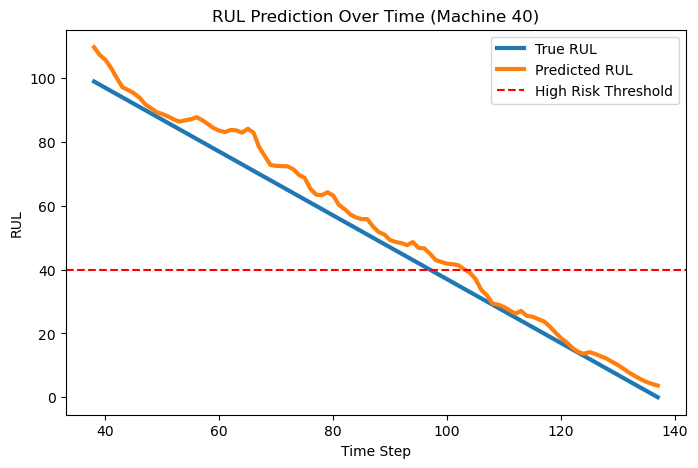

In [22]:
machine_id = val_ids[5]

machine_indices = np.where(val_machine_ids == machine_id)[0]

true_rul_machine = []
pred_rul_machine = []
cycles_machine = []

model.eval()

with torch.no_grad():
    for idx in machine_indices:
        sample_input = X_val[idx].unsqueeze(0)
        rul_pred, _ = model(sample_input)
        true_rul_machine.append(y_val_np[idx])
        pred_rul_machine.append(rul_pred.item())
        cycles_machine.append(len(cycles_machine))

true_rul_machine = np.array(true_rul_machine)
pred_rul_machine = np.array(pred_rul_machine)
cycles_machine = np.array(cycles_machine)

mask = true_rul_machine < 100

plt.figure(figsize=(8,5))
plt.plot(cycles_machine[mask], true_rul_machine[mask], label="True RUL", linewidth=3)
plt.plot(cycles_machine[mask], pred_rul_machine[mask], label="Predicted RUL", linewidth=3)
plt.axhline(y=40, linestyle="--", color="red", label="High Risk Threshold")
plt.xlabel("Time Step")
plt.ylabel("RUL")
plt.title(f"RUL Prediction Over Time (Machine {machine_id})")
plt.legend()
plt.show()

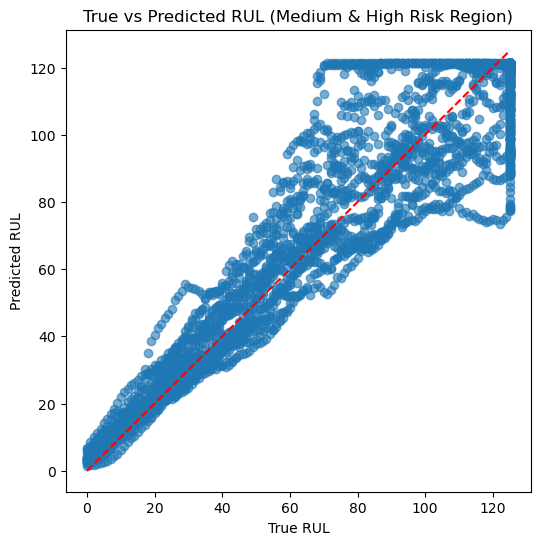

In [23]:
true_rul = np.array(y_val_np)

pred_rul = []

model.eval()

with torch.no_grad():
    for i in range(len(X_val)):
        sample_input = X_val[i].unsqueeze(0)
        rul_pred, _ = model(sample_input)
        pred_rul.append(rul_pred.item())

pred_rul = np.array(pred_rul)

mask = true_rul < 200

true_rul_filtered = true_rul[mask]
pred_rul_filtered = pred_rul[mask]

plt.figure(figsize=(6,6))
plt.scatter(true_rul_filtered, pred_rul_filtered, alpha=0.6)

max_val = max(true_rul_filtered.max(), pred_rul_filtered.max())
plt.plot([0, max_val], [0, max_val], 'r--')

plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("True vs Predicted RUL (Medium & High Risk Region)")
plt.show()

In [24]:
exp_results = []

model.eval()

for machine_id in exp_val_machines:

    machine_data = df[df["machine_id"] == machine_id].sort_values("cycle")

    first_high_cycle = None

    for i in range(WINDOW_SIZE, len(machine_data)):

        window = machine_data.iloc[i-WINDOW_SIZE:i]

        x = torch.tensor(
            window[feature_cols].values,
            dtype=torch.float32
        ).unsqueeze(0)

        with torch.no_grad():
            rul_pred, _ = model(x)

        if rul_pred.item() < 40:  # HIGH risk
            first_high_cycle = machine_data.iloc[i]["cycle"]
            break

    failure_cycle = machine_data["cycle"].max()

    if first_high_cycle is not None:
        lead_time = failure_cycle - first_high_cycle
    else:
        lead_time = None

    exp_results.append({
        "Machine_ID": machine_id,
        "Failure_Cycle": failure_cycle,
        "First_Predicted_HIGH": first_high_cycle,
        "Lead_Time": lead_time
    })

failure_detection_df = pd.DataFrame(exp_results)

failure_detection_df

,Machine_ID,Failure_Cycle,First_Predicted_HIGH,Lead_Time
0,1,192,157.0,35.0
1,5,269,216.0,53.0
2,11,240,197.0,43.0
3,13,163,131.0,32.0
4,19,158,111.0,47.0
5,23,168,130.0,38.0
6,31,234,191.0,43.0
7,32,191,159.0,32.0
8,34,195,162.0,33.0
9,40,188,155.0,33.0


In [25]:
failure_detection_df["Lead_Time"].mean()

37.7

In [26]:
from captum.attr import IntegratedGradients

def forward_rul_only(x):
    rul_pred, _ = model(x)
    return rul_pred

ig = IntegratedGradients(forward_rul_only)

In [27]:
def build_fleet_ranking(cycle_number):

    fleet_records = []
    model.eval()

    for machine_id in val_ids:

        indices = np.where(val_machine_ids == machine_id)[0]
        if len(indices) == 0:
            continue

        chosen_index = None
        chosen_cycle = None
        machine_df = df[df["machine_id"] == machine_id]

        for idx in indices:
            relative_idx = idx - indices[0]
            if relative_idx + WINDOW_SIZE >= len(machine_df):
                continue
            window_end_cycle = machine_df.iloc[WINDOW_SIZE + relative_idx]["cycle"]
            if window_end_cycle >= cycle_number:
                chosen_index = idx
                chosen_cycle = window_end_cycle
                break

        if chosen_index is None:
            continue

        sample_input = X_val[chosen_index].unsqueeze(0)

        with torch.no_grad():
            rul_preds, _ = model(sample_input)

        predicted_rul = max(0, rul_preds.item())
        risk_label = rul_to_risk(predicted_rul)

        fleet_records.append({
            "Machine_ID": machine_id,
            "Predicted_RUL": predicted_rul,
            "Risk_Label": risk_label,
            "Val_Index": chosen_index,
            "Cycle": chosen_cycle
        })

    fleet_df = pd.DataFrame(fleet_records)
    fleet_df = fleet_df.sort_values("Predicted_RUL")
    return fleet_df

In [28]:
import matplotlib.cm as cm
def plot_top10_bar_chart(fleet_df):

    top10 = fleet_df.head(10).copy()

    fleet_min = fleet_df["Predicted_RUL"].min()
    fleet_max = fleet_df["Predicted_RUL"].max()

    colors = []

    for _, row in top10.iterrows():

        if row["Risk_Label"] == "HIGH":

            norm = 1 - (row["Predicted_RUL"] - fleet_min) / (fleet_max - fleet_min + 1e-6)

            colors.append(cm.Reds(norm))

        elif row["Risk_Label"] == "MEDIUM":

            colors.append("blue")

        else:

            colors.append("gray")

    plt.figure()

    plt.bar(top10["Machine_ID"].astype(str), top10["Predicted_RUL"], color=colors)

    plt.xlabel("Machine ID")
    plt.ylabel("Predicted RUL")
    plt.title("Top 10 Machines by Maintenance Priority")

    plt.show()

In [29]:
def compute_global_explanations(fleet_df):

    global_feature_importance = np.zeros(len(feature_cols))
    cycle_importance = {}
    cycle_counts = {}
    model.eval()

    for _, row in fleet_df.iterrows():

        idx = int(row["Val_Index"])
        current_cycle = int(row["Cycle"])
        sample_input = X_val[idx].unsqueeze(0)
        baseline = torch.zeros_like(sample_input)

        attributions = ig.attribute(sample_input, baselines=baseline, n_steps=50)
        attr = attributions.squeeze().detach().numpy()

        global_feature_importance += np.mean(np.abs(attr), axis=0)
        time_importance = np.mean(np.abs(attr), axis=1)
        start_cycle = current_cycle - WINDOW_SIZE + 1

        for i, value in enumerate(time_importance):
            real_cycle = start_cycle + i
            cycle_importance[real_cycle] = cycle_importance.get(real_cycle, 0) + value
            cycle_counts[real_cycle] = cycle_counts.get(real_cycle, 0) + 1

    global_feature_importance /= len(fleet_df)
    real_cycles = sorted(cycle_importance.keys())
    global_time_importance = [cycle_importance[c] / cycle_counts[c] for c in real_cycles]

    top_indices = np.argsort(global_feature_importance)[::-1][:5]
    print("=== Top Global Contributing Sensors ===")
    for idx in top_indices:
        print(f"{feature_cols[idx]} : {global_feature_importance[idx]:.4f}")

    plt.figure()
    plt.plot(real_cycles, global_time_importance)
    plt.title("Fleet-Level Temporal Importance")
    plt.xlabel("Cycle Number")
    plt.ylabel("Average Importance")
    plt.show()

In [30]:
def explain_machine(machine_id, cycle_number, show_plot=True):

    row = fleet_df[fleet_df["Machine_ID"] == machine_id]
    if row.empty:
        print("Machine not found")
        return

    val_index = int(row.iloc[0]["Val_Index"])
    cycle_number = int(row.iloc[0]["Cycle"])
    sample_input = X_val[val_index].unsqueeze(0)

    model.eval()
    with torch.no_grad():
        rul_preds, attention_weights = model(sample_input)

    predicted_rul = max(0, rul_preds.item())
    risk_label = rul_to_risk(predicted_rul)

    print("\n=======================================")
    print("Machine ID:", machine_id)
    print("Explained at Cycle:", cycle_number)
    print("Predicted Risk:", risk_label)
    print("Predicted RUL:", round(predicted_rul, 1))
    print("=======================================\n")

    baseline = torch.zeros_like(sample_input)
    attributions = ig.attribute(sample_input, baselines=baseline, n_steps=50)
    attr = attributions.squeeze().detach().numpy()

    heatmap_data = np.abs(attr.T)   # absolute IG — positive-only, Reds colormap

    feature_importance = np.mean(np.abs(attr), axis=0)
    top_features = np.argsort(feature_importance)[::-1][:3]

    plt.figure(figsize=(14, 8))
    im = plt.imshow(heatmap_data, aspect='auto', cmap='Reds')
    plt.colorbar(im, label="|IG Attribution|")

    start_cycle = cycle_number - WINDOW_SIZE + 1
    cycle_labels = np.arange(start_cycle, cycle_number + 1)
    plt.xticks(ticks=np.arange(WINDOW_SIZE), labels=cycle_labels, rotation=90)
    plt.yticks(ticks=np.arange(len(better_feature_names)), labels=better_feature_names)

    for f in top_features:
        plt.gca().add_patch(plt.Rectangle((-0.5, f - 0.5), WINDOW_SIZE, 1,
                                           fill=False, edgecolor='blue', linewidth=2))

    ax = plt.gca()
    yticklabels = ax.get_yticklabels()
    for f in top_features:
        yticklabels[f].set_fontweight('bold')
        yticklabels[f].set_color('blue')

    plt.title(f"IG Heatmap — Machine {machine_id} at Cycle {cycle_number}")
    plt.xlabel("Cycle")
    plt.ylabel("Sensors")
    plt.tight_layout()
    if show_plot:
        plt.show()

    att = attention_weights.squeeze().detach().numpy()
    cycle_range = np.arange(start_cycle, cycle_number + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(cycle_range, att)
    plt.xlabel("Cycle"); plt.ylabel("Attention Weight")
    plt.title(f"Attention Weights Over Time — Machine {machine_id}")
    plt.grid(alpha=0.3)
    if show_plot:
        plt.show()

    scaled_window = sample_input.squeeze().detach().numpy()
    original_window = scaler.inverse_transform(scaled_window)

    feature_importance = np.mean(np.abs(attr), axis=0)
    top_features = np.argsort(feature_importance)[::-1][:3]
    total_importance = np.sum(feature_importance)

    report = f"""
    === Predictive Maintenance Report ===
    Predicted Risk Level: {risk_label}
    Predicted RUL: {predicted_rul:.1f} cycles
    Explained at Cycle: {cycle_number}

    Primary Contributing Sensors:
    """

    for f in top_features:
        sensor_name = better_feature_names[f]
        mean_value  = np.mean(original_window[:, f])
        baseline_mean = healthy_mean_raw.iloc[f]
        baseline_std  = healthy_std_raw.iloc[f]
        pct_denom = max(abs(baseline_mean), baseline_std, 1e-6)
        mean_dev  = mean_value - baseline_mean
        mean_pct  = (mean_dev / pct_denom) * 100
        dir_mean  = "above" if mean_dev > 0 else "below"
        peak_idx  = np.argmax(np.abs(attr[:, f]))
        peak_val  = original_window[peak_idx, f]
        peak_dev  = peak_val - baseline_mean
        peak_pct  = (peak_dev / pct_denom) * 100
        dir_peak  = "above" if peak_dev > 0 else "below"
        imp_pct   = (feature_importance[f] / (total_importance + 1e-8)) * 100
        report += f"""
    {sensor_name}:
      Window Mean = {mean_value:.4g}  |  Healthy Mean = {baseline_mean:.4g}
      Mean dev: {abs(mean_dev):.4g} {dir_mean} ({abs(mean_pct):.2f}%)
      Peak cycle {cycle_number - WINDOW_SIZE + 1 + peak_idx}: value={peak_val:.4g}, dev={abs(peak_dev):.4g} {dir_peak} ({abs(peak_pct):.2f}%)
      IG Contribution: {imp_pct:.2f}%
    """

    result = {
        "machine_id": machine_id, "cycle": cycle_number,
        "risk": risk_label,       "rul":   predicted_rul,
        "attention": att,         "ig":    heatmap_data,
        "cycles": cycle_range,    "feature_names": better_feature_names
    }
    return result, report

In [31]:
cycle_number = 113

In [32]:
fleet_df = build_fleet_ranking(cycle_number)

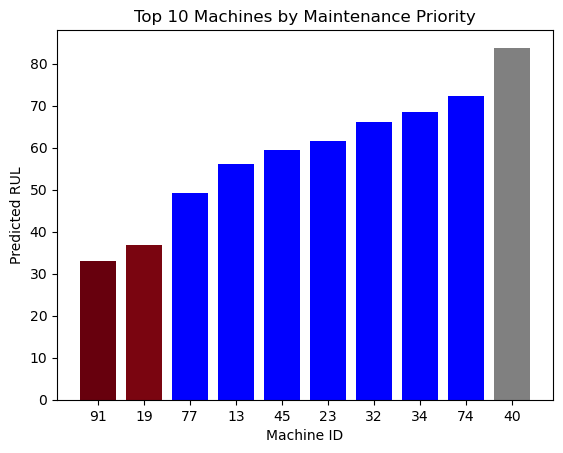

In [33]:
plot_top10_bar_chart(fleet_df)

=== Top Global Contributing Sensors ===
sensor_11 : 0.4073
sensor_14 : 0.3622
sensor_7 : 0.2992
sensor_20 : 0.2863
sensor_4 : 0.2722


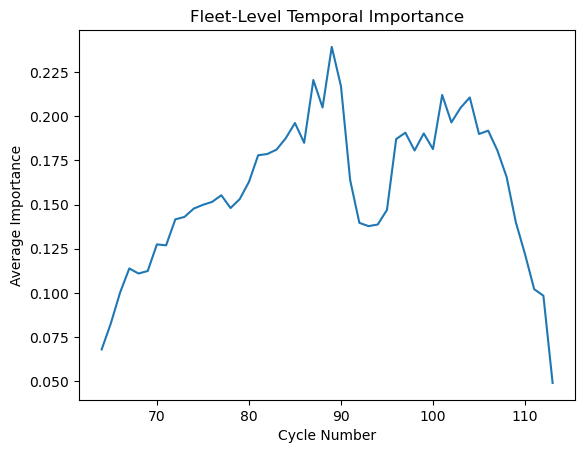

In [34]:
compute_global_explanations(fleet_df)


Machine ID: 91
Explained at Cycle: 113
Predicted Risk: HIGH
Predicted RUL: 33.1



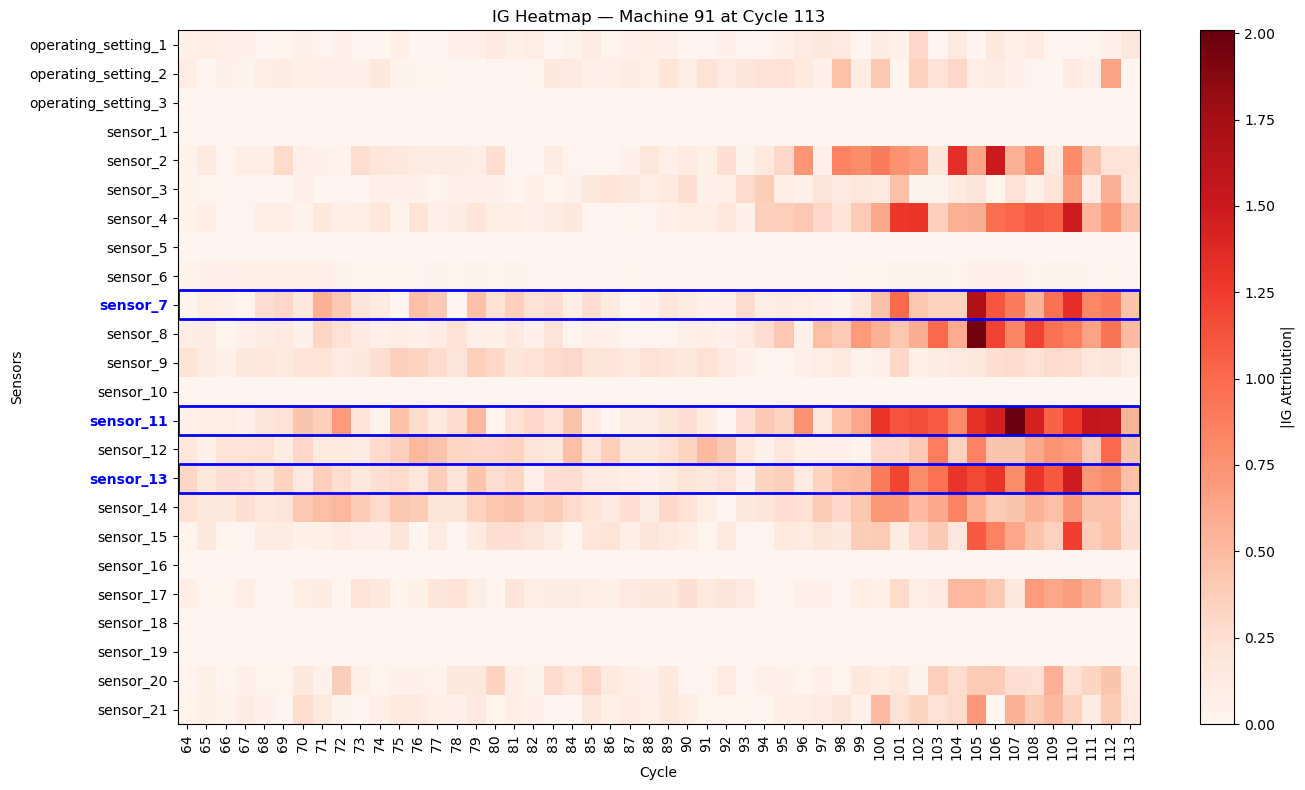

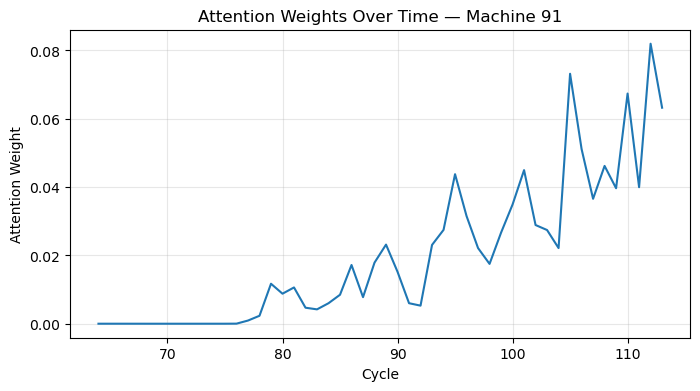


    === Predictive Maintenance Report ===
    Predicted Risk Level: HIGH
    Predicted RUL: 33.1 cycles
    Explained at Cycle: 113

    Primary Contributing Sensors:
    
    sensor_11:
      Window Mean = 47.78  |  Healthy Mean = 47.37
      Mean dev: 0.407 above (0.86%)
      Peak cycle 107: value=48.06, dev=0.6906 above (1.46%)
      IG Contribution: 12.74%
    
    sensor_13:
      Window Mean = 2388  |  Healthy Mean = 2388
      Mean dev: 0.123 above (0.01%)
      Peak cycle 110: value=2388, dev=0.1608 above (0.01%)
      IG Contribution: 10.73%
    
    sensor_7:
      Window Mean = 552.6  |  Healthy Mean = 553.9
      Mean dev: 1.329 below (0.24%)
      Peak cycle 105: value=551.8, dev=2.137 below (0.39%)
      IG Contribution: 8.37%
    


In [35]:
most_urgent_machine = fleet_df.iloc[0]["Machine_ID"]

result, report = explain_machine(most_urgent_machine, cycle_number)
print(report)


Machine ID: 91
Explained at Cycle: 113
Predicted Risk: HIGH
Predicted RUL: 33.1



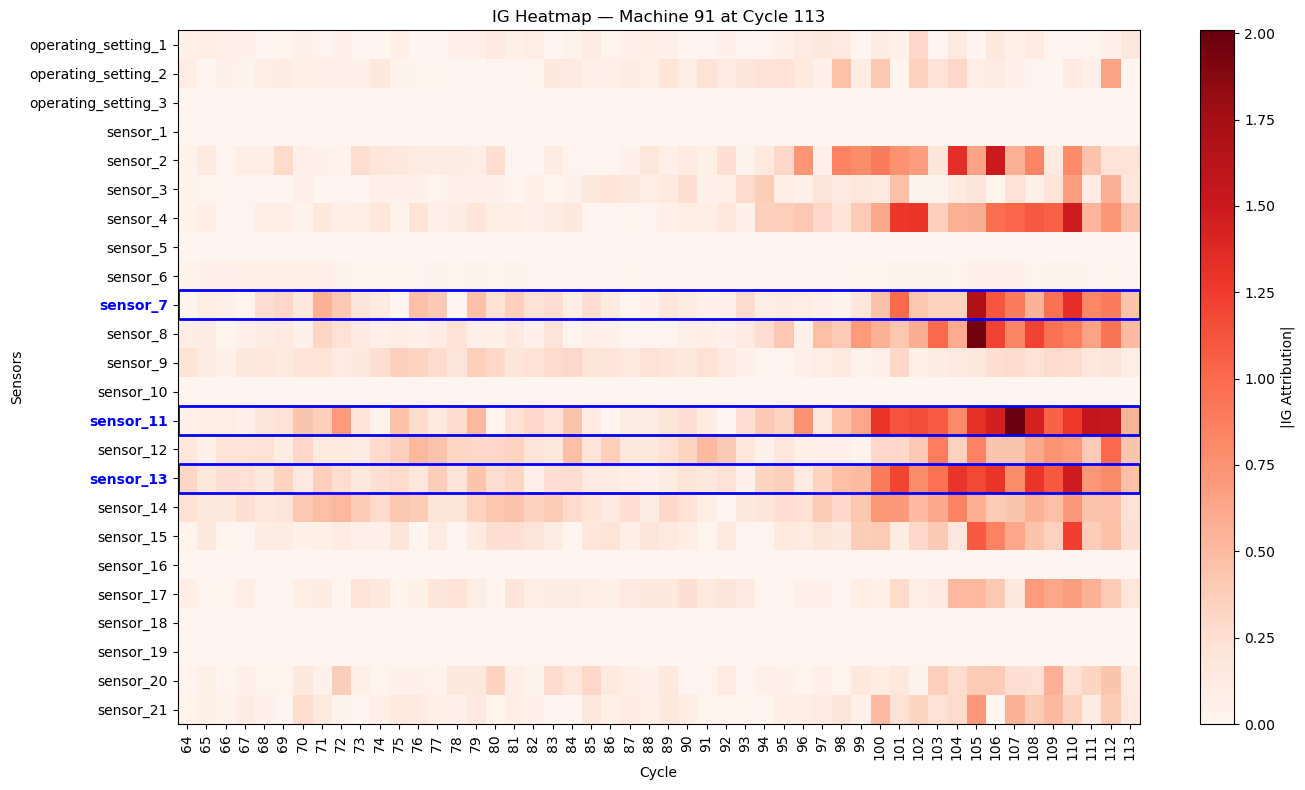

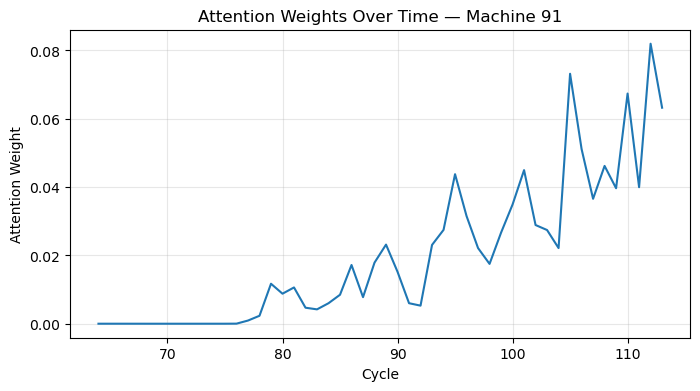


    === Predictive Maintenance Report ===
    Predicted Risk Level: HIGH
    Predicted RUL: 33.1 cycles
    Explained at Cycle: 113

    Primary Contributing Sensors:
    
    sensor_11:
      Window Mean = 47.78  |  Healthy Mean = 47.37
      Mean dev: 0.407 above (0.86%)
      Peak cycle 107: value=48.06, dev=0.6906 above (1.46%)
      IG Contribution: 12.74%
    
    sensor_13:
      Window Mean = 2388  |  Healthy Mean = 2388
      Mean dev: 0.123 above (0.01%)
      Peak cycle 110: value=2388, dev=0.1608 above (0.01%)
      IG Contribution: 10.73%
    
    sensor_7:
      Window Mean = 552.6  |  Healthy Mean = 553.9
      Mean dev: 1.329 below (0.24%)
      Peak cycle 105: value=551.8, dev=2.137 below (0.39%)
      IG Contribution: 8.37%
    


In [36]:
result, report = explain_machine(91, cycle_number)
print(report)

In [37]:
print(f" {len(fleet_df)} machines available at cycle {cycle_number}")

 20 machines available at cycle 113


In [38]:
def get_top_n_machines_table(fleet_df, n):

    n = min(n, len(fleet_df))

    top_n = fleet_df.head(n).copy()

    table = top_n[["Machine_ID", "Predicted_RUL", "Risk_Label"]]

    return table

In [39]:
num_machines = 13

In [40]:
top_machines_table = get_top_n_machines_table(fleet_df, num_machines)

display(top_machines_table)

,Machine_ID,Predicted_RUL,Risk_Label
14,91,33.093632,HIGH
10,19,36.736259,HIGH
16,77,49.270622,MEDIUM
18,13,56.061291,MEDIUM
4,45,59.519444,MEDIUM
6,23,61.638714,MEDIUM
19,32,66.059784,MEDIUM
13,34,68.581009,MEDIUM
12,74,72.401550,MEDIUM
5,40,83.815353,LOW


In [41]:
from captum.attr import Occlusion
from scipy.stats import spearmanr

def compare_ig_occlusion(machine_id, cycle_number):

    machine_df = df[df["machine_id"] == machine_id].sort_values("cycle")

    if len(machine_df) < WINDOW_SIZE:
        print("Not enough data")
        return

    machine_df = machine_df[machine_df["cycle"] <= cycle_number]

    if len(machine_df) < WINDOW_SIZE:
        print("Not enough data at this cycle")
        return

    window = machine_df.iloc[-WINDOW_SIZE:]
    window_array = window[feature_cols].values
    sample_input = torch.tensor(window_array, dtype=torch.float32).unsqueeze(0)

    model.eval()

    # IG
    baseline = torch.zeros_like(sample_input)

    attributions = ig.attribute(
        sample_input,
        baselines=baseline,
        n_steps=50
    )

    ig_attr = attributions.squeeze().detach().numpy()
    ig_importance = np.mean(np.abs(ig_attr), axis=0)

    # Occlusion (manual per-feature)
    occlusion_importance = []

    with torch.no_grad():
        original_pred, _ = model(sample_input)
    original_output = original_pred.item()

    for i in range(len(feature_cols)):
        occluded_input = sample_input.clone()
        occluded_input[:, :, i] = 0

        with torch.no_grad():
            occluded_pred, _ = model(occluded_input)
        occluded_output = occluded_pred.item()

        importance = abs(original_output - occluded_output)
        occlusion_importance.append(importance)

    occlusion_importance = np.array(occlusion_importance)

    if np.std(ig_importance) > 0 and np.std(occlusion_importance) > 0:
        corr, _ = spearmanr(ig_importance, occlusion_importance)
    else:
        corr = 0

    print(f"Agreement between IG and Occlusion (Spearman Correlation): {corr:.3f}")

    return {
        "ig": ig_importance,
        "occlusion": occlusion_importance,
        "correlation": corr,
        "features": feature_cols
    }

In [42]:
def compute_occlusion(machine_id, cycle_number):

    model.eval()

    machine_df = df[df["machine_id"] == machine_id]
    machine_df = machine_df[machine_df["cycle"] <= cycle_number]

    if len(machine_df) < WINDOW_SIZE:
        return None

    window = machine_df.iloc[-WINDOW_SIZE:]
    window_array = window.loc[:, feature_cols].values
    sample_input = torch.tensor(window_array, dtype=torch.float32).unsqueeze(0)

    with torch.no_grad():
        original_rul, _ = model(sample_input)
    original_output = original_rul.item()

    T, F = sample_input.shape[1], sample_input.shape[2]
    occl = np.zeros((T, F))

    for t in range(T):
        for f in range(F):
            occluded = sample_input.clone()
            occluded[:, t, f] = 0
            with torch.no_grad():
                new_rul, _ = model(occluded)
            occl[t, f] = abs(original_output - new_rul.item())

    occl = occl / (np.max(occl) + 1e-8)
    return occl, window["cycle"].values

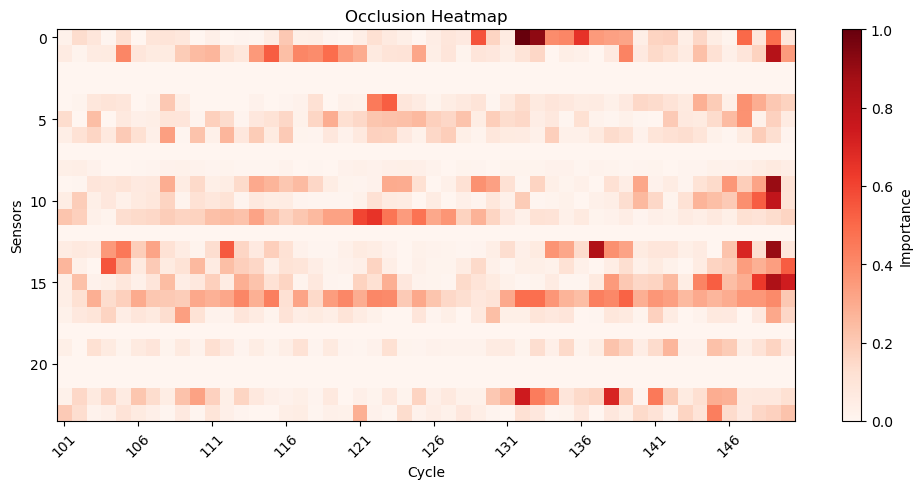

In [43]:
occl, cycles = compute_occlusion(1, 150)

plt.figure(figsize=(10,5))

plt.imshow(
    occl.T,
    aspect='auto',
    cmap='Reds',
    vmin=0,
    vmax=1
)

plt.title("Occlusion Heatmap")

step = max(1, len(cycles)//10)
plt.xticks(range(0,  len(cycles), step), cycles[::step], rotation=45)

plt.xlabel("Cycle")
plt.ylabel("Sensors")

plt.colorbar(label="Importance")

plt.tight_layout()
plt.show()

In [44]:
test_path = "../data/test_FD001.txt"

test_df = pd.read_csv(test_path, sep=" ", header=None)
test_df = test_df.dropna(axis=1)
test_df.columns = columns

In [45]:
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

In [46]:
test_sequences = []
test_machine_ids = []

for machine_id in test_df["machine_id"].unique():

    machine_data = test_df[test_df["machine_id"] == machine_id]

    if len(machine_data) >= WINDOW_SIZE:

        window = machine_data.iloc[-WINDOW_SIZE:]

    else:

        padding_needed = WINDOW_SIZE - len(machine_data)

        first_row = machine_data.iloc[0]

        padding = pd.DataFrame([first_row] * padding_needed)

        window = pd.concat([padding, machine_data], ignore_index=True)

    
    test_sequences.append(window[feature_cols].values)
    test_machine_ids.append(machine_id)

In [47]:
X_test_np = np.array(test_sequences)
X_test = torch.tensor(X_test_np, dtype=torch.float32)

In [48]:
def get_true_risk(rul):
    
    if rul < 40:
        return "HIGH"
    
    elif rul < 80:
        return "MEDIUM"
    
    else:
        return "LOW"

In [49]:
rul_file = "../data/RUL_FD001.txt"

true_rul_test = pd.read_csv(rul_file, header=None)[0]

# Cap test RUL at 125 (same protocol as training)
true_rul_test = true_rul_test.clip(upper=125)

In [50]:
true_risk = true_rul_test.apply(get_true_risk)

In [51]:
model.eval()

with torch.no_grad():
    rul_preds_test, _ = model(X_test)
    pred_rul_test = rul_preds_test.numpy().flatten()

In [52]:
predicted_classes = create_risk_labels(rul_preds_test).numpy()
true_risk = true_rul_test.apply(get_true_risk)
risk_labels = ["LOW", "MEDIUM", "HIGH"]

predicted_risk = [risk_labels[c] for c in predicted_classes]

In [53]:
comparison_df = pd.DataFrame({
    "Machine_ID": test_machine_ids,
    "True_RUL": true_rul_test,
    "True_Risk": true_risk,
    "Predicted_RUL": pred_rul_test,
    "Predicted_Risk": predicted_risk
})

comparison_df.head(50)

,Machine_ID,True_RUL,True_Risk,Predicted_RUL,Predicted_Risk
0,1,112,LOW,121.350266,LOW
1,2,98,LOW,121.301468,LOW
2,3,69,MEDIUM,56.746780,MEDIUM
3,4,82,LOW,111.477257,LOW
4,5,91,LOW,92.353546,LOW
5,6,93,LOW,121.245941,LOW
6,7,91,LOW,86.107780,LOW
7,8,95,LOW,88.202835,LOW
8,9,111,LOW,121.225304,LOW
9,10,96,LOW,63.729851,MEDIUM


In [54]:
mask = comparison_df["True_RUL"] < 100

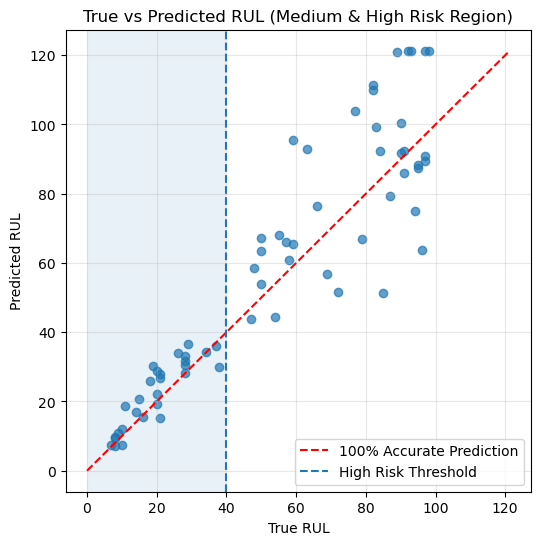

In [55]:
mask = comparison_df["True_RUL"] < 100

plt.figure(figsize=(6,6))

plt.scatter(
    comparison_df["True_RUL"][mask],
    comparison_df["Predicted_RUL"][mask],
    alpha=0.7
)

max_val = max(
    comparison_df["True_RUL"][mask].max(),
    comparison_df["Predicted_RUL"][mask].max()
)

plt.plot([0, max_val], [0, max_val], 'r--', label="100% Accurate Prediction")


plt.axvline(x=40, linestyle='--', label="High Risk Threshold")


plt.axvspan(0, 40, alpha=0.1)

plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")

plt.title("True vs Predicted RUL ")
plt.legend()

plt.grid(alpha=0.3)

plt.show()

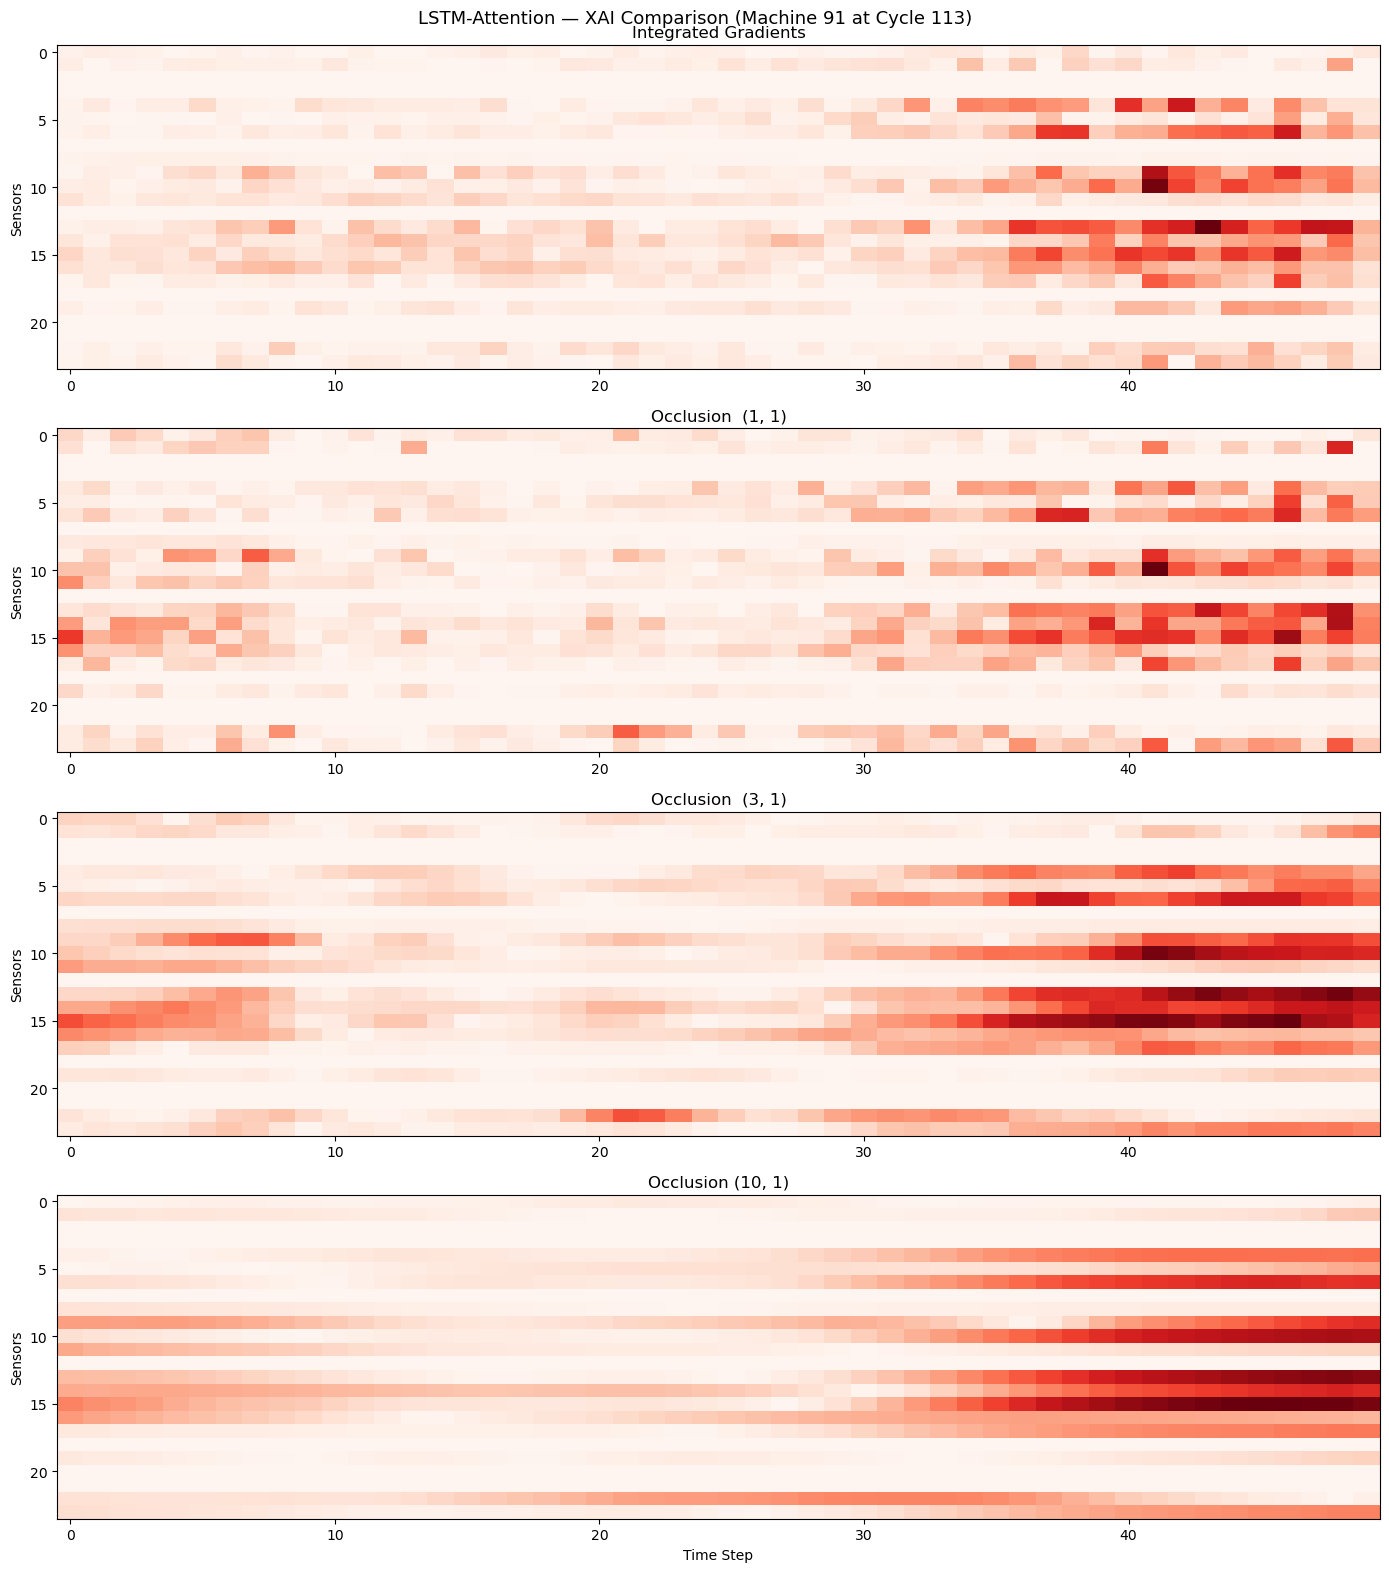

IG vs Occlusion (1,1)   Spearman r = 0.944
IG vs Occlusion (3,1)   Spearman r = 0.954
IG vs Occlusion (10,1)  Spearman r = 0.947
Larger window → smoother heatmap; agreement with IG validates both methods.


In [56]:

# Machine 91 at cycle 113
_ref_row    = fleet_df[fleet_df["Machine_ID"] == 91].iloc[0]
val_idx_occ = int(_ref_row["Val_Index"])
cnn_sample  = X_val[val_idx_occ].unsqueeze(0)
model.eval()

MACHINE_ID  = 91
CYCLE       = 113

# IG
_ig_attr = ig.attribute(cnn_sample, baselines=torch.zeros_like(cnn_sample), n_steps=50)
ig_map_ref = np.abs(_ig_attr.squeeze().detach().numpy())   # (50, 24)

# Occlusion (1, 1) — finest-grained window (single cycle, single sensor)
_occ_11 = Occlusion(forward_rul_only)
_attr_11 = _occ_11.attribute(cnn_sample, baselines=0,
                              sliding_window_shapes=(1, 1), strides=(1, 1))
occ_map_11 = np.abs(_attr_11.squeeze().detach().numpy())

# Occlusion (3, 1)
_occ_small = Occlusion(forward_rul_only)
_attr_s = _occ_small.attribute(cnn_sample, baselines=0,
                                sliding_window_shapes=(3, 1), strides=(1, 1))
occ_map_31 = np.abs(_attr_s.squeeze().detach().numpy())

# Occlusion (10, 3)
_occ_large = Occlusion(forward_rul_only)
_attr_l = _occ_large.attribute(cnn_sample, baselines=0,
                                sliding_window_shapes=(10, 1), strides=(1, 1))
occ_map_103 = np.abs(_attr_l.squeeze().detach().numpy())

# --- Plot side-by-side ---
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

axes[0].imshow(ig_map_ref.T, aspect='auto', cmap='Reds')
axes[0].set_title("Integrated Gradients")
axes[0].set_ylabel("Sensors")

axes[1].imshow(occ_map_11.T, aspect='auto', cmap='Reds')
axes[1].set_title("Occlusion  (1, 1)")
axes[1].set_ylabel("Sensors")

axes[2].imshow(occ_map_31.T, aspect='auto', cmap='Reds')
axes[2].set_title("Occlusion  (3, 1)")
axes[2].set_ylabel("Sensors")

axes[3].imshow(occ_map_103.T, aspect='auto', cmap='Reds')
axes[3].set_title("Occlusion (10, 1)")
axes[3].set_ylabel("Sensors")
axes[3].set_xlabel("Time Step")

plt.suptitle(f"LSTM-Attention — XAI Comparison (Machine {MACHINE_ID} at Cycle {CYCLE})",
             fontsize=13)
plt.tight_layout()
plt.show()

# --- Spearman agreement: IG vs each occlusion window ---
_ig_feat   = ig_map_ref.mean(axis=0)
_occ11_ft  = occ_map_11.mean(axis=0)
_occ31_ft  = occ_map_31.mean(axis=0)
_occ103_ft = occ_map_103.mean(axis=0)
corr_11,  _ = spearmanr(_ig_feat, _occ11_ft)
corr_31,  _ = spearmanr(_ig_feat, _occ31_ft)
corr_103, _ = spearmanr(_ig_feat, _occ103_ft)
print(f"IG vs Occlusion (1,1)   Spearman r = {corr_11:.3f}")
print(f"IG vs Occlusion (3,1)   Spearman r = {corr_31:.3f}")
print(f"IG vs Occlusion (10,1)  Spearman r = {corr_103:.3f}")
print("Larger window → smoother heatmap; agreement with IG validates both methods.")

In [57]:
import torch.nn as nn

class CNNModel(nn.Module):
    """
    1-D CNN for RUL regression.
    Input : (batch, seq_len=50, features=24)
    Output: (batch,)  — predicted RUL 

    Each ReLU is a separate nn.ReLU() instance — required by captum LRP,
    which cannot handle a single activation module reused across layers.
    """
    def __init__(self, input_size, seq_len=50):
        super().__init__()
        self.conv1  = nn.Conv1d(input_size, 32, kernel_size=5, padding=2)
        self.relu1  = nn.ReLU()
        self.conv2  = nn.Conv1d(32, 16, kernel_size=3, padding=1)
        self.relu2  = nn.ReLU()
        self.fc1    = nn.Linear(16 * seq_len, 64)
        self.relu3  = nn.ReLU()
        self.drop   = nn.Dropout(0.2)
        self.fc2    = nn.Linear(64, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)          # (B, F, T) for Conv1d
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = x.flatten(1)                # (B, 16*seq_len)
        x = self.relu3(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x).squeeze(-1)

print("CNNModel defined.")

CNNModel defined.


In [58]:
# CNN — Training (same loaders as LSTM)
cnn_model = CNNModel(input_size=X_train.shape[2], seq_len=WINDOW_SIZE)
cnn_optim = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

EPOCHS_CNN = 30
best_cnn_loss = float('inf')
best_cnn_state = None
patience_cnn = counter_cnn = 0

for epoch in range(EPOCHS_CNN):
    cnn_model.train()
    t_loss = 0
    for X_b, y_b in train_loader:
        cnn_optim.zero_grad()
        loss = regression_criterion(cnn_model(X_b), y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(cnn_model.parameters(), 1.0)
        cnn_optim.step()
        t_loss += loss.item()
    t_loss /= len(train_loader)

    cnn_model.eval()
    v_loss = 0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            v_loss += regression_criterion(cnn_model(X_b), y_b).item()
    v_loss /= len(val_loader)

    print(f"Epoch {epoch+1:2d} | Train: {t_loss:.2f} | Val: {v_loss:.2f}")

    if v_loss < best_cnn_loss:
        best_cnn_loss = v_loss
        best_cnn_state = cnn_model.state_dict()
        counter_cnn = 0
    else:
        counter_cnn += 1
        if counter_cnn >= patience_cnn + 5:
            print("Early stopping."); break

cnn_model.load_state_dict(best_cnn_state)
print(f"\nBest CNN Val Loss: {best_cnn_loss:.4f}")

# Save trained CNN weights so the dashboard can load them directly
import os
torch.save(best_cnn_state, os.path.join('..', 'data', 'cnn_model.pth'))
print("CNN model saved to data/cnn_model.pth")


Epoch  1 | Train: 1725.27 | Val: 554.25
Epoch  2 | Train: 545.00 | Val: 266.37
Epoch  3 | Train: 273.90 | Val: 210.89
Epoch  4 | Train: 231.92 | Val: 207.09
Epoch  5 | Train: 214.66 | Val: 209.78
Epoch  6 | Train: 199.24 | Val: 188.96
Epoch  7 | Train: 186.97 | Val: 209.33
Epoch  8 | Train: 182.63 | Val: 210.28
Epoch  9 | Train: 172.04 | Val: 221.95
Epoch 10 | Train: 176.50 | Val: 206.00
Epoch 11 | Train: 167.19 | Val: 216.82
Early stopping.

Best CNN Val Loss: 188.9591
CNN model saved to data/cnn_model.pth


In [59]:
# Save CNN model weights for the dashboard
save_path = "../data/cnn_model.pth"
torch.save(cnn_model.state_dict(), save_path)
print(f"CNN model saved to {os.path.abspath(save_path)}")


CNN model saved to /Users/mostafa/xai_predictive_maintenance/data/cnn_model.pth


In [60]:
# CNN — Evaluation on validation and test sets


cnn_model.eval()

# Validation
cnn_val_preds, cnn_val_true = [], []
with torch.no_grad():
    for X_b, y_b in val_loader:
        cnn_val_preds.extend(cnn_model(X_b).numpy())
        cnn_val_true.extend(y_b.numpy())

cnn_val_preds = np.array(cnn_val_preds)
cnn_val_true  = np.array(cnn_val_true)

cnn_risk_p = create_risk_labels(torch.tensor(cnn_val_preds)).numpy()
cnn_risk_t = create_risk_labels(torch.tensor(cnn_val_true)).numpy()

mask_high = cnn_risk_t == 2

cnn_rmse_all  = np.sqrt(np.mean((cnn_val_preds - cnn_val_true)**2))
cnn_mae_all   = np.mean(np.abs(cnn_val_preds - cnn_val_true))
cnn_rmse_high = np.sqrt(np.mean((cnn_val_preds[mask_high] - cnn_val_true[mask_high])**2))
cnn_mae_high  = np.mean(np.abs(cnn_val_preds[mask_high] - cnn_val_true[mask_high]))

print("=== CNN Regression Performance (Validation) ===")
print(f"RMSE (all):       {cnn_rmse_all:.4f}")
print(f"MAE  (all):       {cnn_mae_all:.4f}")
print(f"RMSE (high only): {cnn_rmse_high:.4f}")
print(f"MAE  (high only): {cnn_mae_high:.4f}")

print("\n=== CNN Classification Performance ===")
print(classification_report(cnn_risk_t, cnn_risk_p, target_names=["Low","Medium","High"]))

=== CNN Regression Performance (Validation) ===
RMSE (all):       14.7292
MAE  (all):       11.4566
RMSE (high only): 6.6358
MAE  (high only): 5.2830

=== CNN Classification Performance ===
              precision    recall  f1-score   support

         Low       0.89      0.88      0.89      1470
      Medium       0.72      0.66      0.69       800
        High       0.87      0.97      0.91       800

    accuracy                           0.84      3070
   macro avg       0.83      0.83      0.83      3070
weighted avg       0.84      0.84      0.84      3070



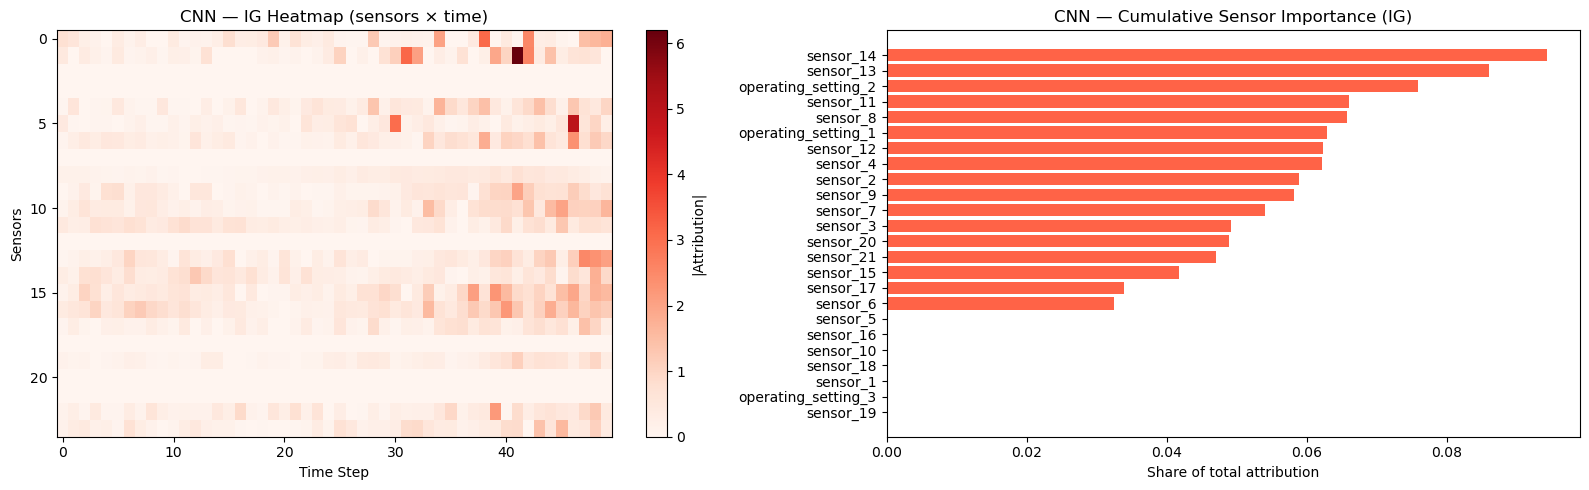

In [61]:
# CNN — Integrated Gradients
from captum.attr import IntegratedGradients as IG_captum

cnn_model.eval()

def forward_cnn(x):
    return cnn_model(x)

ig_cnn     = IG_captum(forward_cnn)
_baseline  = torch.zeros_like(cnn_sample)
cnn_ig_attr = ig_cnn.attribute(cnn_sample, baselines=_baseline, n_steps=50)
cnn_ig_map  = np.abs(cnn_ig_attr.squeeze().detach().numpy())   # (50, 24)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(cnn_ig_map.T, aspect='auto', cmap='Reds')
axes[0].set_title("CNN — IG Heatmap (sensors × time)")
axes[0].set_ylabel("Sensors"); axes[0].set_xlabel("Time Step")
plt.colorbar(im, ax=axes[0], label="|Attribution|")

_cnn_sens_imp = cnn_ig_map.mean(axis=0)
_cnn_sens_imp = _cnn_sens_imp / (_cnn_sens_imp.sum() + 1e-8)
_si = np.argsort(_cnn_sens_imp)
axes[1].barh([feature_names[i] for i in _si], _cnn_sens_imp[_si], color='tomato')
axes[1].set_title("CNN — Cumulative Sensor Importance (IG)")
axes[1].set_xlabel("Share of total attribution")

plt.tight_layout(); plt.show()

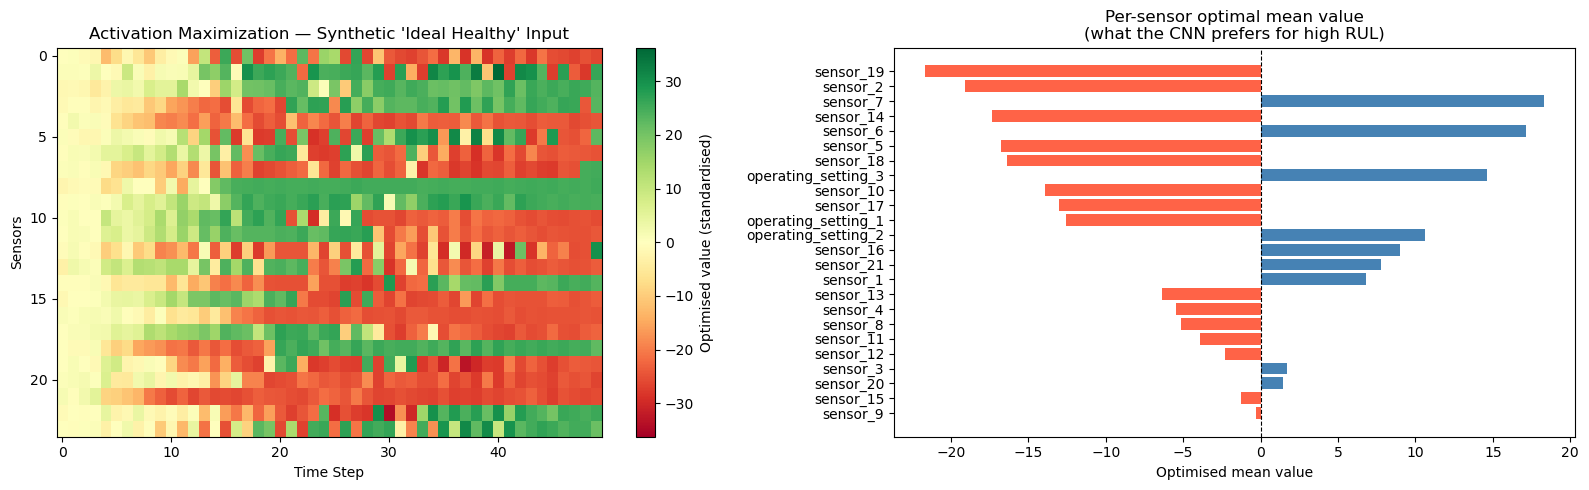

===================bars = CNN prefers HIGH values of this sensor for healthy prediction
Red  bars = CNN prefers LOW  values of this sensor for healthy prediction


In [62]:
# CNN — Activation Maximization
# Finds the synthetic input that maximises the CNN's predicted RUL
# reveals what "ideal healthy sensor readings" look like to the model

cnn_model.eval()

synthetic = torch.zeros(1, WINDOW_SIZE, X_train.shape[2], requires_grad=True)
am_optim  = torch.optim.Adam([synthetic], lr=0.05)

for _step in range(500):
    am_optim.zero_grad()
    loss = -cnn_model(synthetic)   # maximise predicted RUL
    loss.backward()
    am_optim.step()

synth_np = synthetic.detach().numpy().squeeze()   # (50, 24)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

_abs_max = np.abs(synth_np).max()
im = axes[0].imshow(synth_np.T, aspect='auto', cmap='RdYlGn',
                     vmin=-_abs_max, vmax=_abs_max)
axes[0].set_title("Activation Maximization — Synthetic 'Ideal Healthy' Input")
axes[0].set_ylabel("Sensors"); axes[0].set_xlabel("Time Step")
plt.colorbar(im, ax=axes[0], label="Optimised value (standardised)")

_sensor_means = synth_np.mean(axis=0)
_si_am = np.argsort(np.abs(_sensor_means))
_colors_am = ['tomato' if v < 0 else 'steelblue' for v in _sensor_means[_si_am]]
axes[1].barh([feature_names[i] for i in _si_am], _sensor_means[_si_am], color=_colors_am)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title("Per-sensor optimal mean value\n(what the CNN prefers for high RUL)")
axes[1].set_xlabel("Optimised mean value")

plt.tight_layout(); plt.show()

print("===================bars = CNN prefers HIGH values of this sensor for healthy prediction")
print("Red  bars = CNN prefers LOW  values of this sensor for healthy prediction")

/Users/mostafa/anaconda3/lib/python3.10/site-packages/captum/attr/_core/lrp.py:207: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(input_tuple)


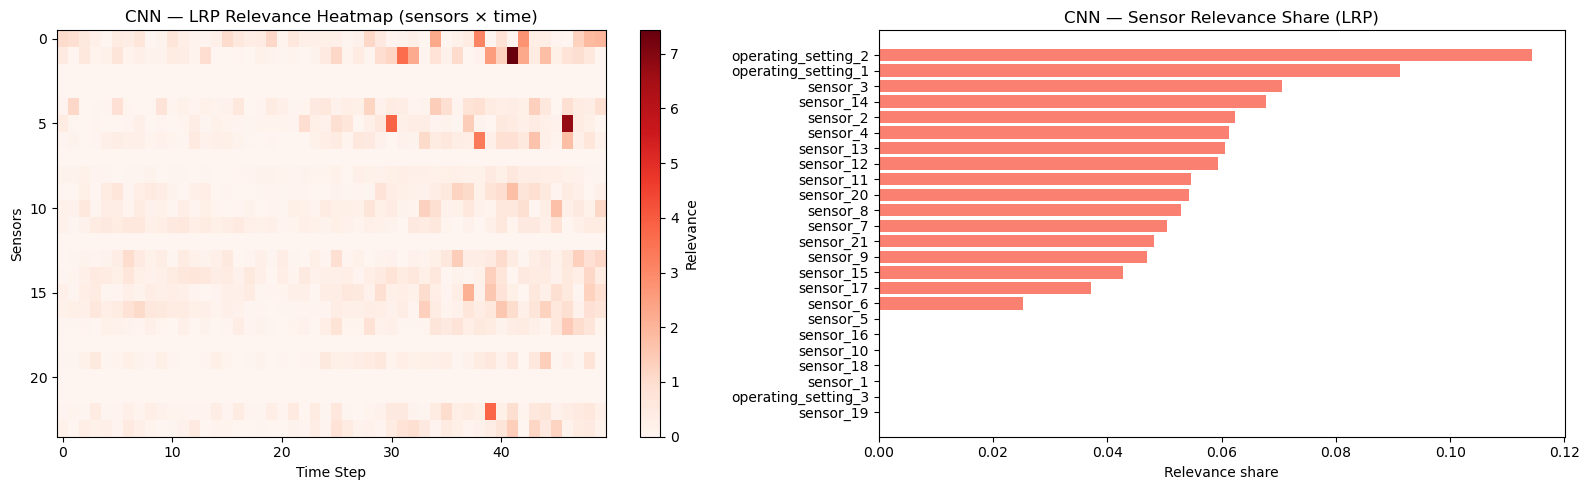

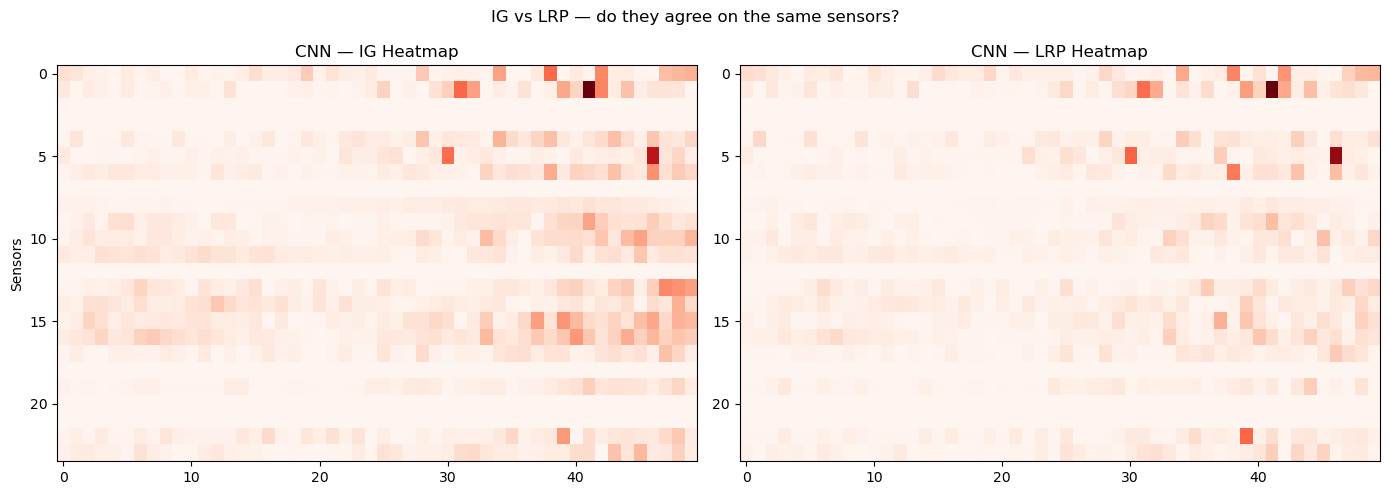

In [63]:
# CNN — LRP (Layer-wise Relevance Propagation)
from captum.attr import LRP
from captum.attr._utils.lrp_rules import EpsilonRule

cnn_model.eval()

# Set EpsilonRule on every layer that captum's LRP needs to propagate through
for module in cnn_model.modules():
    if isinstance(module, (nn.Conv1d, nn.Linear, nn.ReLU, nn.Dropout)):
        module.rule = EpsilonRule()

lrp = LRP(cnn_model)
lrp_attr    = lrp.attribute(cnn_sample)
cnn_lrp_map = np.abs(lrp_attr.squeeze().detach().numpy())   # (50, 24)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(cnn_lrp_map.T, aspect="auto", cmap="Reds")
axes[0].set_title("CNN — LRP Relevance Heatmap (sensors × time)")
axes[0].set_ylabel("Sensors"); axes[0].set_xlabel("Time Step")
plt.colorbar(im, ax=axes[0], label="Relevance")

_lrp_sensor = cnn_lrp_map.mean(axis=0)
_lrp_sensor = _lrp_sensor / (_lrp_sensor.sum() + 1e-8)
_si = np.argsort(_lrp_sensor)
axes[1].barh([feature_names[i] for i in _si], _lrp_sensor[_si], color="salmon")
axes[1].set_title("CNN — Sensor Relevance Share (LRP)")
axes[1].set_xlabel("Relevance share")

plt.tight_layout(); plt.show()

# IG vs LRP side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cnn_ig_map.T, aspect="auto", cmap="Reds")
axes[0].set_title("CNN — IG Heatmap"); axes[0].set_ylabel("Sensors")
axes[1].imshow(cnn_lrp_map.T, aspect="auto", cmap="Reds")
axes[1].set_title("CNN — LRP Heatmap")
plt.suptitle("IG vs LRP — do they agree on the same sensors?")
plt.tight_layout(); plt.show()

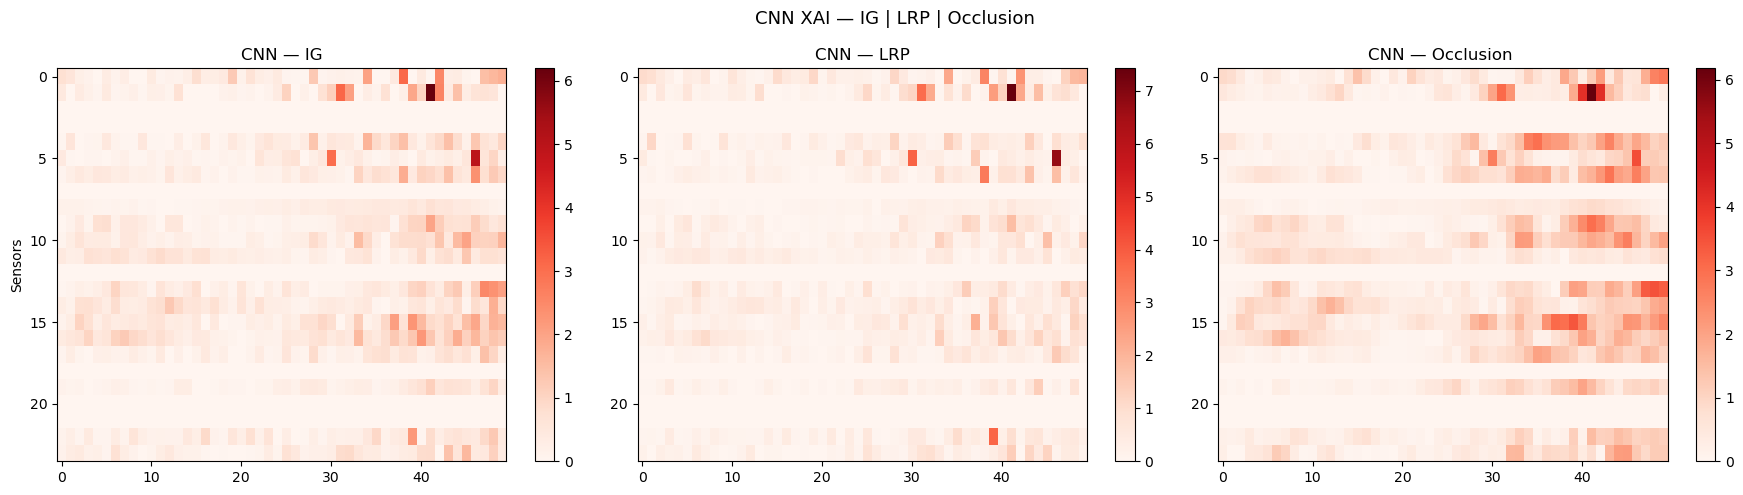

Spearman  IG  vs LRP:      0.893
Spearman  IG  vs Occlusion: 0.900
Spearman LRP  vs Occlusion: 0.810


In [64]:
# CNN — Occlusion  + Cross-method comparison: IG | LRP | Occlusion
from captum.attr import Occlusion as CaptumOcclusion

cnn_model.eval()

_forward_cnn = lambda x: cnn_model(x)
_occ_cnn = CaptumOcclusion(_forward_cnn)

cnn_occ_attr = _occ_cnn.attribute(
    cnn_sample, baselines=0,
    sliding_window_shapes=(2, 1), strides=(1, 1)
)
cnn_occ_map = np.abs(cnn_occ_attr.squeeze().detach().numpy())   # (50, 24)

# --- 3-way comparison ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(cnn_ig_map.T,  aspect='auto', cmap='Reds')
axes[0].set_title("CNN — IG"); axes[0].set_ylabel("Sensors"); plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(cnn_lrp_map.T, aspect='auto', cmap='Reds')
axes[1].set_title("CNN — LRP"); plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(cnn_occ_map.T, aspect='auto', cmap='Reds')
axes[2].set_title("CNN — Occlusion "); plt.colorbar(im2, ax=axes[2])

plt.suptitle("CNN XAI — IG | LRP | Occlusion", fontsize=13)
plt.tight_layout()
plt.show()

# --- Cross-method agreement ---
_ig_f   = cnn_ig_map.mean(axis=0)
_lrp_f  = cnn_lrp_map.mean(axis=0)
_occ_f  = cnn_occ_map.mean(axis=0)

r_ig_lrp,  _ = spearmanr(_ig_f, _lrp_f)
r_ig_occ,  _ = spearmanr(_ig_f, _occ_f)
r_lrp_occ, _ = spearmanr(_lrp_f, _occ_f)

print(f"Spearman  IG  vs LRP:      {r_ig_lrp:.3f}")
print(f"Spearman  IG  vs Occlusion: {r_ig_occ:.3f}")
print(f"Spearman LRP  vs Occlusion: {r_lrp_occ:.3f}")

In [65]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

class HybridCNNLSTMBiLSTM(nn.Module):
    """
    Hybrid architecture following Kara et al. (2020):
      3 x Conv1D (32 → 64 → 128)  →  3-layer LSTM (hidden=96)
      →  2-layer BiLSTM (hidden=64)  →  FC regression head
    """
    def __init__(self, input_size=24, seq_len=50,
                 cnn_channels=None,
                 lstm_hidden=96, lstm_layers=3,
                 bilstm_hidden=64, bilstm_layers=2,
                 dropout=0.2):
        super().__init__()
        if cnn_channels is None:
            cnn_channels = [32, 64, 128]

        # 3 x Conv1D feature extraction
        self.cnn = nn.Sequential(
            nn.Conv1d(input_size,       cnn_channels[0], kernel_size=3, padding=1),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(cnn_channels[0], cnn_channels[1], kernel_size=3, padding=1),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(cnn_channels[1], cnn_channels[2], kernel_size=3, padding=1),
            nn.ReLU(), nn.Dropout(dropout),
        )

        #  3-layer unidirectional LSTM
        self.lstm = nn.LSTM(
            cnn_channels[-1], lstm_hidden,
            num_layers=lstm_layers, batch_first=True, dropout=dropout
        )

        #  2-layer Bidirectional LSTM
        self.bilstm = nn.LSTM(
            lstm_hidden, bilstm_hidden,
            num_layers=bilstm_layers, batch_first=True,
            bidirectional=True, dropout=dropout
        )

        #  Regression head 
        self.regressor = nn.Sequential(
            nn.Linear(bilstm_hidden * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        x = x.transpose(1, 2)          # → (batch, input_size, seq_len)  for Conv1d
        x = self.cnn(x)                # → (batch, 128, seq_len)
        x = x.transpose(1, 2)          # → (batch, seq_len, 128)
        x, _ = self.lstm(x)            # → (batch, seq_len, 96)
        x, _ = self.bilstm(x)          # → (batch, seq_len, 128)  [64*2]
        x = x[:, -1, :]               # take last time step
        return self.regressor(x).squeeze(-1)   # scalar RUL

print("HybridCNNLSTMBiLSTM defined.")


Using device: cpu
HybridCNNLSTMBiLSTM defined.


In [66]:
hybrid_model     = HybridCNNLSTMBiLSTM(input_size=X_train.shape[2]).to(device)
hybrid_optim     = torch.optim.Adam(hybrid_model.parameters(), lr=1e-3)
hybrid_criterion = nn.MSELoss()

EPOCHS    = 50
best_loss  = float('inf')
best_state = None
counter    = 0
patience   = 7

for epoch in range(EPOCHS):
    hybrid_model.train()
    train_loss = 0.0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        hybrid_optim.zero_grad()
        preds = hybrid_model(X_b)
        loss  = hybrid_criterion(preds, y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(hybrid_model.parameters(), 1.0)
        hybrid_optim.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    hybrid_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            preds = hybrid_model(X_b)
            val_loss += hybrid_criterion(preds, y_b).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1:2d} | Train MSE: {train_loss:.2f} | Val MSE: {val_loss:.2f}")

    if val_loss < best_loss:
        best_loss  = val_loss
        best_state = {k: v.clone() for k, v in hybrid_model.state_dict().items()}
        counter    = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

hybrid_model.load_state_dict(best_state)
print(f"Best Hybrid Val MSE: {best_loss:.4f}  (RMSE ≈ {best_loss**0.5:.2f})")

# Save weights for the dashboard
torch.save(hybrid_model.state_dict(), os.path.join('..', 'data', 'hybrid_model.pth'))
print("Hybrid model saved to data/hybrid_model.pth")


Epoch  1 | Train MSE: 3290.08 | Val MSE: 1703.45
Epoch  2 | Train MSE: 1754.54 | Val MSE: 1705.15
Epoch  3 | Train MSE: 1760.12 | Val MSE: 1716.83
Epoch  4 | Train MSE: 1759.01 | Val MSE: 1701.07
Epoch  5 | Train MSE: 1767.17 | Val MSE: 1701.07
Epoch  6 | Train MSE: 1743.45 | Val MSE: 1701.46
Epoch  7 | Train MSE: 1680.54 | Val MSE: 687.55
Epoch  8 | Train MSE: 522.37 | Val MSE: 214.06
Epoch  9 | Train MSE: 314.89 | Val MSE: 206.39
Epoch 10 | Train MSE: 258.65 | Val MSE: 162.08
Epoch 11 | Train MSE: 228.62 | Val MSE: 159.59
Epoch 12 | Train MSE: 205.48 | Val MSE: 194.81
Epoch 13 | Train MSE: 186.00 | Val MSE: 189.42
Epoch 14 | Train MSE: 174.36 | Val MSE: 166.89
Epoch 15 | Train MSE: 152.97 | Val MSE: 281.51
Epoch 16 | Train MSE: 143.63 | Val MSE: 183.21
Epoch 17 | Train MSE: 140.23 | Val MSE: 223.89
Epoch 18 | Train MSE: 132.99 | Val MSE: 233.99
Early stopping triggered.
Best Hybrid Val MSE: 159.5867  (RMSE ≈ 12.63)
Hybrid model saved to data/hybrid_model.pth


In [67]:
# Validation-set inference
hybrid_model.eval()

all_risk_preds = []
all_risk_true  = []
all_rul_preds  = []
all_rul_true   = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        rul_preds = hybrid_model(X_batch)

        risk_true = create_risk_labels(y_batch)
        risk_pred = create_risk_labels(rul_preds)

        all_risk_preds.extend(risk_pred.cpu().numpy())
        all_risk_true.extend(risk_true.cpu().numpy())
        all_rul_preds.extend(rul_preds.cpu().numpy())
        all_rul_true.extend(y_batch.cpu().numpy())

all_risk_preds = np.array(all_risk_preds)
all_risk_true  = np.array(all_risk_true)
all_rul_preds  = np.array(all_rul_preds)
all_rul_true   = np.array(all_rul_true)


In [68]:
# Regression metrics (stratified)
mask_high   = all_risk_true == 2

rmse_all    = np.sqrt(np.mean((all_rul_preds - all_rul_true) ** 2))
mae_all     = np.mean(np.abs(all_rul_preds - all_rul_true))
rmse_high   = np.sqrt(np.mean((all_rul_preds[mask_high]   - all_rul_true[mask_high])   ** 2))
mae_high    = np.mean(np.abs(all_rul_preds[mask_high]   - all_rul_true[mask_high]))


print("\n=== Regression Performance — Hybrid CNN+LSTM+BiLSTM (val) ===")
print(f"RMSE (all):     {rmse_all:.4f}")
print(f"MAE  (all):     {mae_all:.4f}")
print(f"RMSE (high):    {rmse_high:.4f}")
print(f"MAE  (high):    {mae_high:.4f}")




=== Regression Performance — Hybrid CNN+LSTM+BiLSTM (val) ===
RMSE (all):     12.6362
MAE  (all):     9.5890
RMSE (high):    7.2820
MAE  (high):    5.8554


In [69]:
# Classification metrics
accuracy = accuracy_score(all_risk_true, all_risk_preds)

print("\n=== Classification Performance — Hybrid CNN+LSTM+BiLSTM ===")
print(f"Accuracy: {round(accuracy, 4)}")

print("\nConfusion Matrix:")
print(confusion_matrix(all_risk_true, all_risk_preds))

print("\nClassification Report:")
print(classification_report(
    all_risk_true, all_risk_preds,
    target_names=["Low", "Medium", "High"]
))



=== Classification Performance — Hybrid CNN+LSTM+BiLSTM ===
Accuracy: 0.8645

Confusion Matrix:
[[1337  133    0]
 [ 129  540  131]
 [   0   23  777]]

Classification Report:
              precision    recall  f1-score   support

         Low       0.91      0.91      0.91      1470
      Medium       0.78      0.68      0.72       800
        High       0.86      0.97      0.91       800

    accuracy                           0.86      3070
   macro avg       0.85      0.85      0.85      3070
weighted avg       0.86      0.86      0.86      3070



In [70]:
# Test-set evaluation
hybrid_model.eval()

with torch.no_grad():
    hybrid_test_preds = []
    for i in range(0, len(X_test), 64):
        batch = X_test[i:i+64].to(device)
        preds = hybrid_model(batch)
        vals  = preds.squeeze().cpu().numpy()
        hybrid_test_preds.extend(vals.tolist() if vals.ndim > 0 else [float(vals)])

hybrid_test_preds = np.array(hybrid_test_preds)
true_rul = true_rul_test.values

rmse_test = np.sqrt(np.mean((hybrid_test_preds - true_rul) ** 2))
mae_test  = np.mean(np.abs(hybrid_test_preds - true_rul))

print("=== TEST PERFORMANCE — Hybrid CNN+LSTM+BiLSTM ===")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAE:  {mae_test:.4f}")


=== TEST PERFORMANCE — Hybrid CNN+LSTM+BiLSTM ===
RMSE: 15.7764
MAE:  11.2866


In [71]:
import torch.nn.functional as F

class Transformer_KAN_BiLSTM(nn.Module):
    """
    Transformer encoder → BiLSTM → MLP head.
    Note: The 'KAN-like' head is a deep MLP with ReLU — it approximates
    Kolmogorov-Arnold Networks via basis expansion but uses standard layers
    for compatibility with captum XAI tools.
    """
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2, lstm_hidden=96):
        super().__init__()

        # ===== Embedding =====
        self.embed = nn.Linear(input_size, d_model)

        # ===== Transformer =====
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=256,   # wider FFN for better capacity
            dropout=0.1,           # lighter dropout on small dataset
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        #BiLSTM 
        self.bilstm = nn.LSTM(
            input_size=d_model,
            hidden_size=lstm_hidden,
            num_layers=2,
            batch_first=True,
            dropout=0.1,
            bidirectional=True
        )

        #  Attention pooling over BiLSTM output 
        self.pool_attn = nn.Linear(2 * lstm_hidden, 1)

        #  KAN-like MLP head
        self.kan_head = nn.Sequential(
            nn.Linear(2 * lstm_hidden, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: (B, T, F)
        x = self.embed(x)                       # (B, T, d_model)
        x = self.transformer(x)                 # (B, T, d_model)
        lstm_out, _ = self.bilstm(x)            # (B, T, 2H)

        # Attention pooling — weight all timesteps, not just last
        attn_w = torch.softmax(self.pool_attn(lstm_out), dim=1)  # (B, T, 1)
        context = (attn_w * lstm_out).sum(dim=1)                  # (B, 2H)

        return self.kan_head(context).squeeze(-1)

print("Transformer_KAN_BiLSTM defined.")

Transformer_KAN_BiLSTM defined.


In [72]:
# Using a separate variable avoids overwriting the original LSTM "model"
transformer_model = Transformer_KAN_BiLSTM(input_size=X_train.shape[2])
transformer_optim = torch.optim.Adam(transformer_model.parameters(), lr=0.0005,
                                     weight_decay=1e-4)
transformer_criterion = nn.MSELoss()   # local — does NOT overwrite regression_criterion
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    transformer_optim, mode="min", factor=0.5, patience=3
)  # verbose removed — PyTorch >=2.2 dropped that argument

EPOCHS     = 60
best_loss  = float("inf")
best_state = None
counter    = 0
patience   = 10   # more patience: Transformers on small data need more epochs

for epoch in range(EPOCHS):
    transformer_model.train()
    train_loss = 0

    for X_b, y_b in train_loader:
        transformer_optim.zero_grad()
        preds = transformer_model(X_b)
        loss  = transformer_criterion(preds, y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(transformer_model.parameters(), 1.0)
        transformer_optim.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    transformer_model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            preds = transformer_model(X_b)
            val_loss += transformer_criterion(preds, y_b).item()
    val_loss /= len(val_loader)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1:2d} | Train MSE: {train_loss:.2f} | Val MSE: {val_loss:.2f}")

    if val_loss < best_loss:
        best_loss  = val_loss
        best_state = transformer_model.state_dict()
        counter    = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping.")
            break

transformer_model.load_state_dict(best_state)
print(f"Best Transformer Val MSE: {best_loss:.4f}  (RMSE approx {best_loss**0.5:.2f})")


Epoch  1 | Train MSE: 2760.70 | Val MSE: 383.24
Epoch  2 | Train MSE: 232.13 | Val MSE: 136.07
Epoch  3 | Train MSE: 116.58 | Val MSE: 161.15
Epoch  4 | Train MSE: 85.36 | Val MSE: 156.77
Epoch  5 | Train MSE: 63.46 | Val MSE: 161.08
Epoch  6 | Train MSE: 44.28 | Val MSE: 159.13
Epoch  7 | Train MSE: 26.99 | Val MSE: 160.64
Epoch  8 | Train MSE: 21.12 | Val MSE: 185.38
Epoch  9 | Train MSE: 18.32 | Val MSE: 165.42
Epoch 10 | Train MSE: 15.86 | Val MSE: 171.82
Epoch 11 | Train MSE: 11.12 | Val MSE: 188.54
Epoch 12 | Train MSE: 10.44 | Val MSE: 176.34
Early stopping.
Best Transformer Val MSE: 136.0668  (RMSE approx 11.66)


In [73]:
transformer_model.eval()

all_risk_preds = []
all_risk_true  = []
all_rul_preds  = []
all_rul_true   = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        rul_preds = transformer_model(X_batch)

        risk_batch       = create_risk_labels(y_batch)
        predicted_classes = create_risk_labels(rul_preds)

        all_risk_preds.extend(predicted_classes.cpu().numpy())
        all_risk_true.extend(risk_batch.cpu().numpy())
        all_rul_preds.extend(rul_preds.cpu().numpy())
        all_rul_true.extend(y_batch.cpu().numpy())

all_risk_preds = np.array(all_risk_preds)
all_risk_true  = np.array(all_risk_true)
all_rul_preds  = np.array(all_rul_preds)
all_rul_true   = np.array(all_rul_true)

In [74]:
mask_high = all_risk_true == 2

rmse_all  = np.sqrt(np.mean((all_rul_preds - all_rul_true) ** 2))
mae_all   = np.mean(np.abs(all_rul_preds - all_rul_true))
rmse_high = np.sqrt(np.mean((all_rul_preds[mask_high] - all_rul_true[mask_high]) ** 2))
mae_high  = np.mean(np.abs(all_rul_preds[mask_high] - all_rul_true[mask_high]))

print("\n=== Transformer + KAN + BiLSTM ===")
print(f"RMSE (all):       {round(rmse_all,  4)}")
print(f"MAE  (all):       {round(mae_all,   4)}")
print(f"RMSE (high only): {round(rmse_high, 4)}")
print(f"MAE  (high only): {round(mae_high,  4)}")


=== Transformer + KAN + BiLSTM ===
RMSE (all):       13.281700134277344
MAE  (all):       9.084699630737305
RMSE (high only): 5.73199987411499
MAE  (high only): 4.167099952697754


In [75]:
accuracy = accuracy_score(all_risk_true, all_risk_preds)

print("\n=== Classification Performance ===")
print("Accuracy:", round(accuracy, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(all_risk_true, all_risk_preds))

print("\nClassification Report:")
print(classification_report(
    all_risk_true,
    all_risk_preds,
    target_names=["Low", "Medium", "High"]
))


=== Classification Performance ===
Accuracy: 0.8687

Confusion Matrix:
[[1403   67    0]
 [ 213  521   66]
 [   0   57  743]]

Classification Report:
              precision    recall  f1-score   support

         Low       0.87      0.95      0.91      1470
      Medium       0.81      0.65      0.72       800
        High       0.92      0.93      0.92       800

    accuracy                           0.87      3070
   macro avg       0.86      0.84      0.85      3070
weighted avg       0.87      0.87      0.86      3070



In [76]:
transformer_model.eval()

with torch.no_grad():
    test_preds = transformer_model(X_test).cpu().numpy().flatten()

true_rul = true_rul_test.values

rmse_test = np.sqrt(np.mean((test_preds - true_rul) ** 2))
mae_test  = np.mean(np.abs(test_preds - true_rul))

print("=== TEST PERFORMANCE (Transformer + KAN + BiLSTM) ===")
print("RMSE:", round(rmse_test, 4))
print("MAE:",  round(mae_test,  4))

=== TEST PERFORMANCE (Transformer + KAN + BiLSTM) ===
RMSE: 17.5841
MAE: 12.7561


# Multi-Dataset Evaluation: FD001 – FD004
Train and evaluate all three models (LSTM, CNN, Hybrid) on each CMAPSS subset.
Results include train/val loss curves, true-vs-predicted scatter plots, and a metrics summary table.

In [77]:
# ─────────────────────────────────────────────────────────────────────────
# SHARED UTILITIES  (FD001 – FD004)
# ─────────────────────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


def load_cmapss_dataset(fd_name):
    """Load, preprocess, and 80/20 split any CMAPSS subset."""
    cols = (['machine_id', 'cycle'] +
            [f'operating_setting_{i}' for i in range(1, 4)] +
            [f'sensor_{i}'           for i in range(1, 22)])

    # ── training split ──────────────────────────────────────────────────
    df_fd = pd.read_csv(f'../data/train_{fd_name}.txt',
                        sep=' ', header=None).dropna(axis=1)
    df_fd.columns = cols

    max_c = df_fd.groupby('machine_id')['cycle'].max()
    df_fd['max_cycle'] = df_fd['machine_id'].map(max_c)
    df_fd['RUL'] = (df_fd['max_cycle'] - df_fd['cycle']).clip(upper=125)
    df_fd.drop(columns=['max_cycle'], inplace=True)

    feat_cols_fd = df_fd.columns[2:-1]          # same 24 names as FD001
    sc_fd = StandardScaler()
    df_fd[feat_cols_fd] = sc_fd.fit_transform(df_fd[feat_cols_fd])

    mids = df_fd['machine_id'].unique()
    tr_ids, vl_ids = train_test_split(mids, test_size=0.2, random_state=42)

    X_tr, y_tr, _ = create_sequences_by_ids(df_fd, tr_ids, WINDOW_SIZE)
    X_vl, y_vl, _ = create_sequences_by_ids(df_fd, vl_ids, WINDOW_SIZE)

    # ── test split ──────────────────────────────────────────────────────
    df_te = pd.read_csv(f'../data/test_{fd_name}.txt',
                        sep=' ', header=None).dropna(axis=1)
    df_te.columns = cols
    df_te[feat_cols_fd] = sc_fd.transform(df_te[feat_cols_fd])

    te_seqs = []
    for mid in df_te['machine_id'].unique():
        md = df_te[df_te['machine_id'] == mid]
        if len(md) >= WINDOW_SIZE:
            w = md.iloc[-WINDOW_SIZE:]
        else:
            pad = pd.DataFrame([md.iloc[0]] * (WINDOW_SIZE - len(md)))
            w   = pd.concat([pad, md], ignore_index=True)
        te_seqs.append(w[feat_cols_fd].values)

    X_te = torch.tensor(np.array(te_seqs), dtype=torch.float32)
    y_te = pd.read_csv(f'../data/RUL_{fd_name}.txt',
                       header=None)[0].clip(upper=125).values

    print(f'{fd_name} | train engines={len(tr_ids)} '
          f'({X_tr.shape[0]} windows) | '
          f'val engines={len(vl_ids)} ({X_vl.shape[0]} windows) | '
          f'test engines={X_te.shape[0]}')

    return dict(
        X_train   = torch.tensor(X_tr, dtype=torch.float32),
        y_train   = torch.tensor(y_tr, dtype=torch.float32),
        X_val     = torch.tensor(X_vl, dtype=torch.float32),
        y_val     = torch.tensor(y_vl, dtype=torch.float32),
        X_test    = X_te,
        y_test    = y_te,
        n_features= int(X_tr.shape[2]),
    )


def _train_loop(model, tr_ldr, vl_ldr, opt, crit,
                epochs, patience, dev, is_lstm):
    """Generic training loop. Returns (best_state_dict, train_losses, val_losses)."""
    best_loss, best_state, counter = float('inf'), None, 0
    t_losses, v_losses = [], []

    for ep in range(epochs):
        model.train(); t = 0.0
        for X_b, y_b in tr_ldr:
            X_b, y_b = X_b.to(dev), y_b.to(dev)
            opt.zero_grad()
            out  = model(X_b)
            pred = out[0] if is_lstm else out
            loss = crit(pred, y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            t += loss.item()
        t /= len(tr_ldr);  t_losses.append(t)

        model.eval(); v = 0.0
        with torch.no_grad():
            for X_b, y_b in vl_ldr:
                X_b, y_b = X_b.to(dev), y_b.to(dev)
                out  = model(X_b)
                pred = out[0] if is_lstm else out
                v   += crit(pred, y_b).item()
        v /= len(vl_ldr);  v_losses.append(v)
        print(f'    Ep {ep+1:2d} | train={t:.3f} | val={v:.3f}')

        if v < best_loss:
            best_loss  = v
            best_state = {k: w.clone().cpu()
                          for k, w in model.state_dict().items()}
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f'    Early stop @ ep {ep+1}')
                break

    model.load_state_dict(best_state)
    if dev != 'cpu':
        model.to(dev)
    return best_state, t_losses, v_losses


def _predict(model, X, dev, is_lstm, bs=512):
    """Run batched inference, return 1-D numpy array."""
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X), bs):
            xb  = X[i:i+bs].to(dev)
            res = model(xb)
            p   = res[0] if is_lstm else res
            out.append(p.cpu().numpy().flatten())
    return np.concatenate(out)


def _metrics(true, pred):
    """Return RMSE/MAE overall and HIGH-risk, plus risk classification accuracy."""
    true = np.array(true, dtype=float)
    pred = np.clip(pred, 0, None)
    hi   = true < 40
    def risk(r): return 2 if r < 40 else (1 if r < 80 else 0)
    tr_r = np.array([risk(r) for r in true])
    pr_r = np.array([risk(r) for r in pred])
    return dict(
        RMSE_all  = float(np.sqrt(np.mean((pred - true)**2))),
        MAE_all   = float(np.mean(np.abs(pred - true))),
        RMSE_HIGH = float(np.sqrt(np.mean((pred[hi]-true[hi])**2))) if hi.any() else np.nan,
        MAE_HIGH  = float(np.mean(np.abs(pred[hi]-true[hi])))       if hi.any() else np.nan,
        Accuracy  = float(np.mean(tr_r == pr_r)),
    )


def _plot_losses(loss_dict, fd_name):
    """3-panel train/val loss curves (LSTM | CNN | Hybrid)."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'{fd_name}  —  Training & Validation Loss (MSE)',
                 fontsize=13, fontweight='bold')
    for ax, (name, (tl, vl)) in zip(axes, loss_dict.items()):
        ax.plot(tl, label='Train', color='royalblue', lw=1.8)
        ax.plot(vl, label='Val',   color='tomato',    lw=1.8)
        best_ep = int(np.argmin(vl))
        ax.axvline(best_ep, color='grey', lw=1, linestyle='--', alpha=0.6)
        ax.annotate(f'best ep={best_ep+1}\nval={vl[best_ep]:.2f}',
                    xy=(best_ep, vl[best_ep]),
                    xytext=(best_ep+1, vl[best_ep]*1.05),
                    fontsize=7, color='grey')
        ax.set_title(name, fontsize=11)
        ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
        ax.legend(fontsize=9);  ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


def _plot_scatter(tv, pv_list, tt, pt_list, model_names, fd_name):
    """2×3 scatter grid: rows=Val/Test, cols=LSTM/CNN/Hybrid."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f'{fd_name}  —  True vs Predicted RUL',
                 fontsize=13, fontweight='bold')
    rows_data = [('Validation', np.array(tv), pv_list),
                 ('Test',       np.array(tt), pt_list)]
    for row_i, (split, true, preds) in enumerate(rows_data):
        for col_i, (name, pr) in enumerate(zip(model_names, preds)):
            ax = axes[row_i, col_i]
            sc = ax.scatter(true, pr, alpha=0.35, s=10,
                            c=true, cmap='RdYlGn', vmin=0, vmax=125)
            lim = 135
            ax.plot([0, lim], [0, lim], 'k--', lw=1.2, label='Ideal')
            rmse = np.sqrt(np.mean((pr - true)**2))
            mae  = np.mean(np.abs(pr - true))
            ax.set_title(f'{name}  —  {split}\nRMSE={rmse:.2f}  MAE={mae:.2f}',
                         fontsize=10)
            ax.set_xlabel('True RUL'); ax.set_ylabel('Predicted RUL')
            ax.set_xlim(0, lim);  ax.set_ylim(0, lim)
            ax.legend(fontsize=8); ax.grid(True, alpha=0.25)
    plt.colorbar(sc, ax=axes, label='True RUL', shrink=0.6)
    plt.tight_layout(); plt.show()


def run_all_models_fd(fd_name,
                      lstm_epochs=30, lstm_patience=5,
                      cnn_epochs=30,  cnn_patience=5,
                      hyb_epochs=60,  hyb_patience=15):
    """
    Full pipeline for one CMAPSS subset:
      load → train LSTM / CNN / Hybrid → evaluate → plot → return results dict.
    """
    print(f'\n{"="*60}\n  {fd_name}\n{"="*60}')

    data   = load_cmapss_dataset(fd_name)
    n_feat = data['n_features']
    crit   = nn.MSELoss()

    tr_ldr = DataLoader(TensorDataset(data['X_train'], data['y_train']),
                        batch_size=64, shuffle=True)
    vl_ldr = DataLoader(TensorDataset(data['X_val'],   data['y_val']),
                        batch_size=64)

    # ── LSTM ────────────────────────────────────────────────────────────
    print('\n── LSTM ──')
    lstm_fd = LSTMAttentionModel(n_feat, hidden_size=96)
    _, tl_lstm, vl_lstm = _train_loop(
        lstm_fd, tr_ldr, vl_ldr,
        torch.optim.Adam(lstm_fd.parameters(), lr=1e-3),
        crit, lstm_epochs, lstm_patience, 'cpu', is_lstm=True)

    # ── CNN ─────────────────────────────────────────────────────────────
    print('\n── CNN ──')
    cnn_fd = CNNModel(input_size=n_feat, seq_len=WINDOW_SIZE)
    _, tl_cnn, vl_cnn = _train_loop(
        cnn_fd, tr_ldr, vl_ldr,
        torch.optim.Adam(cnn_fd.parameters(), lr=1e-3),
        crit, cnn_epochs, cnn_patience, 'cpu', is_lstm=False)

    # ── Hybrid ──────────────────────────────────────────────────────────
    print('\n── Hybrid ──')
    hyb_fd  = HybridCNNLSTMBiLSTM(input_size=n_feat, dropout=0.1).to(device)
    hyb_opt = torch.optim.Adam(hyb_fd.parameters(), lr=3e-4, weight_decay=1e-5)
    hyb_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        hyb_opt, mode='min', factor=0.5, patience=5, min_lr=1e-6)
    best_h, state_h, cnt_h = float('inf'), None, 0
    tl_hyb, vl_hyb = [], []
    for ep in range(hyb_epochs):
        hyb_fd.train(); t = 0.0
        for X_b, y_b in tr_ldr:
            X_b, y_b = X_b.to(device), y_b.to(device)
            hyb_opt.zero_grad()
            loss = crit(hyb_fd(X_b), y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(hyb_fd.parameters(), 0.5)
            hyb_opt.step()
            t += loss.item()
        t /= len(tr_ldr); tl_hyb.append(t)
        hyb_fd.eval(); v = 0.0
        with torch.no_grad():
            for X_b, y_b in vl_ldr:
                X_b, y_b = X_b.to(device), y_b.to(device)
                v += crit(hyb_fd(X_b), y_b).item()
        v /= len(vl_ldr); vl_hyb.append(v)
        hyb_sched.step(v)
        cur_lr = hyb_opt.param_groups[0]['lr']
        print(f'    Ep {ep+1:2d} | train={t:.3f} | val={v:.3f} | lr={cur_lr:.2e}')
        if v < best_h:
            best_h  = v
            state_h = {k: w.clone().cpu() for k, w in hyb_fd.state_dict().items()}
            cnt_h   = 0
        else:
            cnt_h += 1
            if cnt_h >= hyb_patience:
                print(f'    Early stop @ ep {ep+1}')
                break
    hyb_fd.load_state_dict(state_h)
    if device != 'cpu': hyb_fd.to(device)

    # ── Loss plots ───────────────────────────────────────────────────────
    _plot_losses(
        {'LSTM':   (tl_lstm, vl_lstm),
         'CNN':    (tl_cnn,  vl_cnn),
         'Hybrid': (tl_hyb,  vl_hyb)},
        fd_name)

    # ── Predictions ──────────────────────────────────────────────────────
    specs = [(lstm_fd, 'cpu', True), (cnn_fd, 'cpu', False), (hyb_fd, device, False)]
    pv_list = [_predict(m, data['X_val'],  d, il) for m, d, il in specs]
    pt_list = [_predict(m, data['X_test'], d, il) for m, d, il in specs]
    tv = data['y_val'].numpy()
    tt = data['y_test']

    # ── Scatter plots ─────────────────────────────────────────────────────
    _plot_scatter(tv, pv_list, tt, pt_list, ['LSTM', 'CNN', 'Hybrid'], fd_name)

    # ── Metrics ──────────────────────────────────────────────────────────
    mv = {n: _metrics(tv, p) for n, p in zip(['lstm', 'cnn', 'hybrid'], pv_list)}
    mt = {n: _metrics(tt, p) for n, p in zip(['lstm', 'cnn', 'hybrid'], pt_list)}

    rows = []
    for split, md in [('Val', mv), ('Test', mt)]:
        for metric in ['RMSE_all', 'MAE_all', 'RMSE_HIGH', 'MAE_HIGH', 'Accuracy']:
            rows.append({
                'Dataset': fd_name, 'Split': split, 'Metric': metric,
                'LSTM':   f"{md['lstm'][metric]:.4f}",
                'CNN':    f"{md['cnn'][metric]:.4f}",
                'Hybrid': f"{md['hybrid'][metric]:.4f}",
            })
    df_res = pd.DataFrame(rows)
    print(f'\n── Metrics ({fd_name}) ──')
    display(df_res)

    return dict(
        losses     = {'lstm': (tl_lstm, vl_lstm), 'cnn': (tl_cnn, vl_cnn),
                      'hybrid': (tl_hyb, vl_hyb)},
        val_preds  = dict(zip(['lstm', 'cnn', 'hybrid'], pv_list)),
        test_preds = dict(zip(['lstm', 'cnn', 'hybrid'], pt_list)),
        val_true   = tv, test_true = tt,
        metrics_val  = mv, metrics_test = mt,
        df = df_res,
    )

print('Utilities loaded.')


Utilities loaded.



  FD001
FD001 | train engines=80 (12561 windows) | val engines=20 (3070 windows) | test engines=100

── LSTM ──
    Ep  1 | train=5565.536 | val=4216.049
    Ep  2 | train=3451.575 | val=2600.937
    Ep  3 | train=2127.504 | val=1548.835
    Ep  4 | train=1181.190 | val=806.333
    Ep  5 | train=680.613 | val=525.904
    Ep  6 | train=439.194 | val=343.433
    Ep  7 | train=294.856 | val=282.149
    Ep  8 | train=211.748 | val=202.396
    Ep  9 | train=154.089 | val=204.334
    Ep 10 | train=120.851 | val=206.841
    Ep 11 | train=96.782 | val=184.316
    Ep 12 | train=73.798 | val=194.637
    Ep 13 | train=60.702 | val=176.686
    Ep 14 | train=44.049 | val=191.843
    Ep 15 | train=34.268 | val=181.865
    Ep 16 | train=27.267 | val=198.266
    Ep 17 | train=22.602 | val=191.411
    Ep 18 | train=18.988 | val=195.149
    Early stop @ ep 18

── CNN ──
    Ep  1 | train=1611.734 | val=530.030
    Ep  2 | train=382.686 | val=327.483
    Ep  3 | train=241.601 | val=200.912
    Ep  4 | t

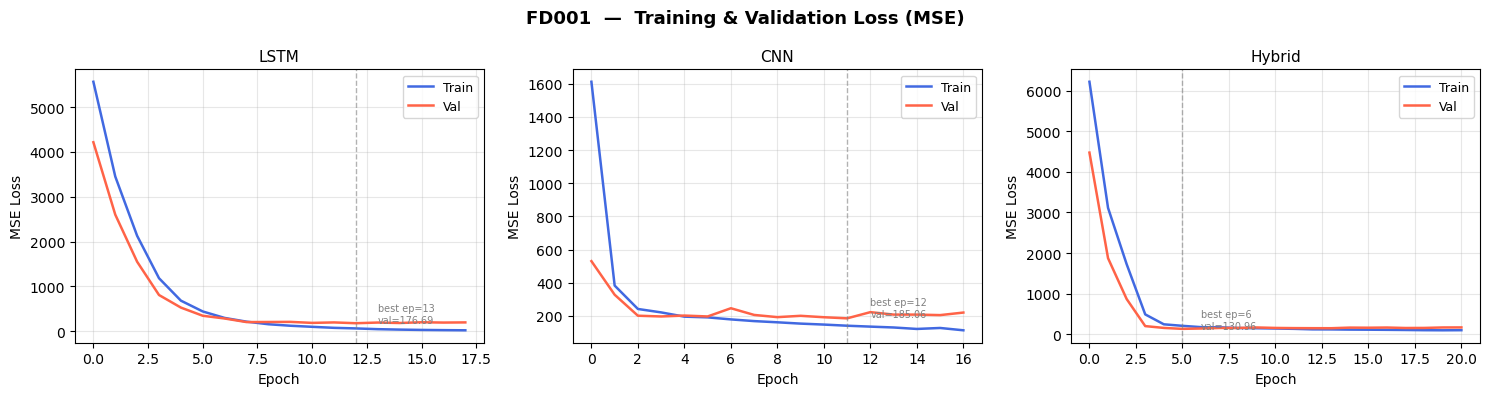

/var/folders/rl/8218144j1pb5dk0f4qcvnvz00000gn/T/ipykernel_31823/2839101537.py:196: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


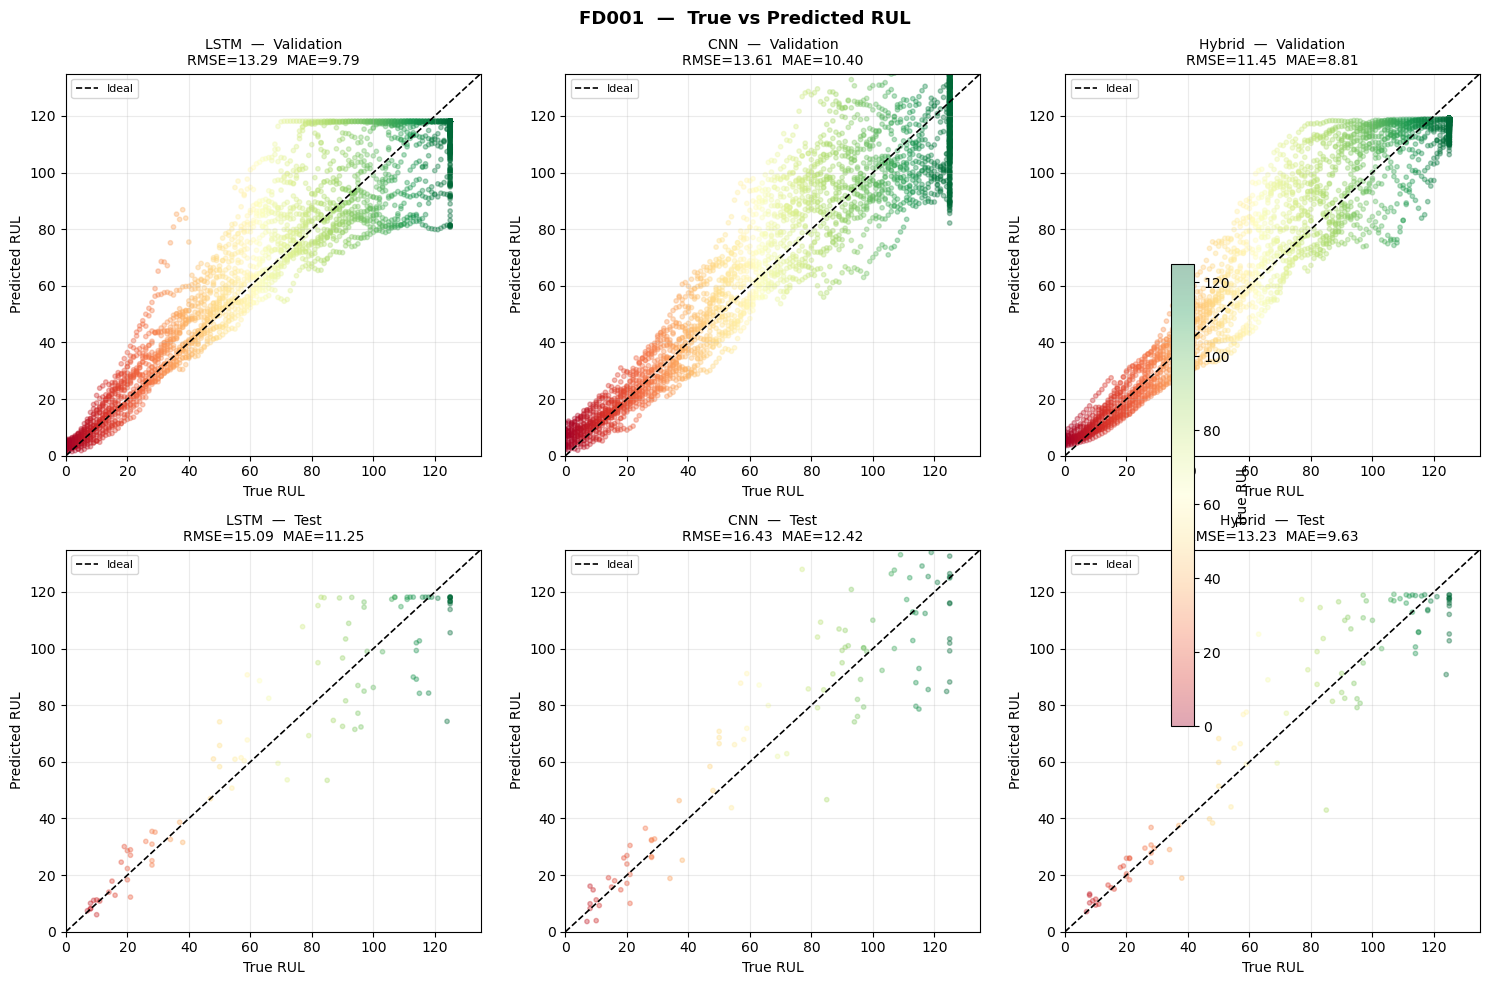


── Metrics (FD001) ──


,Dataset,Split,Metric,LSTM,CNN,Hybrid
0,FD001,Val,RMSE_all,13.2942,13.6077,11.4453
1,FD001,Val,MAE_all,9.7870,10.3953,8.8082
2,FD001,Val,RMSE_HIGH,8.5301,5.9772,5.2047
3,FD001,Val,MAE_HIGH,5.6239,4.7414,4.2590
4,FD001,Val,Accuracy,0.8609,0.8684,0.8622
5,FD001,Test,RMSE_all,15.0909,16.4301,13.2277
6,FD001,Test,MAE_all,11.2520,12.4201,9.6266
7,FD001,Test,RMSE_HIGH,4.9277,6.4823,5.0092
8,FD001,Test,MAE_HIGH,3.8754,5.1790,3.3511
9,FD001,Test,Accuracy,0.8900,0.8700,0.9200


In [78]:
# FD001 — re-trains all three models with loss tracking
# (The original FD001 model variables are kept intact above for the dashboard.)
results_fd001 = run_all_models_fd('FD001')



  FD002
FD002 | train engines=208 (33064 windows) | val engines=52 (7695 windows) | test engines=259

── LSTM ──
    Ep  1 | train=4135.199 | val=1999.825
    Ep  2 | train=1790.091 | val=1695.462
    Ep  3 | train=1682.526 | val=1411.109
    Ep  4 | train=1190.257 | val=1012.054
    Ep  5 | train=1008.055 | val=779.718
    Ep  6 | train=859.860 | val=722.387
    Ep  7 | train=709.235 | val=564.976
    Ep  8 | train=586.378 | val=495.464
    Ep  9 | train=483.301 | val=498.606
    Ep 10 | train=396.002 | val=288.794
    Ep 11 | train=349.207 | val=317.943
    Ep 12 | train=322.952 | val=285.550
    Ep 13 | train=291.585 | val=236.026
    Ep 14 | train=283.297 | val=230.930
    Ep 15 | train=268.950 | val=275.832
    Ep 16 | train=253.712 | val=309.490
    Ep 17 | train=248.063 | val=289.221
    Ep 18 | train=240.090 | val=218.970
    Ep 19 | train=234.915 | val=235.355
    Ep 20 | train=230.969 | val=254.002
    Ep 21 | train=226.151 | val=322.203
    Ep 22 | train=218.672 | val=266.4

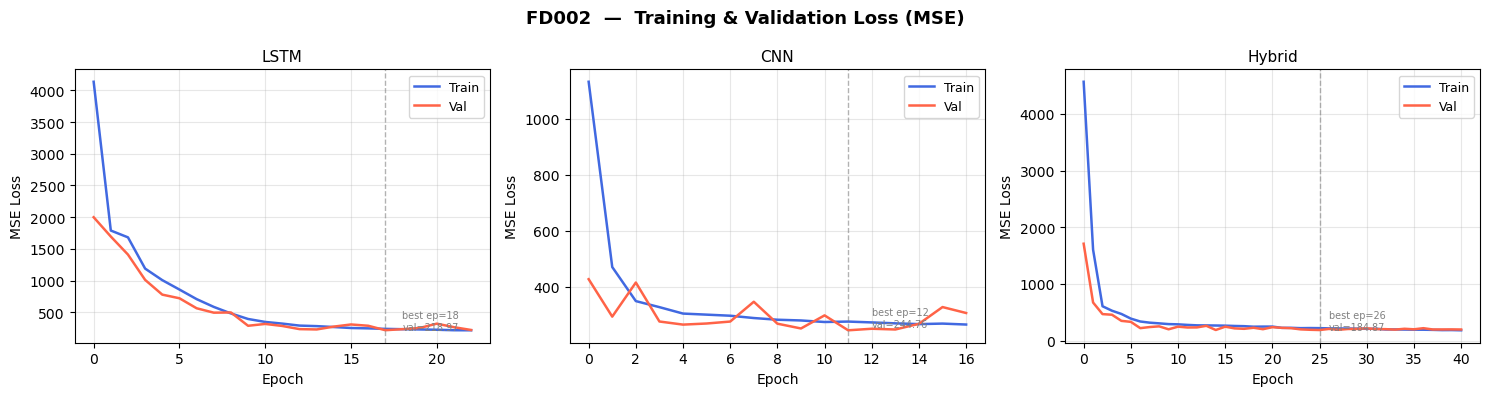

/var/folders/rl/8218144j1pb5dk0f4qcvnvz00000gn/T/ipykernel_31823/2839101537.py:196: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


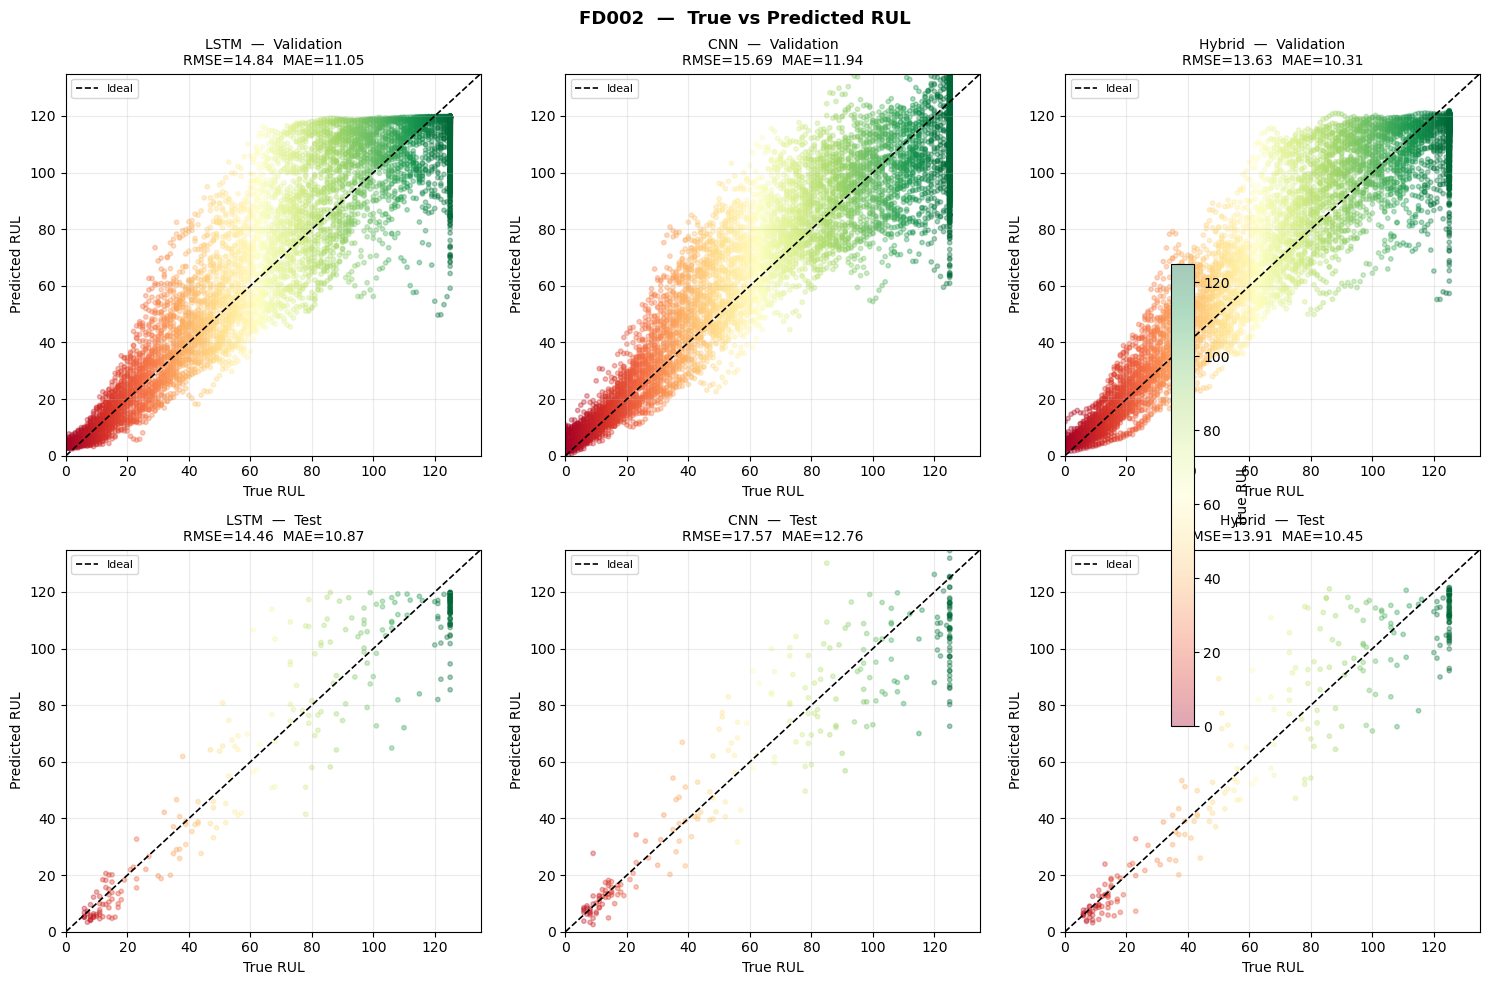


── Metrics (FD002) ──


,Dataset,Split,Metric,LSTM,CNN,Hybrid
0,FD002,Val,RMSE_all,14.8438,15.6937,13.6342
1,FD002,Val,MAE_all,11.0454,11.9431,10.3140
2,FD002,Val,RMSE_HIGH,8.8947,9.4429,8.7191
3,FD002,Val,MAE_HIGH,5.9196,6.5039,6.0723
4,FD002,Val,Accuracy,0.8326,0.8339,0.8525
5,FD002,Test,RMSE_all,14.4596,17.5743,13.9099
6,FD002,Test,MAE_all,10.8712,12.7619,10.4519
7,FD002,Test,RMSE_HIGH,6.2238,6.5912,5.6486
8,FD002,Test,MAE_HIGH,4.7954,4.1697,4.1183
9,FD002,Test,Accuracy,0.8533,0.8340,0.8571


In [79]:
# FD002 — 260 engines, 6 operating conditions, 1 fault mode
results_fd002 = run_all_models_fd('FD002')



  FD003
FD003 | train engines=80 (16012 windows) | val engines=20 (3708 windows) | test engines=100

── LSTM ──
    Ep  1 | train=6696.291 | val=4659.216
    Ep  2 | train=3810.656 | val=2545.482
    Ep  3 | train=1918.229 | val=1104.633
    Ep  4 | train=848.950 | val=524.825
    Ep  5 | train=405.048 | val=331.672
    Ep  6 | train=230.668 | val=215.672
    Ep  7 | train=149.174 | val=179.164
    Ep  8 | train=99.892 | val=159.962
    Ep  9 | train=79.279 | val=167.698
    Ep 10 | train=65.262 | val=156.232
    Ep 11 | train=51.278 | val=165.497
    Ep 12 | train=36.114 | val=201.434
    Ep 13 | train=30.039 | val=209.803
    Ep 14 | train=24.624 | val=199.730
    Ep 15 | train=21.278 | val=195.043
    Early stop @ ep 15

── CNN ──
    Ep  1 | train=1382.414 | val=402.232
    Ep  2 | train=418.961 | val=251.398
    Ep  3 | train=290.461 | val=175.094
    Ep  4 | train=261.966 | val=169.316
    Ep  5 | train=245.565 | val=181.394
    Ep  6 | train=223.141 | val=153.424
    Ep  7 | tr

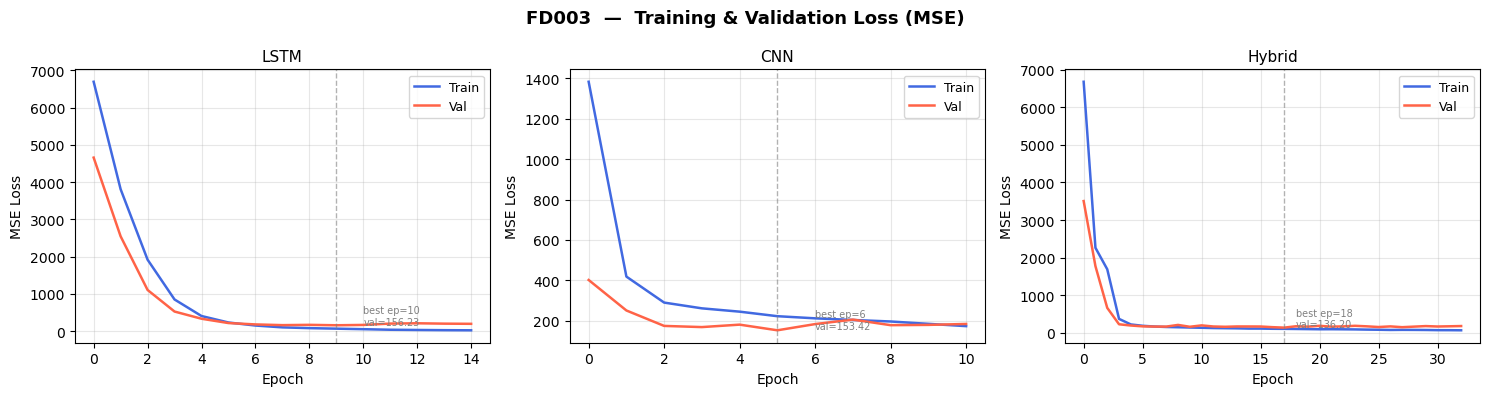

/var/folders/rl/8218144j1pb5dk0f4qcvnvz00000gn/T/ipykernel_31823/2839101537.py:196: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


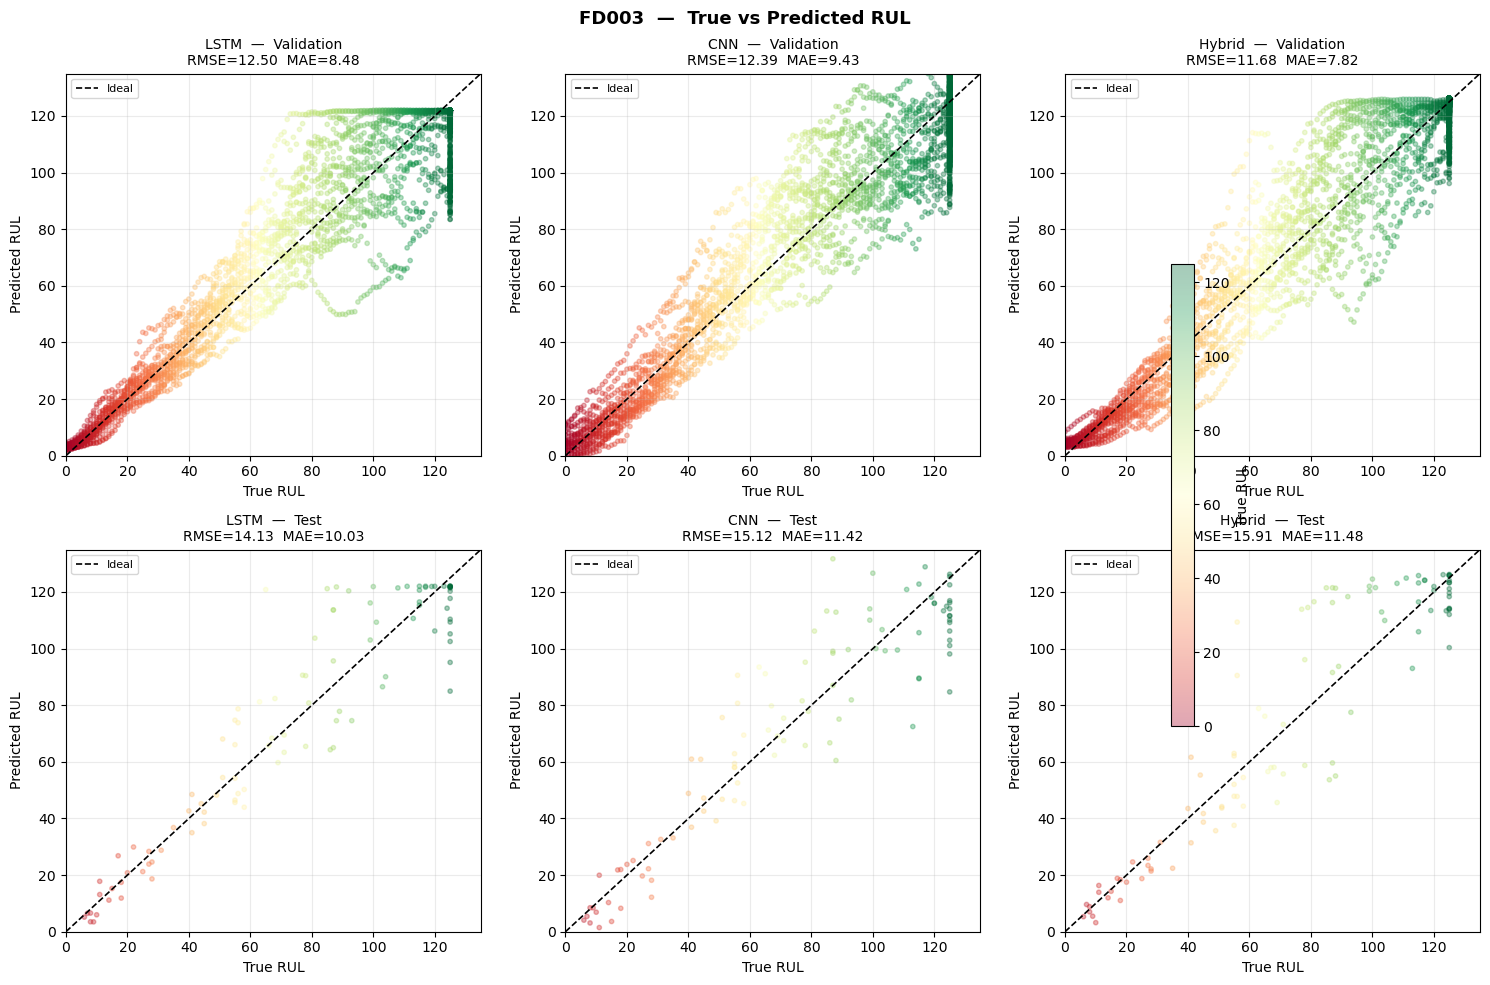


── Metrics (FD003) ──


,Dataset,Split,Metric,LSTM,CNN,Hybrid
0,FD003,Val,RMSE_all,12.5037,12.3906,11.6754
1,FD003,Val,MAE_all,8.4841,9.4302,7.8191
2,FD003,Val,RMSE_HIGH,4.8011,7.1214,6.4573
3,FD003,Val,MAE_HIGH,3.4912,5.5357,4.7184
4,FD003,Val,Accuracy,0.8999,0.8886,0.8878
5,FD003,Test,RMSE_all,14.1272,15.1203,15.9131
6,FD003,Test,MAE_all,10.0343,11.4150,11.4845
7,FD003,Test,RMSE_HIGH,4.5679,6.5124,4.5867
8,FD003,Test,MAE_HIGH,3.5925,5.2212,3.5084
9,FD003,Test,Accuracy,0.8700,0.8800,0.8700


In [80]:
# FD003 — 100 engines, 1 operating condition, 2 fault modes
results_fd003 = run_all_models_fd('FD003')



  FD004
FD004 | train engines=199 (39344 windows) | val engines=50 (9455 windows) | test engines=248

── LSTM ──
    Ep  1 | train=4781.028 | val=2211.664
    Ep  2 | train=1831.203 | val=1779.283
    Ep  3 | train=1755.011 | val=1779.254
    Ep  4 | train=1630.118 | val=1375.227
    Ep  5 | train=1235.648 | val=1539.154
    Ep  6 | train=813.694 | val=1282.036
    Ep  7 | train=609.293 | val=817.661
    Ep  8 | train=467.647 | val=569.117
    Ep  9 | train=375.777 | val=487.344
    Ep 10 | train=314.159 | val=500.597
    Ep 11 | train=265.276 | val=511.990
    Ep 12 | train=227.287 | val=498.060
    Ep 13 | train=202.785 | val=565.971
    Ep 14 | train=168.396 | val=579.826
    Early stop @ ep 14

── CNN ──
    Ep  1 | train=1045.827 | val=649.903
    Ep  2 | train=487.430 | val=536.009
    Ep  3 | train=444.863 | val=507.110
    Ep  4 | train=424.703 | val=526.274
    Ep  5 | train=414.326 | val=610.315
    Ep  6 | train=400.880 | val=480.382
    Ep  7 | train=378.297 | val=444.246


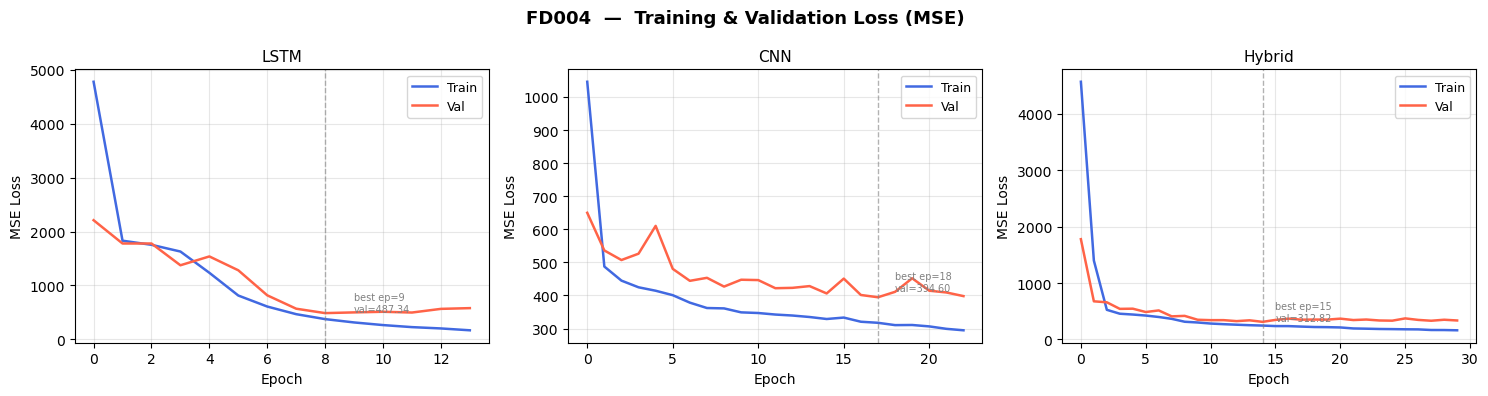

/var/folders/rl/8218144j1pb5dk0f4qcvnvz00000gn/T/ipykernel_31823/2839101537.py:196: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


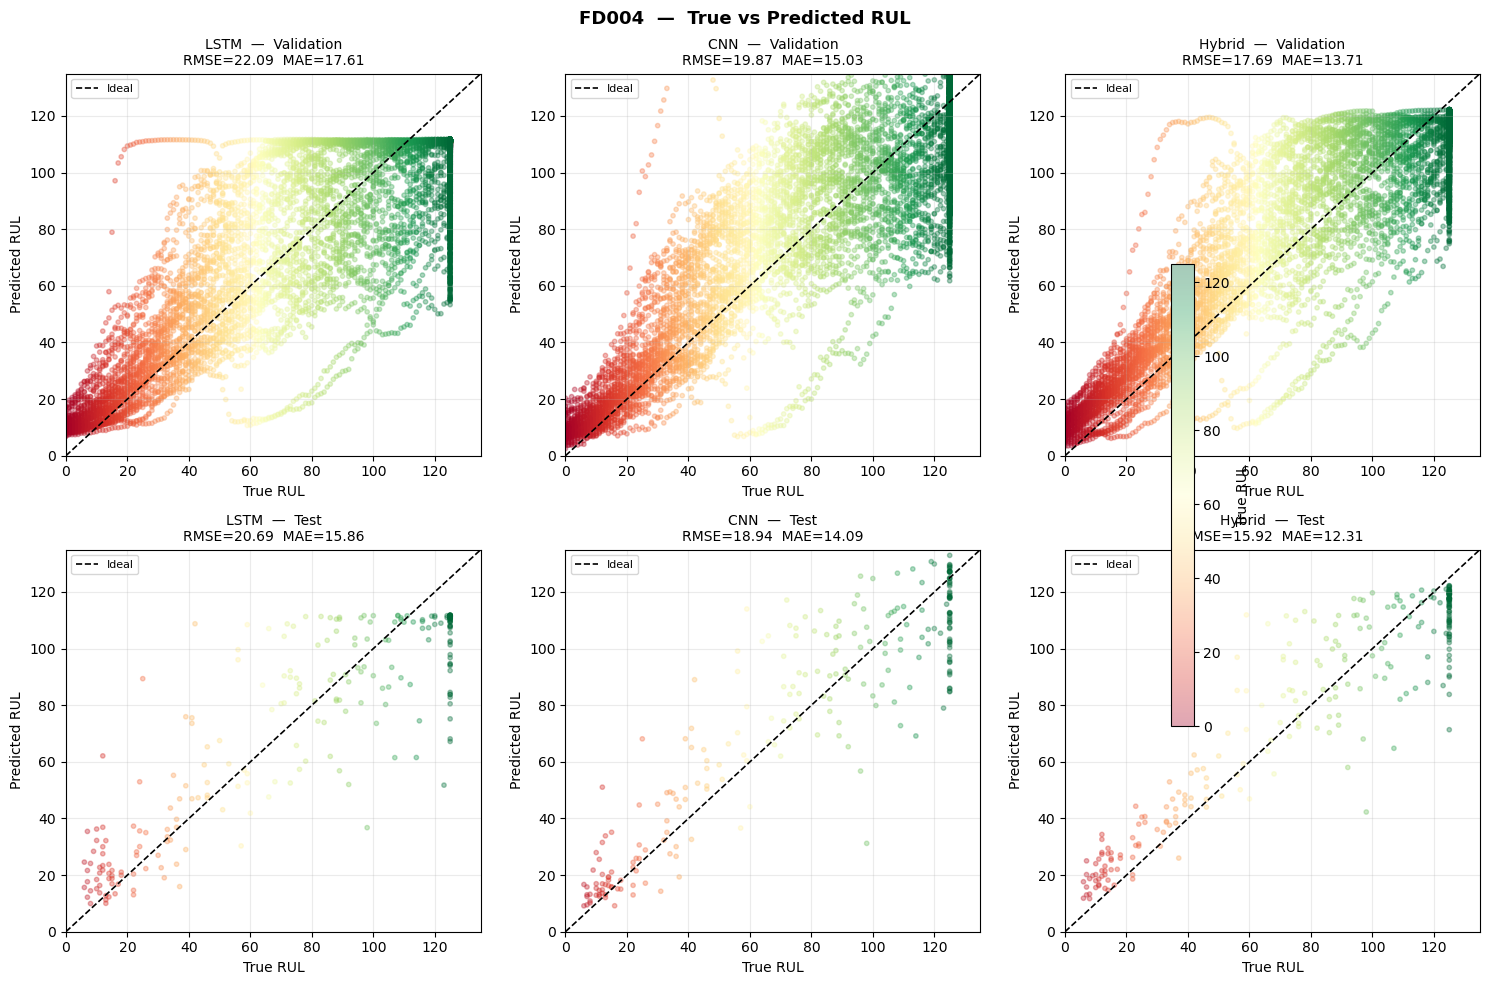


── Metrics (FD004) ──


,Dataset,Split,Metric,LSTM,CNN,Hybrid
0,FD004,Val,RMSE_all,22.0899,19.8744,17.6926
1,FD004,Val,MAE_all,17.6052,15.0262,13.7095
2,FD004,Val,RMSE_HIGH,16.3890,15.2642,13.9306
3,FD004,Val,MAE_HIGH,11.0080,9.8530,10.7513
4,FD004,Val,Accuracy,0.7808,0.8116,0.8356
5,FD004,Test,RMSE_all,20.6907,18.9359,15.9168
6,FD004,Test,MAE_all,15.8620,14.0897,12.3107
7,FD004,Test,RMSE_HIGH,15.7713,11.8253,10.4181
8,FD004,Test,MAE_HIGH,10.9930,8.2829,9.1225
9,FD004,Test,Accuracy,0.8266,0.8266,0.8427


In [81]:
# FD004 — 248 engines, 6 operating conditions, 2 fault modes
results_fd004 = run_all_models_fd('FD004')


=== Full Cross-Dataset Results ===


,Dataset,Split,Model,RMSE,MAE,RMSE_HIGH,MAE_HIGH,Accuracy
0,FD001,Val,LSTM,13.29,9.79,8.53,5.62,86.1
1,FD001,Val,CNN,13.61,10.40,5.98,4.74,86.8
2,FD001,Val,HYBRID,11.45,8.81,5.20,4.26,86.2
3,FD001,Test,LSTM,15.09,11.25,4.93,3.88,89.0
4,FD001,Test,CNN,16.43,12.42,6.48,5.18,87.0
5,FD001,Test,HYBRID,13.23,9.63,5.01,3.35,92.0
6,FD002,Val,LSTM,14.84,11.05,8.89,5.92,83.3
7,FD002,Val,CNN,15.69,11.94,9.44,6.50,83.4
8,FD002,Val,HYBRID,13.63,10.31,8.72,6.07,85.3
9,FD002,Test,LSTM,14.46,10.87,6.22,4.80,85.3



=== Test RMSE (all windows) ===


Model,LSTM,CNN,HYBRID
Dataset,,,
FD001,15.09,16.43,13.23
FD002,14.46,17.57,13.91
FD003,14.13,15.12,15.91
FD004,20.69,18.94,15.92



=== Test Accuracy (%) ===


Model,LSTM,CNN,HYBRID
Dataset,,,
FD001,89.0,87.0,92.0
FD002,85.3,83.4,85.7
FD003,87.0,88.0,87.0
FD004,82.7,82.7,84.3


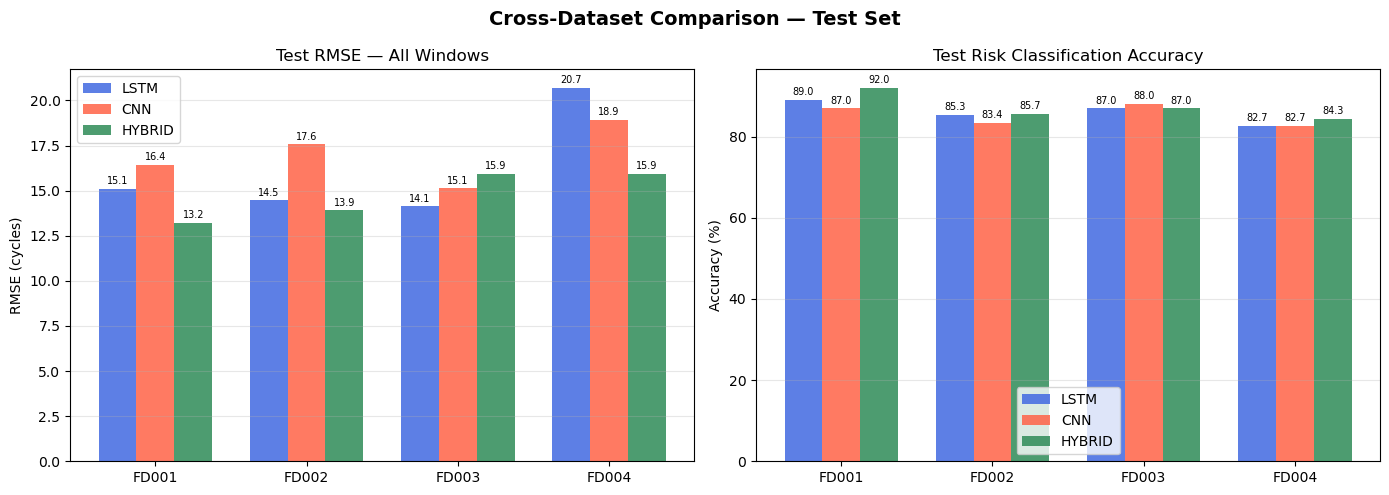

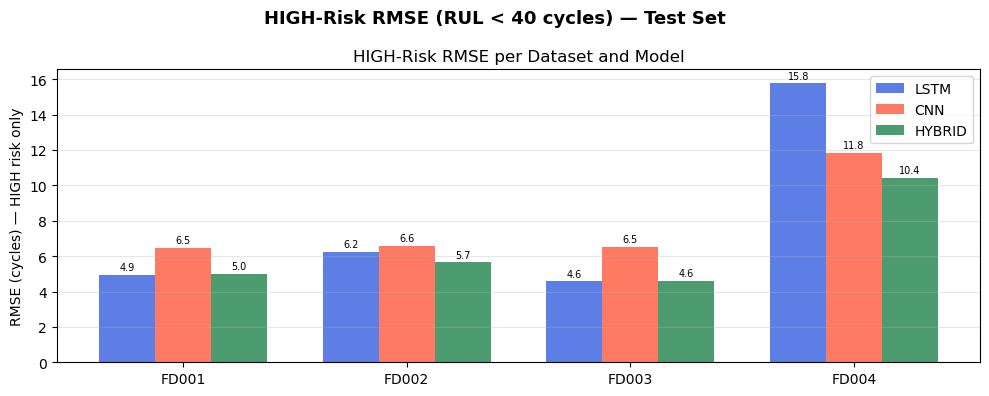

In [82]:
# ─────────────────────────────────────────────────────────────────────────
# Cross-dataset summary: combined metrics table + RMSE bar charts
# Run AFTER results_fd001, results_fd002, results_fd003, results_fd004
# ─────────────────────────────────────────────────────────────────────────

results = {
    'FD001': results_fd001,
    'FD002': results_fd002,
    'FD003': results_fd003,
    'FD004': results_fd004,
}

# ── 1. Combined metrics DataFrame ─────────────────────────────────────────
rows = []
for fd, res in results.items():
    for split, md in [('Val', res['metrics_val']), ('Test', res['metrics_test'])]:
        for model in ['lstm', 'cnn', 'hybrid']:
            m = md[model]
            rows.append({
                'Dataset': fd,
                'Split':   split,
                'Model':   model.upper(),
                'RMSE':    round(m['RMSE_all'],  2),
                'MAE':     round(m['MAE_all'],   2),
                'RMSE_HIGH': round(m['RMSE_HIGH'], 2) if not (isinstance(m['RMSE_HIGH'], float) and np.isnan(m['RMSE_HIGH'])) else float('nan'),
                'MAE_HIGH':  round(m['MAE_HIGH'],  2) if not (isinstance(m['MAE_HIGH'],  float) and np.isnan(m['MAE_HIGH']))  else float('nan'),
                'Accuracy':  round(m['Accuracy'] * 100, 1),
            })

df_all = pd.DataFrame(rows)
print("=== Full Cross-Dataset Results ===")
display(df_all)

# ── 2. Pivot table: RMSE (Test) per dataset × model ──────────────────────
pivot_rmse = df_all[df_all['Split'] == 'Test'].pivot_table(
    index='Dataset', columns='Model', values='RMSE'
)[['LSTM', 'CNN', 'HYBRID']]
print("\n=== Test RMSE (all windows) ===")
display(pivot_rmse)

pivot_acc = df_all[df_all['Split'] == 'Test'].pivot_table(
    index='Dataset', columns='Model', values='Accuracy'
)[['LSTM', 'CNN', 'HYBRID']]
print("\n=== Test Accuracy (%) ===")
display(pivot_acc)

# ── 3. RMSE bar chart (Test — all windows) ───────────────────────────────
datasets = ['FD001', 'FD002', 'FD003', 'FD004']
models   = ['LSTM', 'CNN', 'HYBRID']
colors   = ['royalblue', 'tomato', 'seagreen']
x        = np.arange(len(datasets))
width    = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cross-Dataset Comparison — Test Set', fontsize=14, fontweight='bold')

# RMSE (all)
ax = axes[0]
for i, (model, color) in enumerate(zip(models, colors)):
    vals = [df_all[(df_all['Dataset']==fd) & (df_all['Split']=='Test') &
                   (df_all['Model']==model)]['RMSE'].values[0]
            for fd in datasets]
    bars = ax.bar(x + i*width, vals, width, label=model, color=color, alpha=0.85)
    ax.bar_label(bars, fmt='%.1f', fontsize=7, padding=2)
ax.set_xticks(x + width)
ax.set_xticklabels(datasets)
ax.set_ylabel('RMSE (cycles)')
ax.set_title('Test RMSE — All Windows')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# Accuracy (%)
ax = axes[1]
for i, (model, color) in enumerate(zip(models, colors)):
    vals = [df_all[(df_all['Dataset']==fd) & (df_all['Split']=='Test') &
                   (df_all['Model']==model)]['Accuracy'].values[0]
            for fd in datasets]
    bars = ax.bar(x + i*width, vals, width, label=model, color=color, alpha=0.85)
    ax.bar_label(bars, fmt='%.1f', fontsize=7, padding=2)
ax.set_xticks(x + width)
ax.set_xticklabels(datasets)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Test Risk Classification Accuracy')
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ── 4. HIGH-risk RMSE bar chart ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle('HIGH-Risk RMSE (RUL < 40 cycles) — Test Set', fontsize=13, fontweight='bold')
for i, (model, color) in enumerate(zip(models, colors)):
    vals = []
    for fd in datasets:
        v = df_all[(df_all['Dataset']==fd) & (df_all['Split']=='Test') &
                   (df_all['Model']==model)]['RMSE_HIGH'].values[0]
        vals.append(v)
    bars = ax.bar(x + i*width, vals, width, label=model, color=color, alpha=0.85)
    ax.bar_label(bars, fmt='%.1f', fontsize=7, padding=2)
ax.set_xticks(x + width)
ax.set_xticklabels(datasets)
ax.set_ylabel('RMSE (cycles) — HIGH risk only')
ax.set_title('HIGH-Risk RMSE per Dataset and Model')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Saving to: /Users/mostafa/xai_predictive_maintenance/Thesis_Report/figures


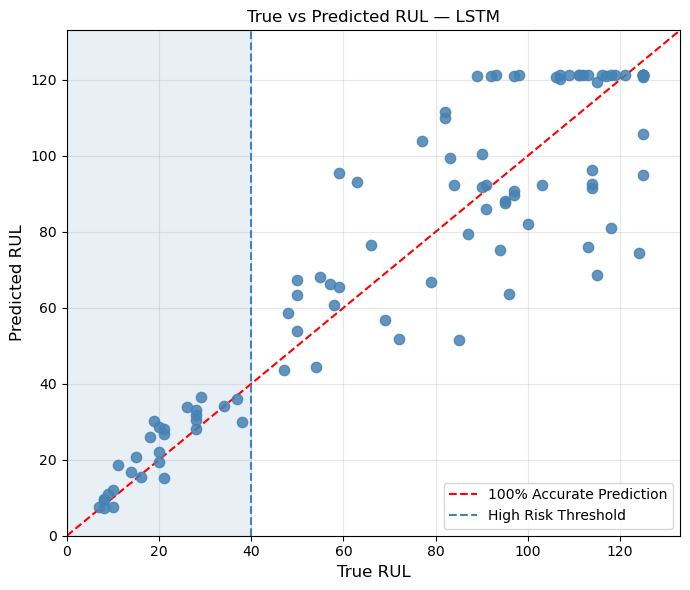

Saved: /Users/mostafa/xai_predictive_maintenance/Thesis_Report/figures/lstm_test_scatter.png


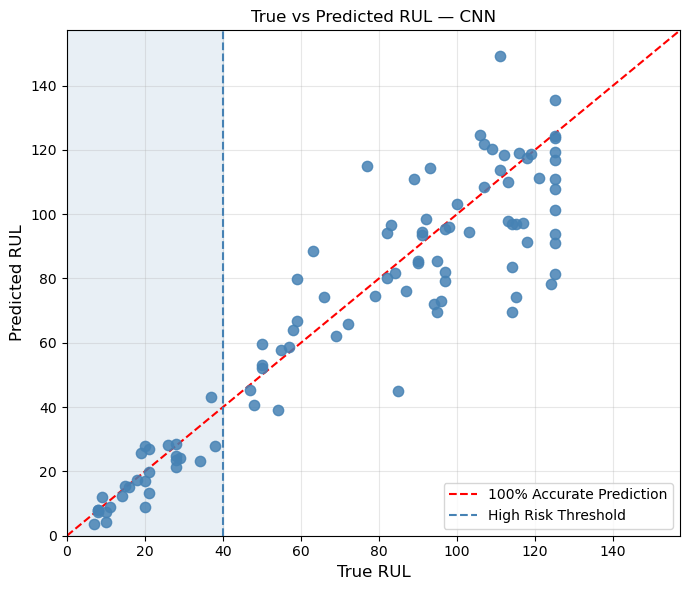

Saved: /Users/mostafa/xai_predictive_maintenance/Thesis_Report/figures/cnn_test_scatter.png


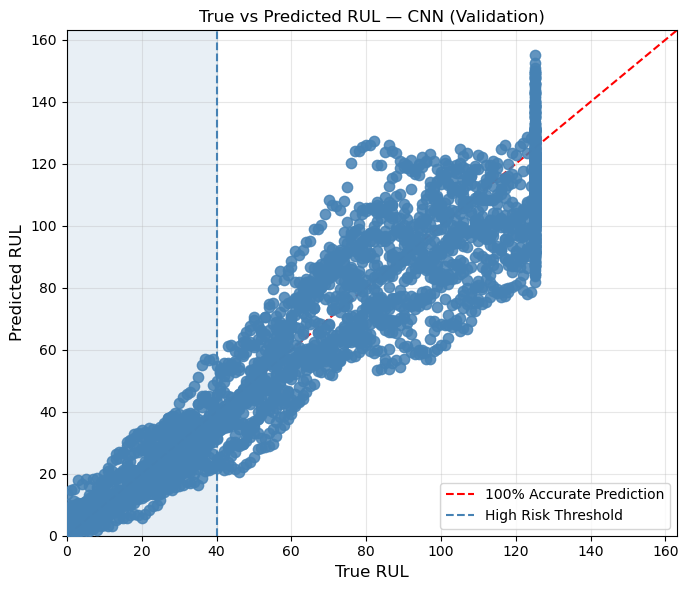

Saved: /Users/mostafa/xai_predictive_maintenance/Thesis_Report/figures/cnn_val_scatter.png


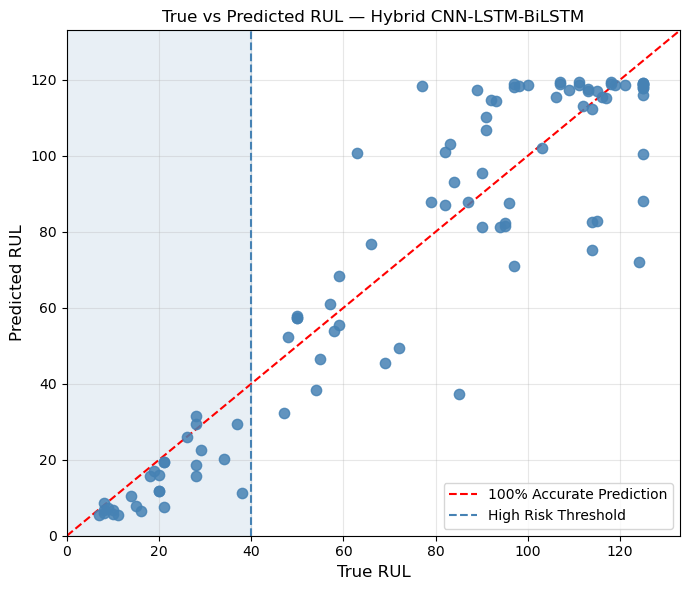

Saved: /Users/mostafa/xai_predictive_maintenance/Thesis_Report/figures/hybrid_test_scatter.png


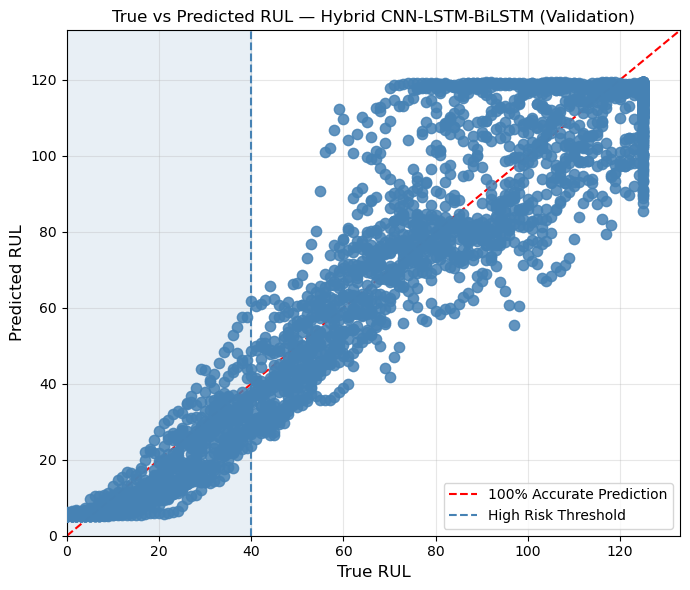

Saved: /Users/mostafa/xai_predictive_maintenance/Thesis_Report/figures/hybrid_val_scatter.png


In [86]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd

# ── Correct path — go up one level from notebooks/ ────────────────────────
FIGURES = os.path.abspath(os.path.join(os.getcwd(), '..', 'Thesis_Report', 'figures'))
os.makedirs(FIGURES, exist_ok=True)
print("Saving to:", FIGURES)

# ── Build CNN test comparison if not already defined ───────────────────────
cnn_model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32)
    cnn_test_preds = cnn_model(X_test_tensor).numpy().flatten()

comparison_df_cnn = pd.DataFrame({
    'True_RUL':      true_rul_test.values,
    'Predicted_RUL': cnn_test_preds,
})

# CNN validation arrays (rebuild if not defined)
cnn_val_true, cnn_val_preds = [], []
cnn_model.eval()
with torch.no_grad():
    for i in range(len(X_val)):
        cnn_val_preds.append(cnn_model(X_val[i].unsqueeze(0)).item())
        cnn_val_true.append(y_val_np[i])
cnn_val_true  = np.array(cnn_val_true)
cnn_val_preds = np.array(cnn_val_preds)

# ── Plot function ──────────────────────────────────────────────────────────
def plot_test_scatter(true_rul, pred_rul, model_name, save_path):
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.axvspan(0, 40, alpha=0.12, color='steelblue')
    ax.scatter(true_rul, pred_rul, color='steelblue', s=55, alpha=0.85, zorder=3)
    lim = max(np.max(true_rul), np.max(pred_rul)) + 8
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='100% Accurate Prediction')
    ax.axvline(x=40, color='steelblue', linestyle='--', linewidth=1.5, label='High Risk Threshold')
    ax.set_xlabel('True RUL', fontsize=12)
    ax.set_ylabel('Predicted RUL', fontsize=12)
    ax.set_title(f'True vs Predicted RUL — {model_name}', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

# ── Generate all figures ───────────────────────────────────────────────────
plot_test_scatter(
    comparison_df['True_RUL'].values, comparison_df['Predicted_RUL'].values,
    'LSTM', os.path.join(FIGURES, 'lstm_test_scatter.png')
)
plot_test_scatter(
    comparison_df_cnn['True_RUL'].values, comparison_df_cnn['Predicted_RUL'].values,
    'CNN', os.path.join(FIGURES, 'cnn_test_scatter.png')
)
plot_test_scatter(
    cnn_val_true, cnn_val_preds,
    'CNN (Validation)', os.path.join(FIGURES, 'cnn_val_scatter.png')
)

# Hybrid test
hybrid_model.eval()
with torch.no_grad():
    hybrid_test_preds = hybrid_model(X_test_tensor).numpy().flatten()
plot_test_scatter(
    true_rul_test.values, hybrid_test_preds,
    'Hybrid CNN-LSTM-BiLSTM', os.path.join(FIGURES, 'hybrid_test_scatter.png')
)

# Hybrid validation
hybrid_val_preds = []
hybrid_model.eval()
with torch.no_grad():
    for i in range(len(X_val)):
        hybrid_val_preds.append(hybrid_model(X_val[i].unsqueeze(0)).item())
plot_test_scatter(
    y_val_np, np.array(hybrid_val_preds),
    'Hybrid CNN-LSTM-BiLSTM (Validation)', os.path.join(FIGURES, 'hybrid_val_scatter.png')
)

In [93]:
input_size = len(feature_cols)
model = LSTMAttentionModel(input_size, hidden_size=96)
model.load_state_dict(torch.load("../data/model.pth", map_location="cpu"))
model.eval()
print("Model loaded successfully")

Model loaded successfully


In [94]:
# pick any machine_id from your validation set
machine_id = val_ids[0]  # or any specific id e.g. 91

machine_df   = df[df["machine_id"] == machine_id]
window       = machine_df.iloc[-50:]   # last 50 cycles = WINDOW_SIZE
window_array = window[feature_cols].values  # shape (50, 24)

sample_input = torch.tensor(window_array, dtype=torch.float32).unsqueeze(0)  # (1, 50, 24)

In [95]:
from captum.attr import IntegratedGradients, Occlusion
from scipy.stats import spearmanr
import numpy as np

# ── pick any engine window you already have as a tensor ──────────────────
# sample_input shape: (1, 50, 24)
sample_input = torch.tensor(window_array, dtype=torch.float32).unsqueeze(0)

# ── Integrated Gradients ─────────────────────────────────────────────────
def forward_rul_only(x):
    rul_pred, _ = model(x)
    return rul_pred

ig        = IntegratedGradients(forward_rul_only)
baseline  = torch.zeros_like(sample_input)
ig_attr   = ig.attribute(sample_input, baselines=baseline, n_steps=50)
ig_np     = ig_attr.squeeze().detach().numpy()          # (50, 24)
ig_importance = np.mean(np.abs(ig_np), axis=0)          # (24,) per-sensor

# ── Occlusion Sensitivity ────────────────────────────────────────────────
occlusion    = Occlusion(forward_rul_only)
occ_attr     = occlusion.attribute(
    sample_input, baselines=0,
    sliding_window_shapes=(3, 1), strides=(1, 1)
)
occ_np        = occ_attr.squeeze().detach().numpy()     # (50, 24)
occ_importance = np.mean(np.abs(occ_np), axis=0)        # (24,) per-sensor

# ── Spearman Correlation ─────────────────────────────────────────────────
corr, _ = spearmanr(ig_importance, occ_importance)
print(f"Spearman correlation (IG vs Occlusion): {corr:.3f}")

Spearman correlation (IG vs Occlusion): 0.958


In [96]:
correlations = []

for machine_id in val_ids:
    machine_df   = df[df["machine_id"] == machine_id]
    window       = machine_df.iloc[-50:]
    window_array = window[feature_cols].values
    sample_input = torch.tensor(window_array, dtype=torch.float32).unsqueeze(0)

    # IG
    ig_attr       = ig.attribute(sample_input, baselines=torch.zeros_like(sample_input), n_steps=50)
    ig_importance = np.mean(np.abs(ig_attr.squeeze().detach().numpy()), axis=0)

    # Occlusion
    occ_attr       = occlusion.attribute(sample_input, baselines=0,
                                         sliding_window_shapes=(3, 1), strides=(1, 1))
    occ_importance = np.mean(np.abs(occ_attr.squeeze().detach().numpy()), axis=0)

    # Spearman
    if np.std(ig_importance) > 0 and np.std(occ_importance) > 0:
        corr, _ = spearmanr(ig_importance, occ_importance)
        correlations.append(corr)

print(f"Average Spearman correlation across all validation engines: {np.mean(correlations):.3f}")

Average Spearman correlation across all validation engines: 0.952


In [101]:
# ─────────────────────────────────────────────────────────────────────────
# Cross-method Spearman rank correlation — FD001 validation set ONLY
# Uses ALL validation windows 
# ─────────────────────────────────────────────────────────────────────────
from captum.attr import IntegratedGradients, Occlusion
from scipy.stats import spearmanr
import numpy as np
import torch
import torch.nn as nn

# Explicitly use FD001 validation tensors (X_val, y_val_np from cells 12-13)
# These are guaranteed to be FD001 — not affected by multi-dataset cells 79-84
assert X_val.shape[1] == 50 and X_val.shape[2] == 24, \
    "X_val doesn't look like FD001 windows — check variable scope"

occlusion_cnn = Occlusion(cnn_model)
ig_cnn        = IntegratedGradients(cnn_model)

ig_occ_corrs  = []   # CNN: IG  vs Occlusion
lrp_ig_corrs  = []   # CNN: LRP vs IG
lrp_occ_corrs = []   # CNN: LRP vs Occlusion

cnn_model.eval()

# Use ALL validation windows, not just last window per engine
for idx in range(len(X_val)):
    si = X_val[idx].unsqueeze(0)   # shape: (1, 50, 24)

    # ── CNN: IG ───────────────────────────────────────────────────────
    ig_attr  = ig_cnn.attribute(si,
                                baselines=torch.zeros_like(si),
                                n_steps=50)
    ig_imp   = np.mean(np.abs(ig_attr.squeeze().detach().numpy()), axis=0)
    # ig_imp shape: (24,) — one score per sensor

    # ── CNN: Occlusion ────────────────────────────────────────────────
    occ_attr = occlusion_cnn.attribute(si,
                                       baselines=0,
                                       sliding_window_shapes=(3, 1),
                                       strides=(1, 1))
    occ_imp  = np.mean(np.abs(occ_attr.squeeze().detach().numpy()), axis=0)

    # ── CNN: LRP ──────────────────────────────────────────────────────
    for _mod in cnn_model.modules():
        if isinstance(_mod, (nn.Conv1d, nn.Linear, nn.ReLU, nn.Dropout)):
            _mod.rule = _EpsilonRule()
    lrp_np  = _LRP(cnn_model).attribute(si).squeeze().detach().numpy()
    lrp_imp = np.mean(np.abs(lrp_np), axis=0)

    # ── Spearman (only if non-constant) ──────────────────────────────
    if np.std(ig_imp) > 0 and np.std(occ_imp) > 0:
        c, _ = spearmanr(ig_imp, occ_imp)
        ig_occ_corrs.append(c)

    if np.std(lrp_imp) > 0 and np.std(ig_imp) > 0:
        c, _ = spearmanr(lrp_imp, ig_imp)
        lrp_ig_corrs.append(c)

    if np.std(lrp_imp) > 0 and np.std(occ_imp) > 0:
        c, _ = spearmanr(lrp_imp, occ_imp)
        lrp_occ_corrs.append(c)

print(f"FD001 Validation — {len(X_val)} windows across {len(val_ids)} engines")
print(f"CNN — IG  vs Occlusion : {np.mean(ig_occ_corrs):.3f}  (n={len(ig_occ_corrs)})")
print(f"CNN — LRP vs IG        : {np.mean(lrp_ig_corrs):.3f}  (n={len(lrp_ig_corrs)})")
print(f"CNN — LRP vs Occlusion : {np.mean(lrp_occ_corrs):.3f}  (n={len(lrp_occ_corrs)})")

FD001 Validation — 3070 windows across 20 engines
CNN — IG  vs Occlusion : 0.943  (n=3070)
CNN — LRP vs IG        : 0.933  (n=3070)
CNN — LRP vs Occlusion : 0.886  (n=3070)


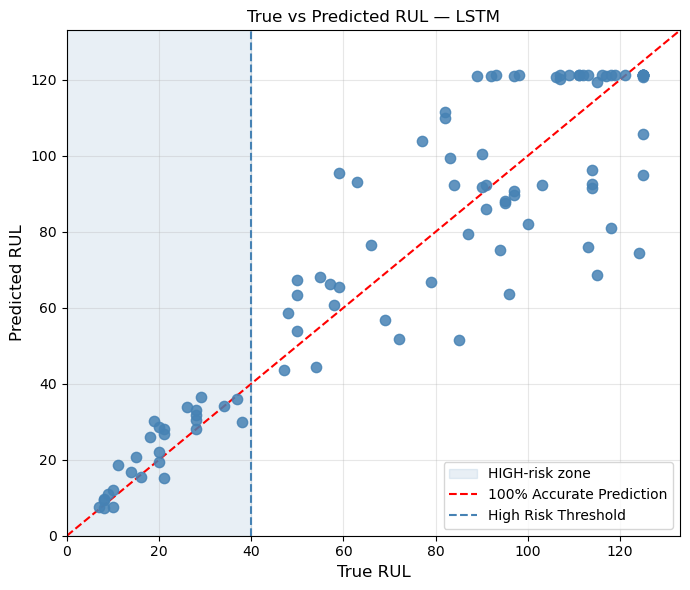

Saved: /Users/mostafa/xai_predictive_maintenance/Thesis_Report/figures/lstm_test_scatter.png


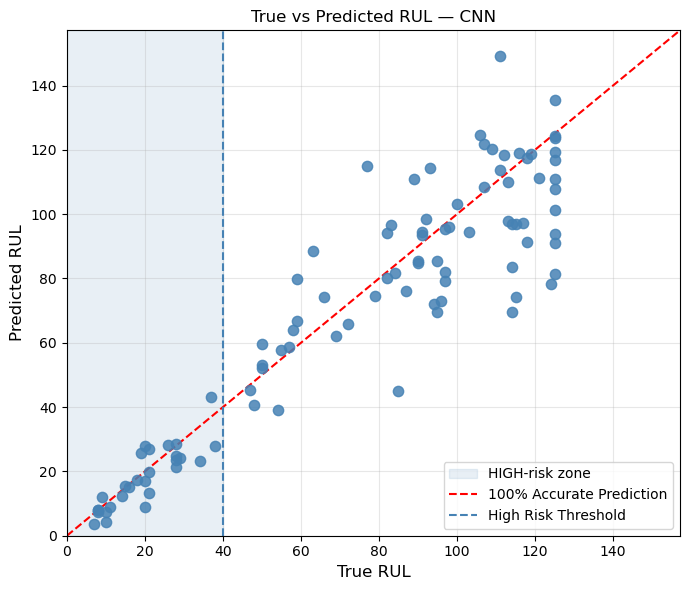

Saved: /Users/mostafa/xai_predictive_maintenance/Thesis_Report/figures/cnn_test_scatter.png


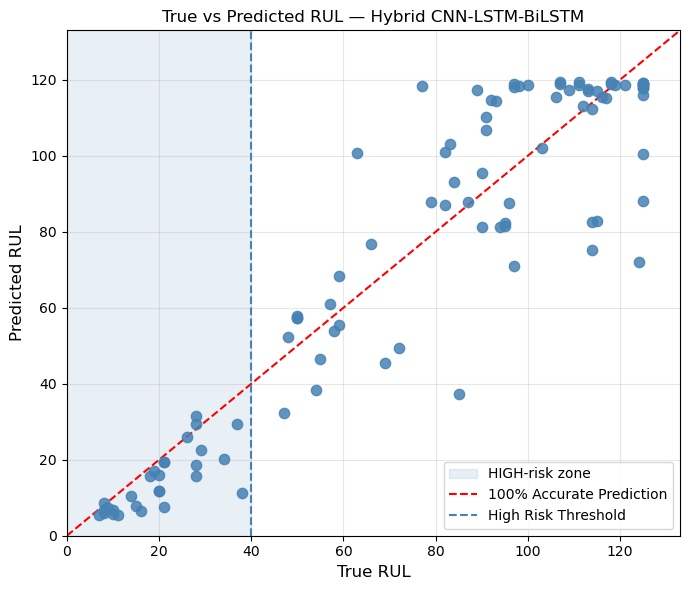

Saved: /Users/mostafa/xai_predictive_maintenance/Thesis_Report/figures/hybrid_test_scatter.png


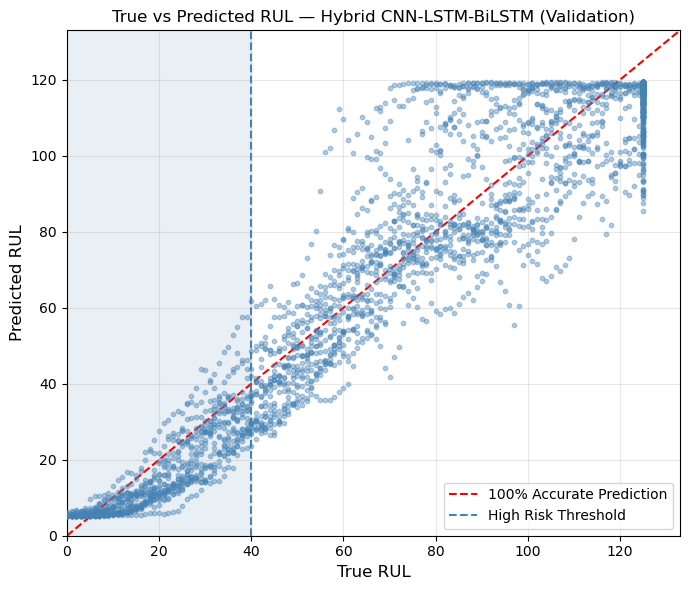

All scatter plots saved.


In [102]:
import os, numpy as np, matplotlib.pyplot as plt, torch, pandas as pd

FIGURES = os.path.abspath(os.path.join(os.getcwd(), '..', 'Thesis_Report', 'figures'))
os.makedirs(FIGURES, exist_ok=True)

# ── Shared test tensor (all three models use SAME input) ──────────────────
X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32)
true_test_rul = true_rul_test.values          # shape (100,) — ground truth

# ── LSTM test predictions ─────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    lstm_test_preds = []
    for i in range(len(X_test_tensor)):
        pred, _ = model(X_test_tensor[i].unsqueeze(0))
        lstm_test_preds.append(pred.item())
lstm_test_preds = np.maximum(np.array(lstm_test_preds), 0)  # clip negatives

# ── CNN test predictions ───────────────────────────────────────────────────
cnn_model.eval()
with torch.no_grad():
    cnn_test_preds = cnn_model(X_test_tensor).numpy().flatten()
cnn_test_preds = np.maximum(cnn_test_preds, 0)              # clip negatives

# ── Hybrid test predictions ───────────────────────────────────────────────
hybrid_model.eval()
with torch.no_grad():
    hybrid_test_preds = hybrid_model(X_test_tensor).numpy().flatten()
hybrid_test_preds = np.maximum(hybrid_test_preds, 0)        # clip negatives

# ─────────────────────────────────────────────────────────────────────────
def plot_test_scatter(true_rul, pred_rul, model_name, save_path):
    """
    Scatter plot of true vs predicted RUL on the TEST set (100 engines).
    Predictions are already clipped to >= 0.
    """
    fig, ax = plt.subplots(figsize=(7, 6))

    lim = max(np.max(true_rul), np.max(pred_rul)) + 8

    ax.axvspan(0, 40, alpha=0.12, color='steelblue', label='HIGH-risk zone')
    ax.scatter(true_rul, pred_rul,
               color='steelblue', s=55, alpha=0.85, zorder=3)
    ax.plot([0, lim], [0, lim],
            'r--', linewidth=1.5, label='100% Accurate Prediction')
    ax.axvline(x=40, color='steelblue', linestyle='--',
               linewidth=1.5, label='High Risk Threshold')

    ax.set_xlabel('True RUL', fontsize=12)
    ax.set_ylabel('Predicted RUL', fontsize=12)
    ax.set_title(f'True vs Predicted RUL — {model_name}', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # Both axes start at 0 — predictions already clipped so no data lost
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

# ── All three TEST scatter plots — comparable (same 100 engines each) ─────
plot_test_scatter(
    true_test_rul, lstm_test_preds,
    'LSTM',
    os.path.join(FIGURES, 'lstm_test_scatter.png')
)
plot_test_scatter(
    true_test_rul, cnn_test_preds,
    'CNN',
    os.path.join(FIGURES, 'cnn_test_scatter.png')
)
plot_test_scatter(
    true_test_rul, hybrid_test_preds,
    'Hybrid CNN-LSTM-BiLSTM',
    os.path.join(FIGURES, 'hybrid_test_scatter.png')
)

# ── Validation scatter (all windows, for thesis Figure 5.9 hybrid) ────────
hybrid_val_preds = []
hybrid_model.eval()
with torch.no_grad():
    for i in range(len(X_val)):
        hybrid_val_preds.append(
            hybrid_model(X_val[i].unsqueeze(0)).item()
        )
hybrid_val_preds = np.maximum(np.array(hybrid_val_preds), 0)  # clip negatives

fig, ax = plt.subplots(figsize=(7, 6))
lim_v = max(np.max(y_val_np), np.max(hybrid_val_preds)) + 8
ax.axvspan(0, 40, alpha=0.12, color='steelblue')
ax.scatter(y_val_np, hybrid_val_preds,
           color='steelblue', s=10, alpha=0.4, zorder=3)
ax.plot([0, lim_v], [0, lim_v], 'r--', linewidth=1.5,
        label='100% Accurate Prediction')
ax.axvline(x=40, color='steelblue', linestyle='--',
           linewidth=1.5, label='High Risk Threshold')
ax.set_xlabel('True RUL', fontsize=12)
ax.set_ylabel('Predicted RUL', fontsize=12)
ax.set_title('True vs Predicted RUL — Hybrid CNN-LSTM-BiLSTM (Validation)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, lim_v)
ax.set_ylim(0, lim_v)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'hybrid_val_scatter.png'), dpi=200, bbox_inches='tight')
plt.show()
print("All scatter plots saved.")

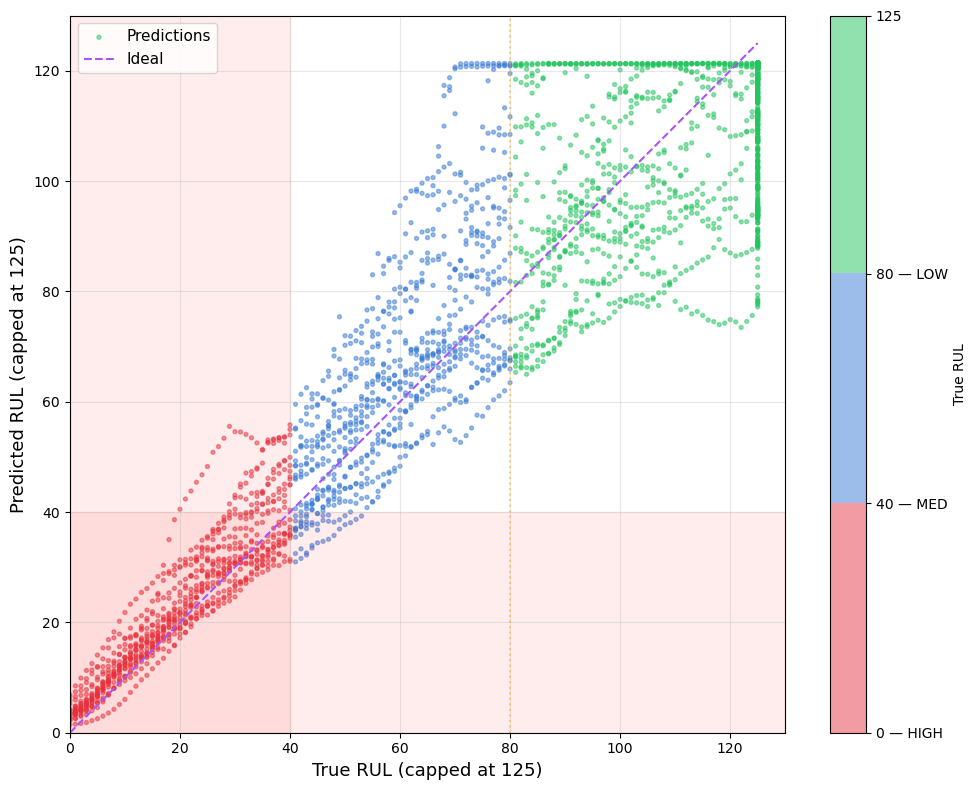

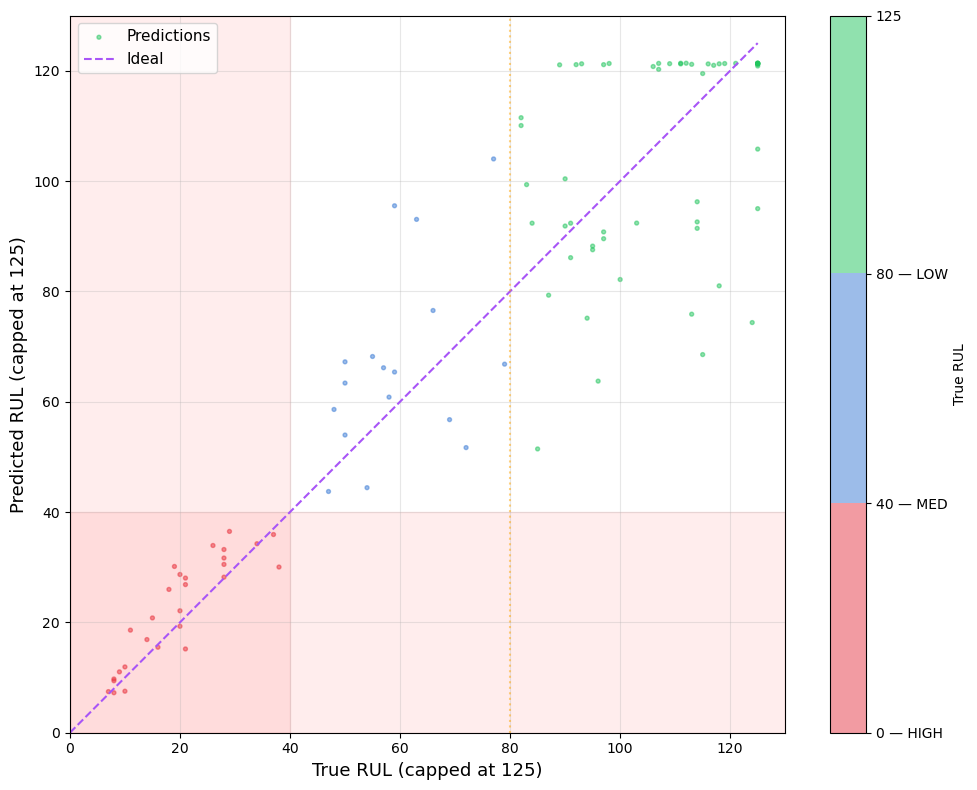

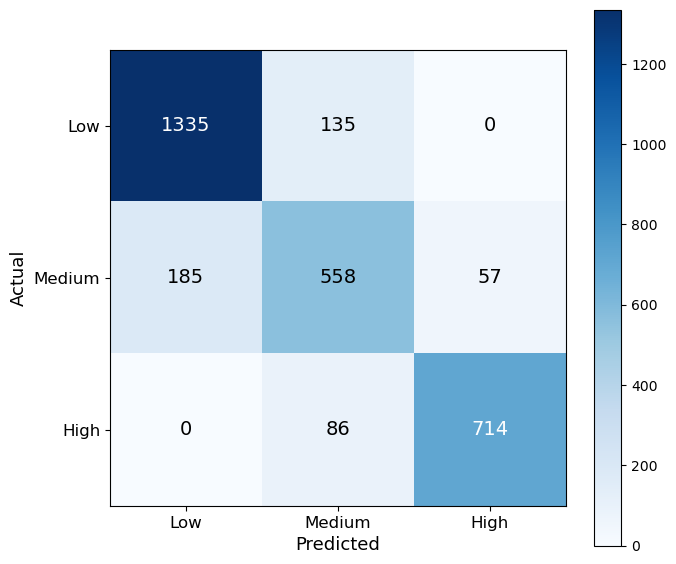

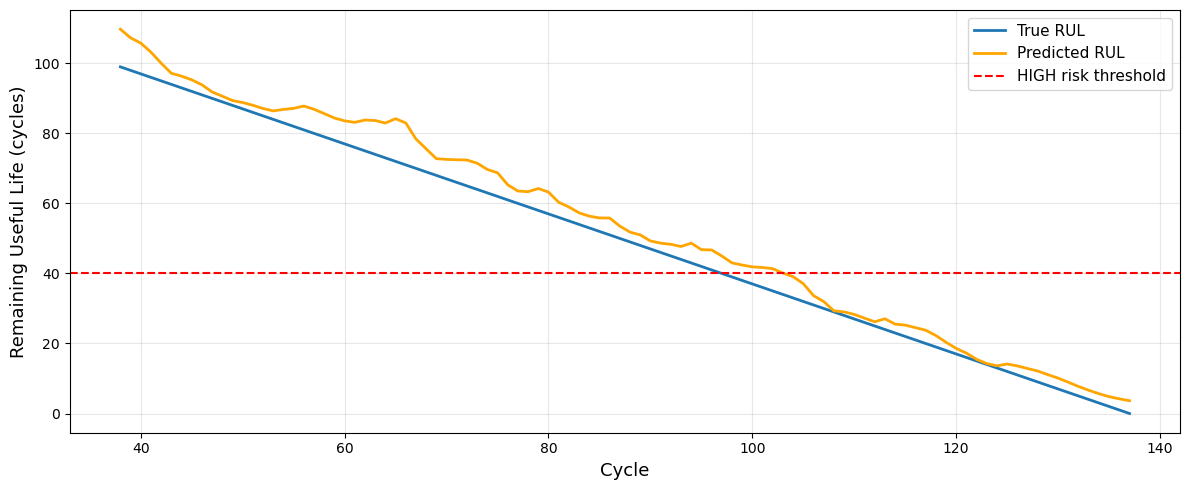

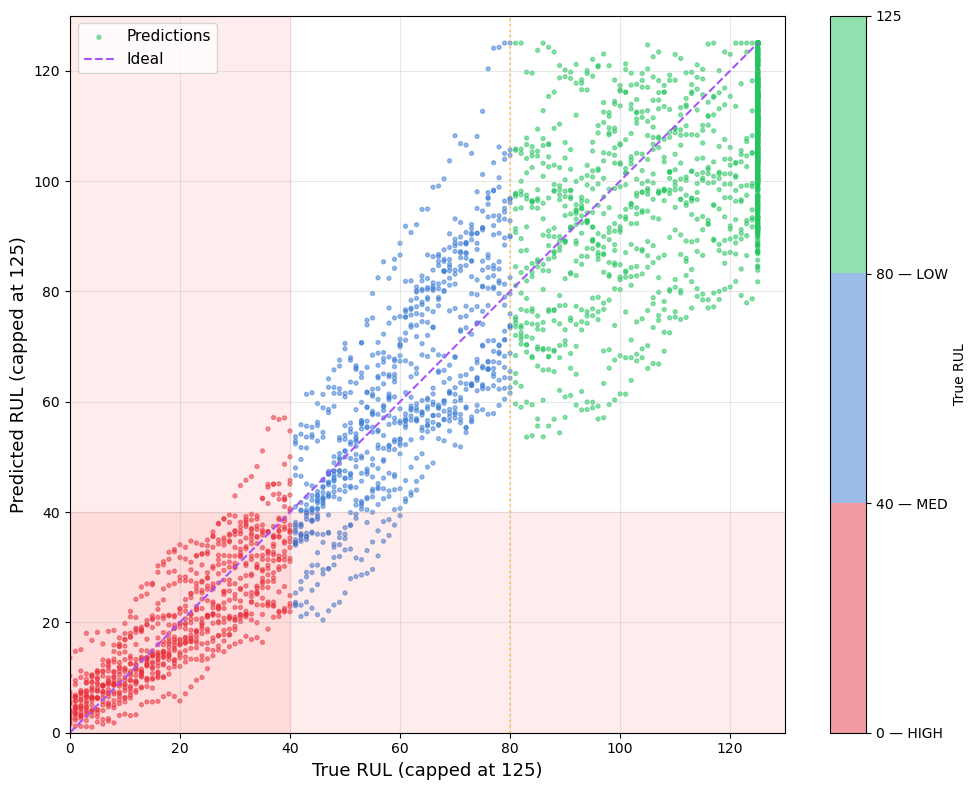

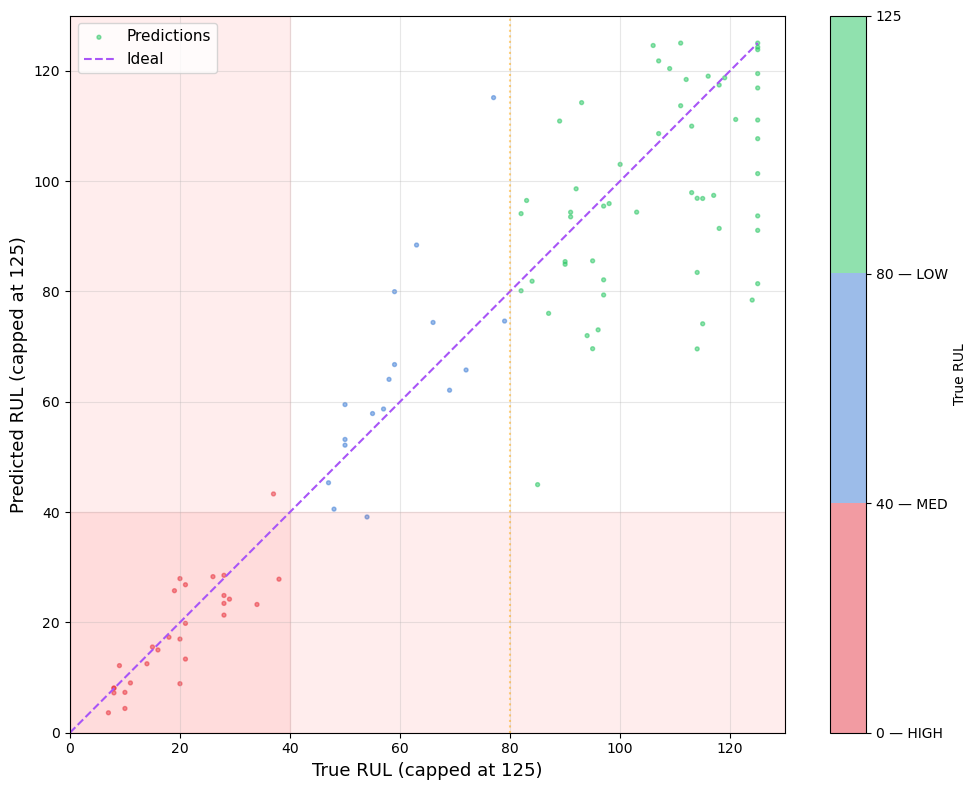

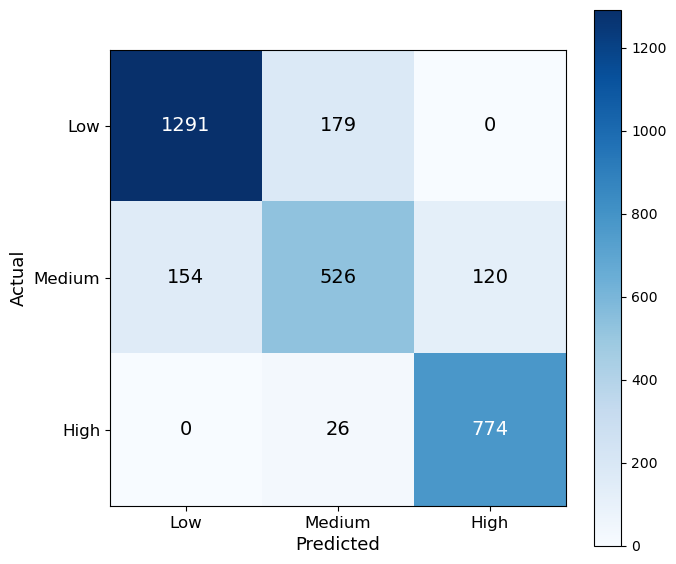

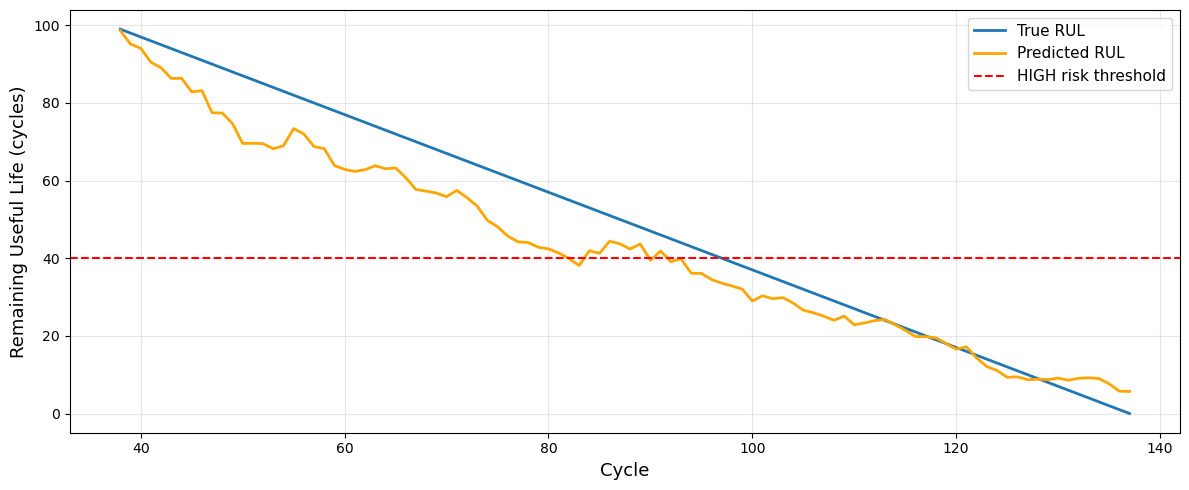

In [106]:
import sys
sys.path.append("/Users/mostafa/xai_predictive_maintenance/src/dashboard")
from backend import (
    get_val_scatter_data, get_test_scatter_data,
    get_model_performance, get_test_performance,
    get_engine_rul_plot,
    get_cnn_val_scatter_data, get_cnn_test_scatter_data,
    get_model_performance_cnn, get_test_performance_cnn,
    get_cnn_engine_rul_plot
)
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# ── Color boundaries ──────────────────────────────────────────────────────────
RISK_CMAP = mcolors.LinearSegmentedColormap.from_list(
    "risk", [(0,"#e63946"),(0.32,"#e63946"),(0.32,"#3a7bd5"),
             (0.64,"#3a7bd5"),(0.64,"#22c55e"),(1,"#22c55e")])

# ═══════════════════════════════════════════════════════════════════════════════
# 1. LSTM Validation Scatter
# ═══════════════════════════════════════════════════════════════════════════════
data = get_val_scatter_data()
true_v = np.clip(data["true"], 0, 125)
pred_v = np.clip(data["pred"], 0, 125)

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(true_v, pred_v, c=true_v, cmap=RISK_CMAP, vmin=0, vmax=125,
                s=8, alpha=0.5, label="Predictions")
ax.plot([0,125],[0,125], color="#a855f7", linestyle="--", linewidth=1.5, label="Ideal")
ax.axvspan(0, 40, color="red", alpha=0.07)
ax.axhspan(0, 40, color="red", alpha=0.07)
ax.axvline(80, color="orange", linestyle=":", alpha=0.5)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("True RUL")
cbar.set_ticks([0, 40, 80, 125])
cbar.set_ticklabels(["0 — HIGH", "40 — MED", "80 — LOW", "125"])
ax.set_xlabel("True RUL (capped at 125)", fontsize=13)
ax.set_ylabel("Predicted RUL (capped at 125)", fontsize=13)
ax.set_xlim(0, 130); ax.set_ylim(0, 130)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("lstm_val_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 2. LSTM Test Scatter
# ═══════════════════════════════════════════════════════════════════════════════
data_t = get_test_scatter_data()
true_t = np.clip(data_t["true"], 0, 125)
pred_t = np.clip(data_t["pred"], 0, 125)

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(true_t, pred_t, c=true_t, cmap=RISK_CMAP, vmin=0, vmax=125,
                s=8, alpha=0.5, label="Predictions")
ax.plot([0,125],[0,125], color="#a855f7", linestyle="--", linewidth=1.5, label="Ideal")
ax.axvspan(0, 40, color="red", alpha=0.07)
ax.axhspan(0, 40, color="red", alpha=0.07)
ax.axvline(80, color="orange", linestyle=":", alpha=0.5)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("True RUL")
cbar.set_ticks([0, 40, 80, 125])
cbar.set_ticklabels(["0 — HIGH", "40 — MED", "80 — LOW", "125"])
ax.set_xlabel("True RUL (capped at 125)", fontsize=13)
ax.set_ylabel("Predicted RUL (capped at 125)", fontsize=13)
ax.set_xlim(0, 130); ax.set_ylim(0, 130)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("lstm_test_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 3. LSTM Validation Confusion Matrix
# ═══════════════════════════════════════════════════════════════════════════════
perf = get_model_performance()
cm = perf["confusion_matrix"]
labels = ["Low", "Medium", "High"]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks([0,1,2]); ax.set_yticks([0,1,2])
ax.set_xticklabels(labels, fontsize=12)
ax.set_yticklabels(labels, fontsize=12)
ax.set_xlabel("Predicted", fontsize=13)
ax.set_ylabel("Actual", fontsize=13)
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i,j]), ha="center", va="center",
                fontsize=14, color="white" if cm[i,j] > cm.max()/2 else "black")
plt.tight_layout()
plt.savefig("lstm_val_cm.png", dpi=300, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 4. LSTM Trajectory — change engine_id to your preferred engine
# ═══════════════════════════════════════════════════════════════════════════════
engine_id = 40
curve = get_engine_rul_plot(engine_id)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(curve["cycles"], curve["true"], label="True RUL", color="#1f77b4", linewidth=2)
ax.plot(curve["cycles"], curve["pred"], label="Predicted RUL", color="orange", linewidth=2)
ax.axhline(y=40, color="red", linestyle="--", linewidth=1.5, label="HIGH risk threshold")
ax.set_xlabel("Cycle", fontsize=13)
ax.set_ylabel("Remaining Useful Life (cycles)", fontsize=13)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("lstm_trajectory.png", dpi=300, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 5. CNN Validation Scatter
# ═══════════════════════════════════════════════════════════════════════════════
data_c = get_cnn_val_scatter_data()
true_cv = np.clip(data_c["true"], 0, 125)
pred_cv = np.clip(data_c["pred"], 0, 125)

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(true_cv, pred_cv, c=true_cv, cmap=RISK_CMAP, vmin=0, vmax=125,
                s=8, alpha=0.5, label="Predictions")
ax.plot([0,125],[0,125], color="#a855f7", linestyle="--", linewidth=1.5, label="Ideal")
ax.axvspan(0, 40, color="red", alpha=0.07)
ax.axhspan(0, 40, color="red", alpha=0.07)
ax.axvline(80, color="orange", linestyle=":", alpha=0.5)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("True RUL")
cbar.set_ticks([0, 40, 80, 125])
cbar.set_ticklabels(["0 — HIGH", "40 — MED", "80 — LOW", "125"])
ax.set_xlabel("True RUL (capped at 125)", fontsize=13)
ax.set_ylabel("Predicted RUL (capped at 125)", fontsize=13)
ax.set_xlim(0, 130); ax.set_ylim(0, 130)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cnn_val_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 6. CNN Test Scatter
# ═══════════════════════════════════════════════════════════════════════════════
data_ct = get_cnn_test_scatter_data()
true_ct = np.clip(data_ct["true"], 0, 125)
pred_ct = np.clip(data_ct["pred"], 0, 125)

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(true_ct, pred_ct, c=true_ct, cmap=RISK_CMAP, vmin=0, vmax=125,
                s=8, alpha=0.5, label="Predictions")
ax.plot([0,125],[0,125], color="#a855f7", linestyle="--", linewidth=1.5, label="Ideal")
ax.axvspan(0, 40, color="red", alpha=0.07)
ax.axhspan(0, 40, color="red", alpha=0.07)
ax.axvline(80, color="orange", linestyle=":", alpha=0.5)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("True RUL")
cbar.set_ticks([0, 40, 80, 125])
cbar.set_ticklabels(["0 — HIGH", "40 — MED", "80 — LOW", "125"])
ax.set_xlabel("True RUL (capped at 125)", fontsize=13)
ax.set_ylabel("Predicted RUL (capped at 125)", fontsize=13)
ax.set_xlim(0, 130); ax.set_ylim(0, 130)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cnn_test_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 7. CNN Validation Confusion Matrix
# ═══════════════════════════════════════════════════════════════════════════════
perf_cnn = get_model_performance_cnn()
cm_cnn = perf_cnn["confusion_matrix"]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_cnn, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks([0,1,2]); ax.set_yticks([0,1,2])
ax.set_xticklabels(labels, fontsize=12)
ax.set_yticklabels(labels, fontsize=12)
ax.set_xlabel("Predicted", fontsize=13)
ax.set_ylabel("Actual", fontsize=13)
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm_cnn[i,j]), ha="center", va="center",
                fontsize=14, color="white" if cm_cnn[i,j] > cm_cnn.max()/2 else "black")
plt.tight_layout()
plt.savefig("cnn_val_cm.png", dpi=300, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 8. CNN Trajectory
# ═══════════════════════════════════════════════════════════════════════════════
engine_id_cnn = 40
curve_cnn = get_cnn_engine_rul_plot(engine_id_cnn)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(curve_cnn["cycles"], curve_cnn["true"], label="True RUL", color="#1f77b4", linewidth=2)
ax.plot(curve_cnn["cycles"], curve_cnn["pred"], label="Predicted RUL", color="orange", linewidth=2)
ax.axhline(y=40, color="red", linestyle="--", linewidth=1.5, label="HIGH risk threshold")
ax.set_xlabel("Cycle", fontsize=13)
ax.set_ylabel("Remaining Useful Life (cycles)", fontsize=13)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cnn_trajectory.png", dpi=300, bbox_inches="tight")
plt.show()

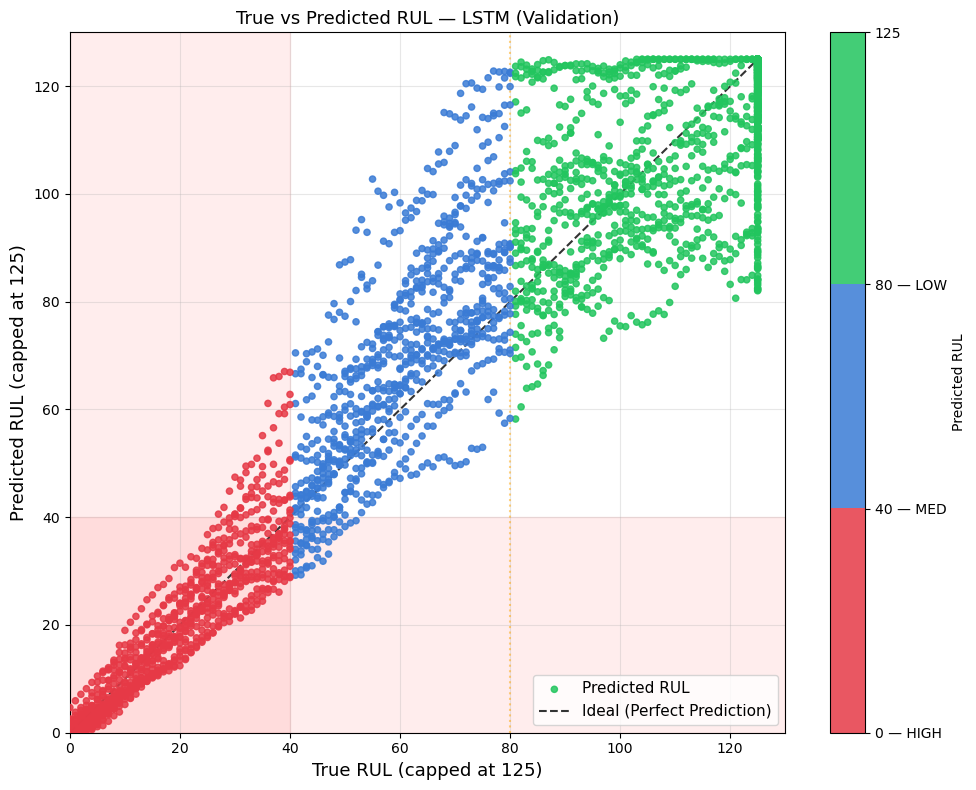

Saved: /Users/mostafa/xai_predictive_maintenance/Thesis_Report/figures/lstm_val_scatter.png


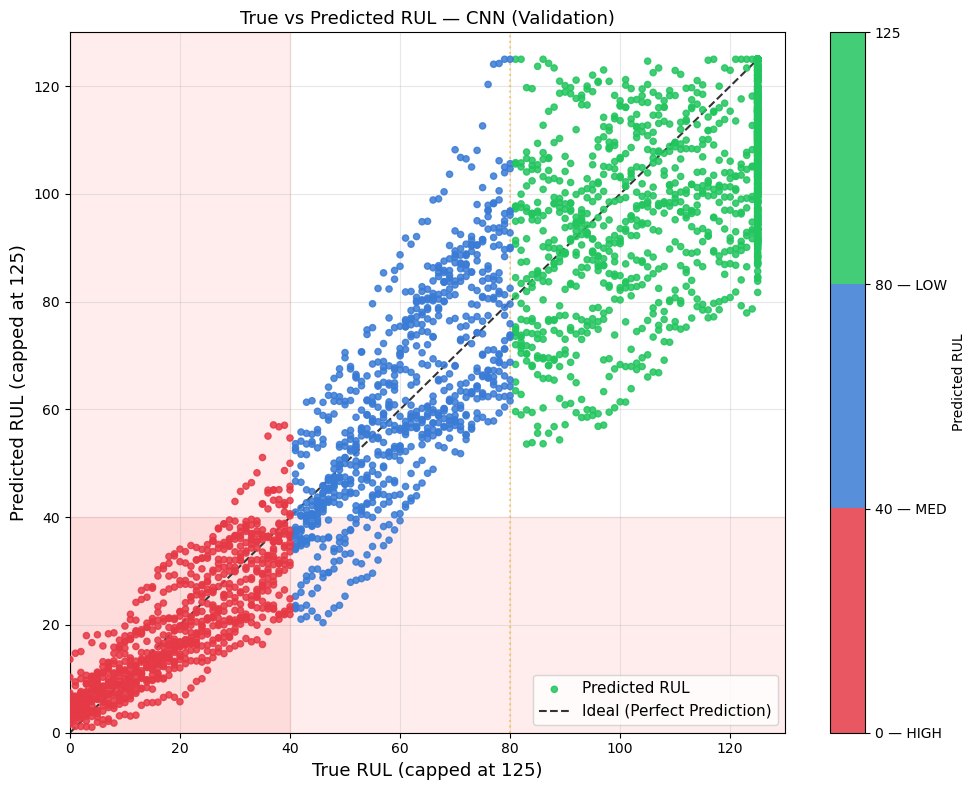

Saved: /Users/mostafa/xai_predictive_maintenance/Thesis_Report/figures/cnn_val_scatter.png


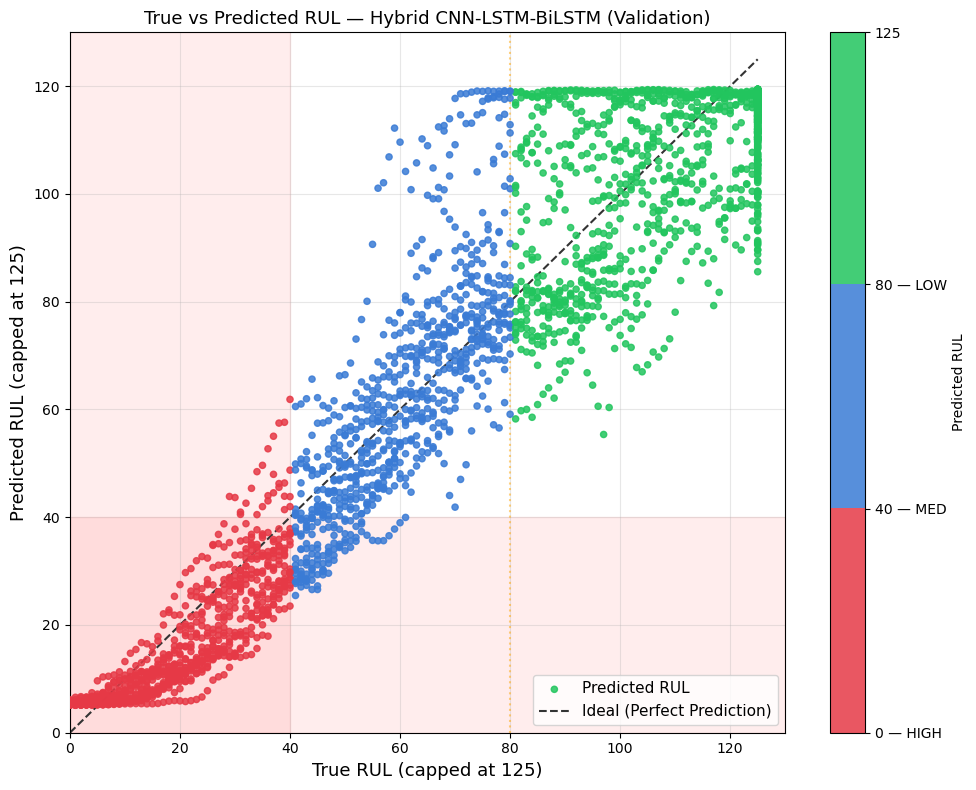

Saved: /Users/mostafa/xai_predictive_maintenance/Thesis_Report/figures/hybrid_val_scatter.png


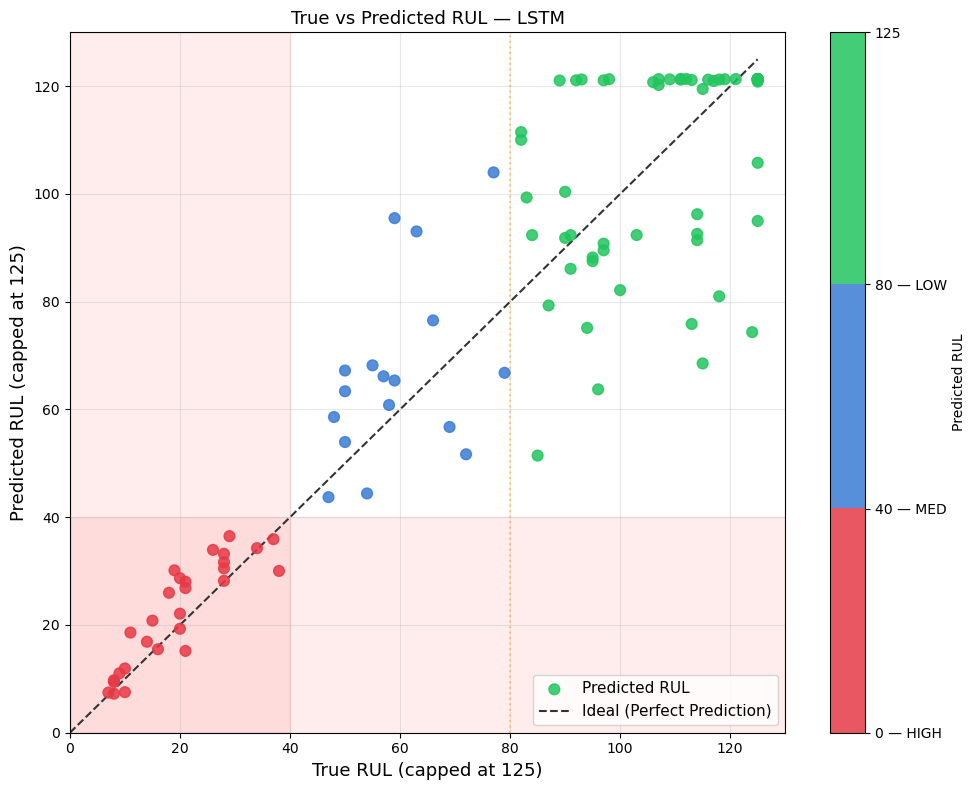

Saved: /Users/mostafa/xai_predictive_maintenance/Thesis_Report/figures/lstm_test_scatter.png


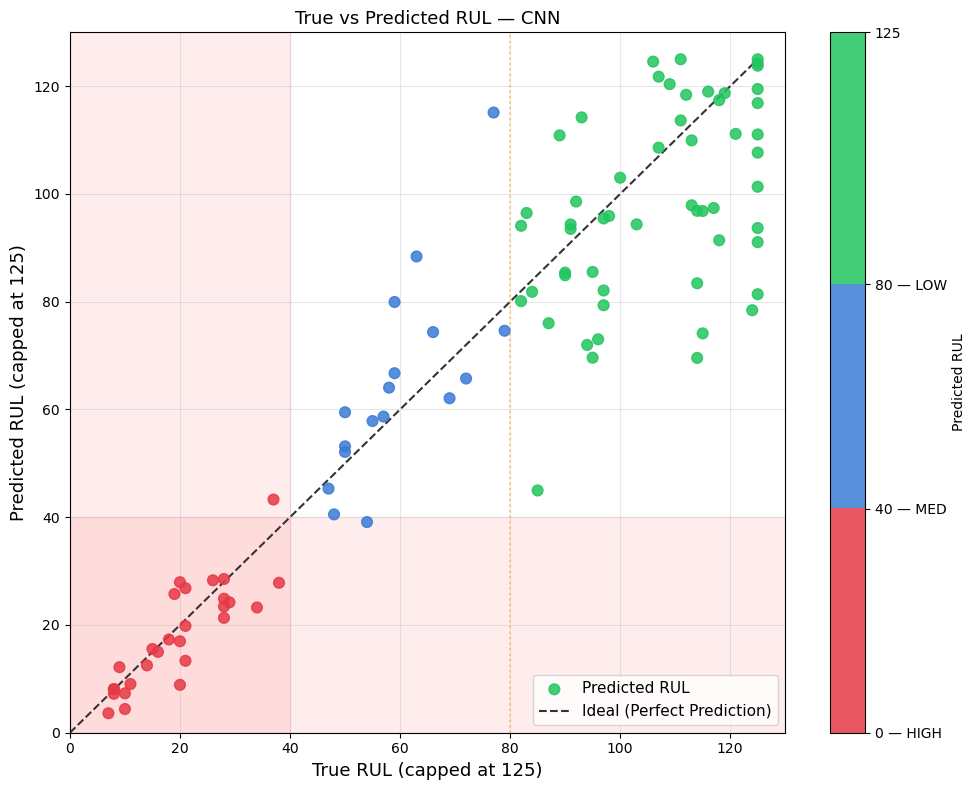

Saved: /Users/mostafa/xai_predictive_maintenance/Thesis_Report/figures/cnn_test_scatter.png


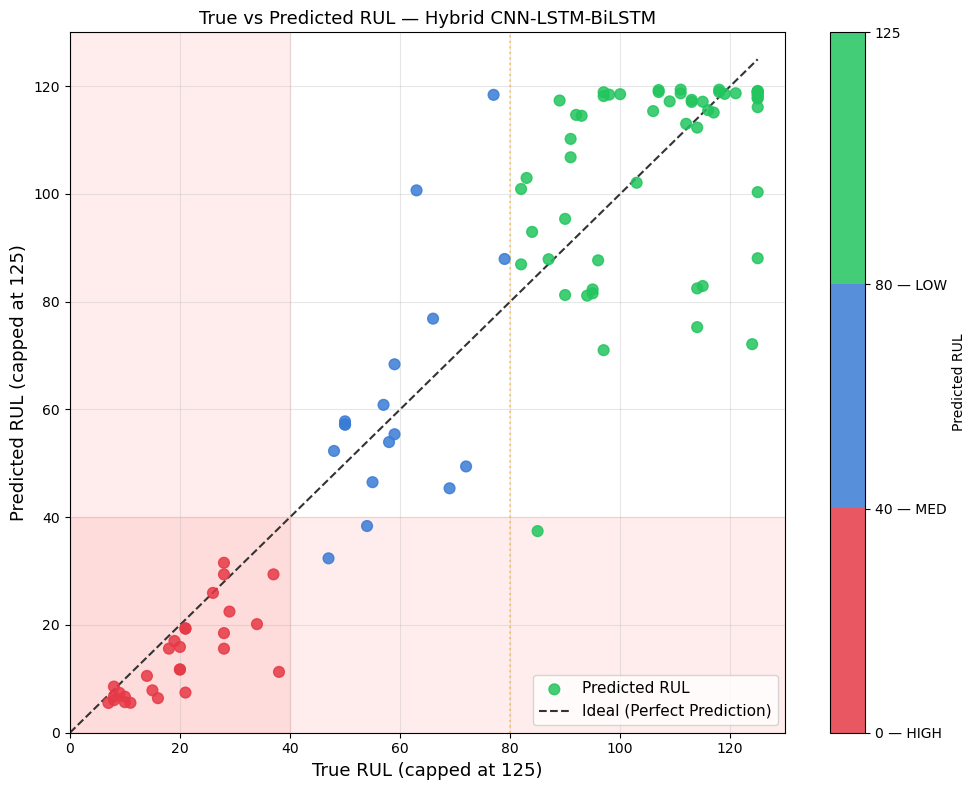

Saved: /Users/mostafa/xai_predictive_maintenance/Thesis_Report/figures/hybrid_test_scatter.png


In [114]:
def plot_scatter_new(true_rul, pred_rul, model_name, save_path, dot_size=55):
    true_c = np.clip(true_rul, 0, 125)
    pred_c = np.clip(pred_rul, 0, 125)
    fig, ax = plt.subplots(figsize=(10, 8))
    sc = ax.scatter(true_c, pred_c, c=true_c, cmap=RISK_CMAP, vmin=0, vmax=125,
                    s=dot_size, alpha=0.85, zorder=3, label="Predicted RUL")
    ax.plot([0,125],[0,125], color="#333333", linestyle="--", linewidth=1.5, label="Ideal (Perfect Prediction)")
    ax.axvspan(0, 40, color="red", alpha=0.07)
    ax.axhspan(0, 40, color="red", alpha=0.07)
    ax.axvline(80, color="orange", linestyle=":", alpha=0.5)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Predicted RUL")
    cbar.set_ticks([0, 40, 80, 125])
    cbar.set_ticklabels(["0 — HIGH", "40 — MED", "80 — LOW", "125"])
    ax.set_xlabel("True RUL (capped at 125)", fontsize=13)
    ax.set_ylabel("Predicted RUL (capped at 125)", fontsize=13)
    ax.set_title(f"True vs Predicted RUL — {model_name}", fontsize=13)
    ax.set_xlim(0, 130); ax.set_ylim(0, 130)
    ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")

# Validation
plot_scatter_new(y_val_np,     all_rul_preds,    "LSTM (Validation)",                   os.path.join(FIGURES, "lstm_val_scatter.png"),   dot_size=20)
plot_scatter_new(cnn_val_true, cnn_val_preds,    "CNN (Validation)",                    os.path.join(FIGURES, "cnn_val_scatter.png"),    dot_size=20)
plot_scatter_new(y_val_np,     hybrid_val_preds, "Hybrid CNN-LSTM-BiLSTM (Validation)", os.path.join(FIGURES, "hybrid_val_scatter.png"), dot_size=20)
# Test
plot_scatter_new(true_test_rul, lstm_test_preds,   "LSTM",                   os.path.join(FIGURES, "lstm_test_scatter.png"),   dot_size=60)
plot_scatter_new(true_test_rul, cnn_test_preds,    "CNN",                    os.path.join(FIGURES, "cnn_test_scatter.png"),    dot_size=60)
plot_scatter_new(true_test_rul, hybrid_test_preds, "Hybrid CNN-LSTM-BiLSTM", os.path.join(FIGURES, "hybrid_test_scatter.png"), dot_size=60)

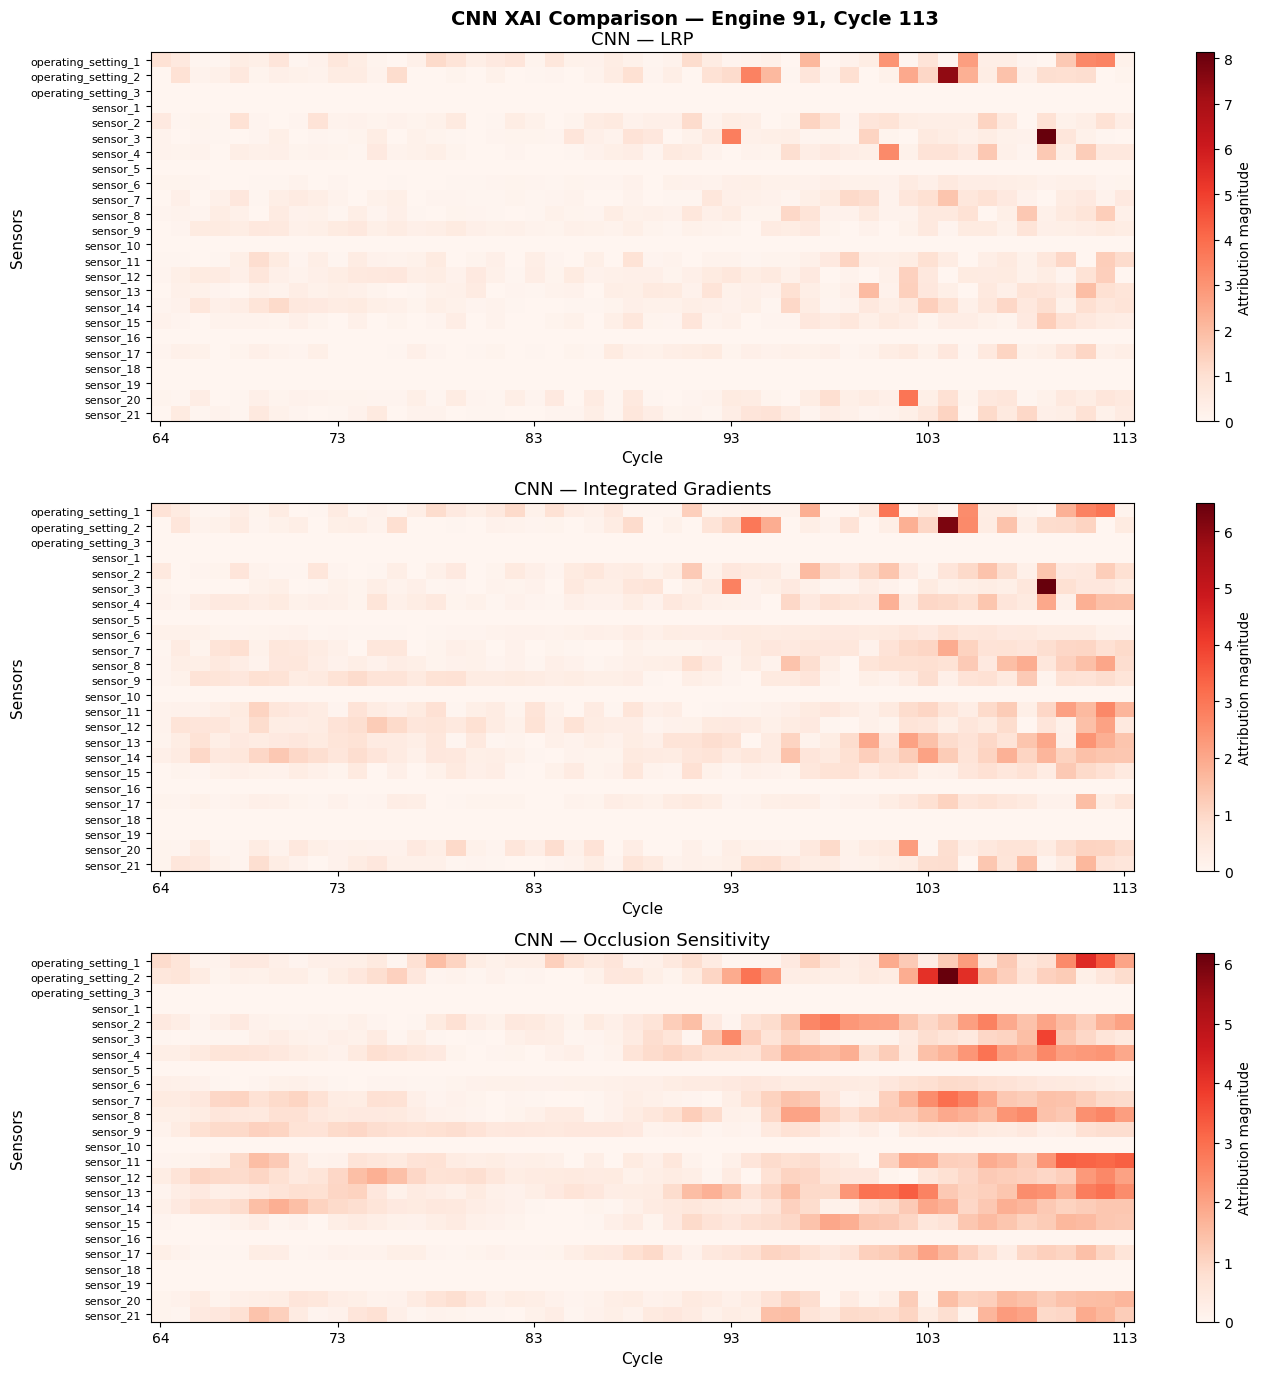

Saved.


In [119]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from captum.attr import IntegratedGradients, Occlusion as CaptumOcclusion, LRP
from captum.attr._utils.lrp_rules import EpsilonRule
import torch.nn as nn

FIGURES = os.path.abspath(os.path.join(os.getcwd(), '..', 'Thesis_Report', 'figures'))

# ── Engine 91, Cycle 113 ──────────────────────────────────────────────────────
machine_id   = 91
cycle_number = 113

machine_df = df[df["machine_id"] == machine_id].sort_values("cycle")
machine_df = machine_df[machine_df["cycle"] <= cycle_number]
window      = machine_df.iloc[-WINDOW_SIZE:]
cycle_nums  = window["cycle"].values
cnn_sample  = torch.tensor(window[feature_cols].values, dtype=torch.float32).unsqueeze(0)

cnn_model.eval()

# ── IG ────────────────────────────────────────────────────────────────────────
ig_cnn     = IntegratedGradients(cnn_model)
ig_attr    = ig_cnn.attribute(cnn_sample, baselines=torch.zeros_like(cnn_sample), n_steps=50)
cnn_ig_map = np.abs(ig_attr.squeeze().detach().numpy())

# ── LRP ───────────────────────────────────────────────────────────────────────
for module in cnn_model.modules():
    if isinstance(module, (nn.Conv1d, nn.Linear, nn.ReLU, nn.Dropout)):
        module.rule = EpsilonRule()
lrp         = LRP(cnn_model)
lrp_attr    = lrp.attribute(cnn_sample)
cnn_lrp_map = np.abs(lrp_attr.squeeze().detach().numpy())

# ── Occlusion ─────────────────────────────────────────────────────────────────
_occ_cnn    = CaptumOcclusion(cnn_model)
occ_attr    = _occ_cnn.attribute(cnn_sample, baselines=0,
                                  sliding_window_shapes=(2, 1), strides=(1, 1))
cnn_occ_map = np.abs(occ_attr.squeeze().detach().numpy())

# ── Plot — vertical stack ─────────────────────────────────────────────────────
titles = ["CNN — LRP", "CNN — Integrated Gradients", "CNN — Occlusion Sensitivity"]
maps   = [cnn_lrp_map, cnn_ig_map, cnn_occ_map]

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

for ax, title, data in zip(axes, titles, maps):
    im = ax.imshow(data.T, aspect="auto", cmap="Reds")
    ax.set_title(title, fontsize=13)
    ax.set_ylabel("Sensors", fontsize=11)
    ax.set_xlabel("Cycle", fontsize=11)
    ax.set_yticks(range(len(feature_cols)))
    ax.set_yticklabels(feature_cols, fontsize=8)
    tick_positions = np.linspace(0, len(cycle_nums)-1, 6, dtype=int)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(cycle_nums[tick_positions], rotation=0)
    plt.colorbar(im, ax=ax, label="Attribution magnitude")

plt.suptitle(f"CNN XAI Comparison — Engine {machine_id}, Cycle {cycle_number}",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, "igoccheatmaps.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved.")